# Fase 1 — Inteligencia Analítica del Mercado Público

## IMAGEN CODIGO

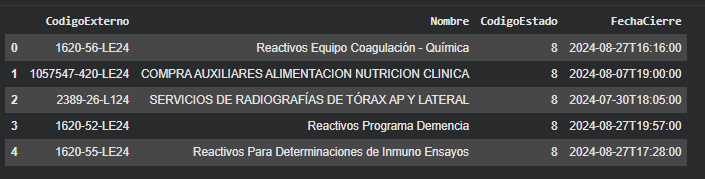

## ticket_ MIO = F8537A18-6766-4DEF-9E59-426B4FEE2844
## ticket_ PRUEBA = 166E1F2D-5FD5-4063-BA75-CFA20CE6798B

## Montar GDRIVE y verificar carpetas

In [244]:
# =========================================================
# MONTAR GOOGLE DRIVE
# =========================================================

from google.colab import drive
import os

# Unmount if already mounted to clear any remnants
if os.path.exists('/content/drive'):
    try:
        drive.flush_and_unmount()
    except:
        pass
    # Remove the directory if it exists and is not empty
    if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
        !rm -rf /content/drive/*
        !rmdir /content/drive
    elif os.path.isdir('/content/drive'):
        !rmdir /content/drive

# Create an empty mount point if it doesn't exist
if not os.path.exists('/content/drive'):
    os.makedirs('/content/drive')

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [245]:
import os

os.listdir("/content/drive/MyDrive/mercado_publico")

['raw',
 'processed',
 'analytics',
 'catalogos_proveedores',
 'catalogos',
 'clean',
 'outputs']

## DataFrame — Estados de licitación y etapas.

In [246]:
# =========================================================
# CATALOGO OFICIAL ESTADOS DE LICITACION (CHILECOMPRA API)
# =========================================================

import pandas as pd

data_estados = {
    "CodigoEstado": [
        5, 6, 7, 8, 18, 19
    ],

    "Estado": [
        "Publicada",
        "Cerrada",
        "Desierta",
        "Adjudicada",
        "Revocada",
        "Suspendida"
    ],

    "Descripcion": [
        "Licitación publicada y abierta a recepción de ofertas",
        "Licitación cerrada (fin de recepción de ofertas)",
        "Licitación sin ofertas válidas",
        "Licitación adjudicada a un proveedor",
        "Licitación revocada por el organismo comprador",
        "Licitación suspendida temporalmente"
    ],

    # 👇 MUY IMPORTANTE PARA ANALITICA
    "GrupoEstado": [
        "Activa",
        "Cerrada",
        "Cerrada",
        "Cerrada",
        "Cerrada",
        "Activa"
    ]
}

df_estados_licitacion = pd.DataFrame(data_estados)

display(df_estados_licitacion)

,CodigoEstado,Estado,Descripcion,GrupoEstado
0,5,Publicada,Licitación publicada y abierta a recepción de ...,Activa
1,6,Cerrada,Licitación cerrada (fin de recepción de ofertas),Cerrada
2,7,Desierta,Licitación sin ofertas válidas,Cerrada
3,8,Adjudicada,Licitación adjudicada a un proveedor,Cerrada
4,18,Revocada,Licitación revocada por el organismo comprador,Cerrada
5,19,Suspendida,Licitación suspendida temporalmente,Activa


In [247]:
# =========================================================
# CATALOGO OFICIAL TIPOS DE LICITACION (CHILECOMPRA)
# =========================================================

import pandas as pd

data_tipos = {
    "codigo_tipo": [
        "L1", "LE", "LP", "LQ", "LR",
        "E2", "CO", "B2", "H2", "I2",
        "LS"
    ],

    "tipo_licitacion": [
        "Licitación Pública Menor a 100 UTM",
        "Licitación Pública entre 100 y 1.000 UTM",
        "Licitación Pública entre 1.000 y 2.000 UTM",
        "Licitación Pública entre 2.000 y 5.000 UTM",
        "Licitación Pública Mayor a 5.000 UTM",
        "Licitación Privada Menor a 100 UTM",
        "Licitación Privada entre 100 y 1.000 UTM",
        "Licitación Privada entre 1.000 y 2.000 UTM",
        "Licitación Privada entre 2.000 y 5.000 UTM",
        "Licitación Privada Mayor a 5.000 UTM",
        "Licitación Servicios Personales Especializados"
    ],

    # 👇 CLAVE PARA TU PROYECTO
    "tipo_base": [
        "Publica","Publica","Publica","Publica","Publica",
        "Privada","Privada","Privada","Privada","Privada",
        "Especial"
    ],

    # 👇 SEGMENTACIÓN POR MONTO (MUY UTIL PARA ML)
    "rango_monto": [
        "<100 UTM",
        "100-1000 UTM",
        "1000-2000 UTM",
        "2000-5000 UTM",
        ">5000 UTM",
        "<100 UTM",
        "100-1000 UTM",
        "1000-2000 UTM",
        "2000-5000 UTM",
        ">5000 UTM",
        "N/A"
    ]
}

df_tipos_licitacion = pd.DataFrame(data_tipos)

display(df_tipos_licitacion)

,codigo_tipo,tipo_licitacion,tipo_base,rango_monto
0,L1,Licitación Pública Menor a 100 UTM,Publica,<100 UTM
1,LE,Licitación Pública entre 100 y 1.000 UTM,Publica,100-1000 UTM
2,LP,Licitación Pública entre 1.000 y 2.000 UTM,Publica,1000-2000 UTM
3,LQ,Licitación Pública entre 2.000 y 5.000 UTM,Publica,2000-5000 UTM
4,LR,Licitación Pública Mayor a 5.000 UTM,Publica,>5000 UTM
5,E2,Licitación Privada Menor a 100 UTM,Privada,<100 UTM
6,CO,Licitación Privada entre 100 y 1.000 UTM,Privada,100-1000 UTM
7,B2,Licitación Privada entre 1.000 y 2.000 UTM,Privada,1000-2000 UTM
8,H2,Licitación Privada entre 2.000 y 5.000 UTM,Privada,2000-5000 UTM
9,I2,Licitación Privada Mayor a 5.000 UTM,Privada,>5000 UTM


In [248]:
import os

# Ensure the directory exists before saving files
os.makedirs('/content/drive/MyDrive/mercado_publico/catalogos', exist_ok=True)

df_estados_licitacion.to_parquet(
"/content/drive/MyDrive/mercado_publico/catalogos/estados_licitacion.parquet",
index=False
)

df_tipos_licitacion.to_parquet(
"/content/drive/MyDrive/mercado_publico/catalogos/tipos_licitacion.parquet",
index=False
)

df_estados_licitacion.to_csv(
"/content/drive/MyDrive/mercado_publico/catalogos/estados_licitacion.CSV",
index=False
)

df_tipos_licitacion.to_csv(
"/content/drive/MyDrive/mercado_publico/catalogos/tipos_licitacion.CSV",
index=False
)

## 📦 Código — Paso 1: Carga dataset

In [249]:
# =========================================================
# 1. CARGA DATASET LICITACIONES
# =========================================================

# ---------------------------------------------------------
# LIBRERÍAS
# ---------------------------------------------------------
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [250]:
# ---------------------------------------------------------
# 1. CARGAR DATASETS
# ---------------------------------------------------------

PATH_LIC = "/content/drive/MyDrive/mercado_publico/analytics/licitaciones_dataset_completo.parquet"
PATH_OC  = "/content/drive/MyDrive/mercado_publico/analytics/ordenes_compra_dataset_completo.parquet"

df_lic = pd.read_parquet(PATH_LIC)
df_oc  = pd.read_parquet(PATH_OC)

print("Licitaciones total:", df_lic.shape)
print("OC total:", df_oc.shape)

Licitaciones total: (826238, 4)
OC total: (13489635, 3)


In [251]:
df_licitaciones = df_lic.copy()
df_ordenescompra = df_oc.copy()

In [252]:
# ---------------------------------------------------------
# CARGA DEL ARCHIVO PARQUET
# ---------------------------------------------------------

#FILE_NAME = "licitaciones_dataset_completo.parquet"

#print("Cargando dataset...")

#df_licitaciones = pd.read_parquet(FILE_NAME)

#print("Dataset cargado correctamente")

In [253]:
# ---------------------------------------------------------
# DIMENSIONES DEL DATASET
# ---------------------------------------------------------
print("\n==============================")
print("DIMENSIONES DEL DATASET")
print("==============================")

print("Filas :", df_licitaciones.shape[0])
print("Columnas :", df_licitaciones.shape[1])


DIMENSIONES DEL DATASET
Filas : 826238
Columnas : 4


In [254]:
# ---------------------------------------------------------
# COLUMNAS DEL DATASET
# ---------------------------------------------------------
print("\n==============================")
print("COLUMNAS")
print("==============================")

print(df_licitaciones.columns.tolist())


COLUMNAS
['CodigoExterno', 'Nombre', 'CodigoEstado', 'FechaCierre']


In [255]:
# ---------------------------------------------------------
# PRIMEROS REGISTROS
# ---------------------------------------------------------
print("\n==============================")
print("PRIMERAS FILAS")
print("==============================")

display(df_licitaciones.head())


PRIMERAS FILAS


,CodigoExterno,Nombre,CodigoEstado,FechaCierre
0,564162-187-L119,(id.48430) Particulas para Depto de Física,7,2020-01-01T17:04:01.527
1,1058134-381-L119,Medicamentos Enero 2020,7,2020-01-01T15:04:01.643
2,1663-111-L119,SERVICIO DE LABORATORIO DENTAL PARA PRÓTESIS M...,7,2020-01-01T21:44:01.157
3,2713-290-L119,CLASES DIRIGIDAS,7,2020-01-01T19:29:01.22
4,1058133-15-LR19,Convenio de Suministro Farmacos Inyectables Red,8,2019-11-04T15:01:00


In [256]:
# ---------------------------------------------------------
# TIPOS DE DATOS
# ---------------------------------------------------------
print("\n==============================")
print("TIPOS DE DATOS")
print("==============================")

display(df_licitaciones.dtypes)


TIPOS DE DATOS


,0
CodigoExterno,object
Nombre,object
CodigoEstado,int64
FechaCierre,object


In [257]:
# ---------------------------------------------------------
# RESUMEN GENERAL
# ---------------------------------------------------------
print("\n==============================")
print("RESUMEN DEL DATASET")
print("==============================")

df_licitaciones.info()


RESUMEN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 826238 entries, 0 to 826237
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   CodigoExterno  826238 non-null  object
 1   Nombre         826238 non-null  object
 2   CodigoEstado   826238 non-null  int64 
 3   FechaCierre    826237 non-null  object
dtypes: int64(1), object(3)
memory usage: 25.2+ MB


In [258]:
# ---------------------------------------------------------
# NULOS POR COLUMNA
# ---------------------------------------------------------
print("\n==============================")
print("VALORES NULOS")
print("==============================")

nulls = df_licitaciones.isnull().sum().sort_values(ascending=False)

display(nulls.head(20))



VALORES NULOS


,0
FechaCierre,1
CodigoExterno,0
Nombre,0
CodigoEstado,0


In [259]:
# ---------------------------------------------------------
# DUPLICADOS
# ---------------------------------------------------------
print("\n==============================")
print("REGISTROS DUPLICADOS")
print("==============================")

duplicados = df_licitaciones.duplicated().sum()

print("Total duplicados:", duplicados)


REGISTROS DUPLICADOS
Total duplicados: 0


In [260]:
# ---------------------------------------------------------
# USO DE MEMORIA
# ---------------------------------------------------------
print("\n==============================")
print("USO DE MEMORIA")
print("==============================")

memoria = df_licitaciones.memory_usage(deep=True).sum() / 1024**2

print(f"Memoria utilizada: {memoria:.2f} MB")


USO DE MEMORIA
Memoria utilizada: 228.47 MB


In [261]:
df_licitaciones.head()

,CodigoExterno,Nombre,CodigoEstado,FechaCierre
0,564162-187-L119,(id.48430) Particulas para Depto de Física,7,2020-01-01T17:04:01.527
1,1058134-381-L119,Medicamentos Enero 2020,7,2020-01-01T15:04:01.643
2,1663-111-L119,SERVICIO DE LABORATORIO DENTAL PARA PRÓTESIS M...,7,2020-01-01T21:44:01.157
3,2713-290-L119,CLASES DIRIGIDAS,7,2020-01-01T19:29:01.22
4,1058133-15-LR19,Convenio de Suministro Farmacos Inyectables Red,8,2019-11-04T15:01:00


In [262]:
df_licitaciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 826238 entries, 0 to 826237
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   CodigoExterno  826238 non-null  object
 1   Nombre         826238 non-null  object
 2   CodigoEstado   826238 non-null  int64 
 3   FechaCierre    826237 non-null  object
dtypes: int64(1), object(3)
memory usage: 25.2+ MB


## 📦 Código — Paso 2: Embudo Licitaciones.

In [263]:
# =========================================================
# FILTRAR LICITACIONES ADJUDICADAS
# =========================================================

df_licitaciones_adjudicadas = df_licitaciones[
    df_licitaciones["CodigoEstado"] == 8
].copy()

print("Total licitaciones adjudicadas:", len(df_licitaciones_adjudicadas))

display(df_licitaciones_adjudicadas.head())

Total licitaciones adjudicadas: 604561


,CodigoExterno,Nombre,CodigoEstado,FechaCierre
4,1058133-15-LR19,Convenio de Suministro Farmacos Inyectables Red,8,2019-11-04T15:01:00
5,1058133-19-LR19,Conv.Sum Farmacos trastornos Cardiovasculares RED,8,2019-11-11T15:01:00
8,1523-97-LP19,Propuesta Pública Nº 101/19 “SUMINISTRO DE INS...,8,2019-12-02T15:30:00
9,2097-88-LE19,MEDICAMENTO SOLICITUD DE COMPRA SIABI N 4270 -...,8,2019-12-12T16:00:00
13,2436-575-LE19,Contrato de Suministro Servicio de arriendo am...,8,2019-12-26T16:00:00


In [264]:
df_licitaciones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 826238 entries, 0 to 826237
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   CodigoExterno  826238 non-null  object
 1   Nombre         826238 non-null  object
 2   CodigoEstado   826238 non-null  int64 
 3   FechaCierre    826237 non-null  object
dtypes: int64(1), object(3)
memory usage: 25.2+ MB


In [265]:
df_licitaciones_adjudicadas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 604561 entries, 4 to 826237
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   CodigoExterno  604561 non-null  object
 1   Nombre         604561 non-null  object
 2   CodigoEstado   604561 non-null  int64 
 3   FechaCierre    604561 non-null  object
dtypes: int64(1), object(3)
memory usage: 23.1+ MB


In [266]:
# =========================================================
# DESCOMPONER CodigoExterno COMPLETO
# =========================================================

df = df_licitaciones_adjudicadas.copy()

# separar partes
df[["codigo_organismo", "correlativo", "tipo_anio"]] = (
    df["CodigoExterno"].str.split("-", expand=True)
)

# tipo
df["codigo_tipo"] = df["tipo_anio"].str.replace(r"\d+", "", regex=True)

# año
df["anio_licitacion"] = df["tipo_anio"].str.extract(r"(\d+)").astype('Int64') # Changed to 'Int64' to handle NaN values

display(df.head())

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion
4,1058133-15-LR19,Convenio de Suministro Farmacos Inyectables Red,8,2019-11-04T15:01:00,1058133,15,LR19,LR,19
5,1058133-19-LR19,Conv.Sum Farmacos trastornos Cardiovasculares RED,8,2019-11-11T15:01:00,1058133,19,LR19,LR,19
8,1523-97-LP19,Propuesta Pública Nº 101/19 “SUMINISTRO DE INS...,8,2019-12-02T15:30:00,1523,97,LP19,LP,19
9,2097-88-LE19,MEDICAMENTO SOLICITUD DE COMPRA SIABI N 4270 -...,8,2019-12-12T16:00:00,2097,88,LE19,LE,19
13,2436-575-LE19,Contrato de Suministro Servicio de arriendo am...,8,2019-12-26T16:00:00,2436,575,LE19,LE,19


In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 604561 entries, 4 to 826237
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   CodigoExterno     604561 non-null  object
 1   Nombre            604561 non-null  object
 2   CodigoEstado      604561 non-null  int64 
 3   FechaCierre       604561 non-null  object
 4   codigo_organismo  604561 non-null  object
 5   correlativo       604560 non-null  object
 6   tipo_anio         604560 non-null  object
 7   codigo_tipo       604560 non-null  object
 8   anio_licitacion   604560 non-null  Int64 
dtypes: Int64(1), int64(1), object(7)
memory usage: 46.7+ MB


In [268]:
df["CodigoEstado"].value_counts()

,count
CodigoEstado,
8,604561


In [269]:
# =========================================================
# EXTRAER CODIGO TIPO CORRECTAMENTE
# =========================================================

df["tipo_raw"] = df["CodigoExterno"].str.split("-").str[-1]

# tomar SOLO los primeros 2 caracteres
df["codigo_tipo"] = df["tipo_raw"].str[:2]

display(df[["CodigoExterno", "tipo_raw", "codigo_tipo"]].head())

,CodigoExterno,tipo_raw,codigo_tipo
4,1058133-15-LR19,LR19,LR
5,1058133-19-LR19,LR19,LR
8,1523-97-LP19,LP19,LP
9,2097-88-LE19,LE19,LE
13,2436-575-LE19,LE19,LE


In [270]:
ranking_tipos = (
    df.groupby("codigo_tipo")
    .size()
    .reset_index(name="cantidad_adjudicadas")
    .sort_values(by="cantidad_adjudicadas", ascending=False)
    .reset_index(drop=True)
)

ranking_tipos["ranking"] = ranking_tipos.index + 1

display(ranking_tipos)

print("Suma total:", ranking_tipos["cantidad_adjudicadas"].sum())

,codigo_tipo,cantidad_adjudicadas,ranking
0,LE,266632,1
1,L1,199890,2
2,LP,44798,3
3,LQ,44144,4
4,LR,24585,5
5,R1,13293,6
6,O1,6181,7
7,CO,2378,8
8,E2,842,9
9,R2,581,10


Suma total: 604561


In [271]:
df_tipos_licitacion.head()

,codigo_tipo,tipo_licitacion,tipo_base,rango_monto
0,L1,Licitación Pública Menor a 100 UTM,Publica,<100 UTM
1,LE,Licitación Pública entre 100 y 1.000 UTM,Publica,100-1000 UTM
2,LP,Licitación Pública entre 1.000 y 2.000 UTM,Publica,1000-2000 UTM
3,LQ,Licitación Pública entre 2.000 y 5.000 UTM,Publica,2000-5000 UTM
4,LR,Licitación Pública Mayor a 5.000 UTM,Publica,>5000 UTM


In [272]:
# =========================================================
# AGREGAR TIPO BASE (PUBLICA / PRIVADA / ESPECIAL)
# =========================================================

# Clean up potentially existing suffixed columns from previous runs
columns_to_drop = [col for col in ['tipo_base_x', 'tipo_base_y', 'tipo_base'] if col in df.columns]
if columns_to_drop:
    df = df.drop(columns=columns_to_drop)

df = df.merge(
    df_tipos_licitacion[["codigo_tipo", "tipo_base"]],
    on="codigo_tipo",
    how="left"
)

In [273]:
display(df.head())

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base
0,1058133-15-LR19,Convenio de Suministro Farmacos Inyectables Red,8,2019-11-04T15:01:00,1058133,15,LR19,LR,19,LR19,Publica
1,1058133-19-LR19,Conv.Sum Farmacos trastornos Cardiovasculares RED,8,2019-11-11T15:01:00,1058133,19,LR19,LR,19,LR19,Publica
2,1523-97-LP19,Propuesta Pública Nº 101/19 “SUMINISTRO DE INS...,8,2019-12-02T15:30:00,1523,97,LP19,LP,19,LP19,Publica
3,2097-88-LE19,MEDICAMENTO SOLICITUD DE COMPRA SIABI N 4270 -...,8,2019-12-12T16:00:00,2097,88,LE19,LE,19,LE19,Publica
4,2436-575-LE19,Contrato de Suministro Servicio de arriendo am...,8,2019-12-26T16:00:00,2436,575,LE19,LE,19,LE19,Publica


In [274]:
print("Total de licitaciones adjudicadas inicialmente:", len(df_licitaciones_adjudicadas))
print("Total de licitaciones después de procesar (df):", len(df))

Total de licitaciones adjudicadas inicialmente: 604561
Total de licitaciones después de procesar (df): 604561


In [275]:
# Contar los valores en la columna 'tipo_base', incluyendo nulos
conteo_tipo_base = df['tipo_base'].value_counts(dropna=False)

print("Conteo de licitaciones por tipo de base (incluyendo nulos):")
display(conteo_tipo_base)

sum_conteo_tipo_base = conteo_tipo_base.sum()

print(f"Suma de todas las licitaciones por tipo de base: {sum_conteo_tipo_base}")
print(f"Total de licitaciones adjudicadas en df: {len(df)}")

if sum_conteo_tipo_base == len(df):
    print("La suma de los conteos por tipo de base coincide con el total de licitaciones en df.")
else:
    print("Existe una discrepancia: la suma de los conteos por tipo de base NO coincide con el total de licitaciones en df.")

# Verificar específicamente si hay nulos si la suma no coincide
if conteo_tipo_base.isnull().any(): # Check if 'None' or 'NaN' is in the index of value_counts
    print(f"El número de licitaciones con 'tipo_base' nulo es: {conteo_tipo_base.get(None, 0) + conteo_tipo_base.get(float('nan'), 0)}")


Conteo de licitaciones por tipo de base (incluyendo nulos):


,count
tipo_base,
Publica,580049
NaN,20183
Privada,4220
Especial,109


Suma de todas las licitaciones por tipo de base: 604561
Total de licitaciones adjudicadas en df: 604561
La suma de los conteos por tipo de base coincide con el total de licitaciones en df.


In [276]:
# =========================================================
# PORCENTAJE DE CADA TIPO DE BASE (incluyendo NaN)
# =========================================================

tabla_tipo_base = (
    df
    .groupby("tipo_base", dropna=False) # Agregamos dropna=False para incluir los NaN
    .size()
    .reset_index(name="cantidad_licitaciones")
)

total_licitaciones = tabla_tipo_base["cantidad_licitaciones"].sum()

tabla_tipo_base["porcentaje"] = (
    tabla_tipo_base["cantidad_licitaciones"] / total_licitaciones * 100
)

tabla_tipo_base = tabla_tipo_base.sort_values("cantidad_licitaciones", ascending=False).reset_index(drop=True)

display(tabla_tipo_base)

,tipo_base,cantidad_licitaciones,porcentaje
0,Publica,580049,95.945488
1,NaN,20183,3.338456
2,Privada,4220,0.698027
3,Especial,109,0.018030


In [277]:
# =========================================================
# FILTRAR DATAFRAME POR TIPO DE BASE 'PUBLICAS'
# =========================================================

df_publicas = df[df["tipo_base"] == "Publica"].copy()

print("Total de licitaciones públicas:", len(df_publicas))
display(df_publicas.head())

Total de licitaciones públicas: 580049


,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base
0,1058133-15-LR19,Convenio de Suministro Farmacos Inyectables Red,8,2019-11-04T15:01:00,1058133,15,LR19,LR,19,LR19,Publica
1,1058133-19-LR19,Conv.Sum Farmacos trastornos Cardiovasculares RED,8,2019-11-11T15:01:00,1058133,19,LR19,LR,19,LR19,Publica
2,1523-97-LP19,Propuesta Pública Nº 101/19 “SUMINISTRO DE INS...,8,2019-12-02T15:30:00,1523,97,LP19,LP,19,LP19,Publica
3,2097-88-LE19,MEDICAMENTO SOLICITUD DE COMPRA SIABI N 4270 -...,8,2019-12-12T16:00:00,2097,88,LE19,LE,19,LE19,Publica
4,2436-575-LE19,Contrato de Suministro Servicio de arriendo am...,8,2019-12-26T16:00:00,2436,575,LE19,LE,19,LE19,Publica


In [278]:
df_publicas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 580049 entries, 0 to 604559
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   CodigoExterno     580049 non-null  object
 1   Nombre            580049 non-null  object
 2   CodigoEstado      580049 non-null  int64 
 3   FechaCierre       580049 non-null  object
 4   codigo_organismo  580049 non-null  object
 5   correlativo       580049 non-null  object
 6   tipo_anio         580049 non-null  object
 7   codigo_tipo       580049 non-null  object
 8   anio_licitacion   580049 non-null  Int64 
 9   tipo_raw          580049 non-null  object
 10  tipo_base         580049 non-null  object
dtypes: Int64(1), int64(1), object(9)
memory usage: 53.7+ MB


In [279]:
# =========================================================
# PARTICIPACION (%) POR CODIGO_TIPO
# =========================================================

participacion_tipos = (
    df_publicas
    .groupby("codigo_tipo")
    .size()
    .reset_index(name="cantidad")
)

# Total
total = participacion_tipos["cantidad"].sum()

# Calcular %
participacion_tipos["participacion_%"] = (
    participacion_tipos["cantidad"] / total * 100
)

# Ordenar
participacion_tipos = participacion_tipos.sort_values(
    by="participacion_%", ascending=False
).reset_index(drop=True)

display(participacion_tipos)

,codigo_tipo,cantidad,participacion_%
0,LE,266632,45.967151
1,L1,199890,34.460882
2,LP,44798,7.723141
3,LQ,44144,7.610392
4,LR,24585,4.238435


In [280]:
# =========================================================
# FILTRAR LE + AÑO ENTRE 20 Y 25
# =========================================================

df_publicas_le = df_publicas[
    (df_publicas["codigo_tipo"] == "LE") &
    (df_publicas["anio_licitacion"] >= 20) &
    (df_publicas["anio_licitacion"] <= 25)
].copy()

print("Total de licitaciones públicas tipo 'LE' (2020-2025):", len(df_publicas_le))
display(df_publicas_le.head())

Total de licitaciones públicas tipo 'LE' (2020-2025): 263454


,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base
1442,3568-2-LE20,CONVENIO SUMINISTRO DE MATERIALES DE FERRETERIA,8,2020-01-08T09:05:00,3568,2,LE20,LE,20,LE20,Publica
1481,525512-3-LE20,ADQUISICIÓN DE INSUMOS PARA PROGRAMA MUNICIPAL,8,2020-01-09T10:01:00,525512,3,LE20,LE,20,LE20,Publica
1700,3293-3-LE20,Administración Red Eléctrica Municipal Chaitén...,8,2020-01-08T09:00:00,3293,3,LE20,LE,20,LE20,Publica
1857,3796-1-LE20,Ferias Costumbristas verano 2020,8,2020-01-08T15:00:00,3796,1,LE20,LE,20,LE20,Publica
1905,525512-2-LE20,SERVICIO Y PRODUCCIÓN DE EVENTOS PARA PROGRAMA...,8,2020-01-09T20:00:00,525512,2,LE20,LE,20,LE20,Publica


In [281]:
print("Total de licitaciones adjudicadas inicialmente:", len(df_licitaciones_adjudicadas))
print("Total de licitaciones después de procesar (df):", len(df))
print("Total de licitaciones después de procesar Publicas:", len(df_publicas))
print("Total de licitaciones después de procesar Publicas + LE + rango 2020 al 2025:", len(df_publicas_le))

Total de licitaciones adjudicadas inicialmente: 604561
Total de licitaciones después de procesar (df): 604561
Total de licitaciones después de procesar Publicas: 580049
Total de licitaciones después de procesar Publicas + LE + rango 2020 al 2025: 263454


In [282]:
df_publicas_le.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263454 entries, 1442 to 604559
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   CodigoExterno     263454 non-null  object
 1   Nombre            263454 non-null  object
 2   CodigoEstado      263454 non-null  int64 
 3   FechaCierre       263454 non-null  object
 4   codigo_organismo  263454 non-null  object
 5   correlativo       263454 non-null  object
 6   tipo_anio         263454 non-null  object
 7   codigo_tipo       263454 non-null  object
 8   anio_licitacion   263454 non-null  Int64 
 9   tipo_raw          263454 non-null  object
 10  tipo_base         263454 non-null  object
dtypes: Int64(1), int64(1), object(9)
memory usage: 24.4+ MB


In [283]:
df_publicas_le.head()

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base
1442,3568-2-LE20,CONVENIO SUMINISTRO DE MATERIALES DE FERRETERIA,8,2020-01-08T09:05:00,3568,2,LE20,LE,20,LE20,Publica
1481,525512-3-LE20,ADQUISICIÓN DE INSUMOS PARA PROGRAMA MUNICIPAL,8,2020-01-09T10:01:00,525512,3,LE20,LE,20,LE20,Publica
1700,3293-3-LE20,Administración Red Eléctrica Municipal Chaitén...,8,2020-01-08T09:00:00,3293,3,LE20,LE,20,LE20,Publica
1857,3796-1-LE20,Ferias Costumbristas verano 2020,8,2020-01-08T15:00:00,3796,1,LE20,LE,20,LE20,Publica
1905,525512-2-LE20,SERVICIO Y PRODUCCIÓN DE EVENTOS PARA PROGRAMA...,8,2020-01-09T20:00:00,525512,2,LE20,LE,20,LE20,Publica


In [284]:
# =========================================================
# EXPORTAR Y DESCARGAR CSV
# =========================================================

df_publicas_le.to_csv("df_publicas_le.csv", index=False)

from google.colab import files
files.download("df_publicas_le.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [434]:
print("Total de licitaciones adjudicadas inicialmente:", len(df_licitaciones_adjudicadas))
print("Total de licitaciones después de procesar (df):", len(df))
print("Total de licitaciones después de procesar Publicas:", len(df_publicas))
print("Total de licitaciones después de procesar Publicas + LE + rango 2020 al 2025:", len(df_publicas_le))

Total de licitaciones adjudicadas inicialmente: 604561
Total de licitaciones después de procesar (df): 604561
Total de licitaciones después de procesar Publicas: 580049
Total de licitaciones después de procesar Publicas + LE + rango 2020 al 2025: 263454


In [285]:
# =========================================================
# GUARDAR EN GOOGLE DRIVE
# =========================================================

from google.colab import drive
drive.mount('/content/drive')

ruta = "/content/drive/MyDrive/df_publicas_le.csv"

df_publicas_le.to_csv(ruta, index=False)

print("Archivo guardado en:", ruta)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo guardado en: /content/drive/MyDrive/df_publicas_le.csv


## 📦 Código — Paso 3: Analisis de Organismos.

In [467]:
df_publicas_le.info()

<class 'pandas.core.frame.DataFrame'>
Index: 263454 entries, 1442 to 604559
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   CodigoExterno     263454 non-null  object
 1   Nombre            263454 non-null  object
 2   CodigoEstado      263454 non-null  int64 
 3   FechaCierre       263454 non-null  object
 4   codigo_organismo  263454 non-null  object
 5   correlativo       263454 non-null  object
 6   tipo_anio         263454 non-null  object
 7   codigo_tipo       263454 non-null  object
 8   anio_licitacion   263454 non-null  Int64 
 9   tipo_raw          263454 non-null  object
 10  tipo_base         263454 non-null  object
dtypes: Int64(1), int64(1), object(9)
memory usage: 24.4+ MB


In [286]:
df_publicas_le.head()

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base
1442,3568-2-LE20,CONVENIO SUMINISTRO DE MATERIALES DE FERRETERIA,8,2020-01-08T09:05:00,3568,2,LE20,LE,20,LE20,Publica
1481,525512-3-LE20,ADQUISICIÓN DE INSUMOS PARA PROGRAMA MUNICIPAL,8,2020-01-09T10:01:00,525512,3,LE20,LE,20,LE20,Publica
1700,3293-3-LE20,Administración Red Eléctrica Municipal Chaitén...,8,2020-01-08T09:00:00,3293,3,LE20,LE,20,LE20,Publica
1857,3796-1-LE20,Ferias Costumbristas verano 2020,8,2020-01-08T15:00:00,3796,1,LE20,LE,20,LE20,Publica
1905,525512-2-LE20,SERVICIO Y PRODUCCIÓN DE EVENTOS PARA PROGRAMA...,8,2020-01-09T20:00:00,525512,2,LE20,LE,20,LE20,Publica


In [287]:
print(df_publicas_le['codigo_tipo'].unique())
print(df_publicas_le['tipo_base'].unique())

['LE']
['Publica']


In [288]:
# Paso 1: conteo correcto
conteo_org = df_publicas_le['codigo_organismo'].value_counts()

# Paso 2: filtro de organismos válidos
org_validos = conteo_org[conteo_org >= 150].index

# Paso 3: aplicar filtro SOBRE EL MISMO DATASET
df_filtrado = df_publicas_le[
    df_publicas_le['codigo_organismo'].isin(org_validos)
].copy()

In [289]:
print("Total de licitaciones adjudicadas inicialmente:", len(df_licitaciones_adjudicadas))
print("Total de licitaciones después de procesar (df):", len(df))
print("Total de licitaciones después de procesar Publicas:", len(df_publicas))
print("Total de licitaciones después de procesar Publicas + LE + rango 2020 al 2025:", len(df_publicas_le))

print("### ________ ###")

print("Total de licitaciones con mas de 150 licitaciones presentadas:", len(df_filtrado))
print("Total organismos válidos:", len(org_validos))


Total de licitaciones adjudicadas inicialmente: 604561
Total de licitaciones después de procesar (df): 604561
Total de licitaciones después de procesar Publicas: 580049
Total de licitaciones después de procesar Publicas + LE + rango 2020 al 2025: 263454
### ________ ###
Total de licitaciones con mas de 150 licitaciones presentadas: 128849
Total organismos válidos: 451


In [290]:
print("Shape df_filtrado:", df_filtrado.shape)
print("Tipo dataset:", "df_publicas_le")

Shape df_filtrado: (128849, 11)
Tipo dataset: df_publicas_le


In [291]:
print("Total organismos válidos:", len(org_validos))
print("Total registros filtrados:", len(df_filtrado))

# Validar mínimo real
check = df_filtrado['codigo_organismo'].value_counts().min()
print("Mínimo licitaciones por organismo:", check)

Total organismos válidos: 451
Total registros filtrados: 128849
Mínimo licitaciones por organismo: 150


In [292]:
df_filtrado.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128849 entries, 2180 to 604557
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   CodigoExterno     128849 non-null  object
 1   Nombre            128849 non-null  object
 2   CodigoEstado      128849 non-null  int64 
 3   FechaCierre       128849 non-null  object
 4   codigo_organismo  128849 non-null  object
 5   correlativo       128849 non-null  object
 6   tipo_anio         128849 non-null  object
 7   codigo_tipo       128849 non-null  object
 8   anio_licitacion   128849 non-null  Int64 
 9   tipo_raw          128849 non-null  object
 10  tipo_base         128849 non-null  object
dtypes: Int64(1), int64(1), object(9)
memory usage: 11.9+ MB


In [293]:
# =========================================================
# RANKING DE ORGANISMOS POR CANTIDAD DE LICITACIONES
# =========================================================

# Paso 1: Agrupar por organismo y contar licitaciones
df_ranking = (
    df_filtrado
    .groupby('codigo_organismo')
    .size()
    .reset_index(name='cantidad_licitaciones')
)

# Paso 2: Ordenar de mayor a menor
df_ranking = df_ranking.sort_values(by='cantidad_licitaciones', ascending=False)

# Paso 3: Crear ranking (manejo de empates tipo "dense")
df_ranking['ranking'] = (
    df_ranking['cantidad_licitaciones']
    .rank(method='dense', ascending=False)
    .astype(int)
)

# Paso 4: Calcular percentil (útil para segmentación futura)
df_ranking['percentil'] = (
    df_ranking['cantidad_licitaciones']
    .rank(pct=True)
)

# Paso 5: Orden final y selección de columnas
df_ranking = df_ranking[
    ['ranking', 'codigo_organismo', 'cantidad_licitaciones', 'percentil']
].sort_values(by='ranking')

# Mostrar resultado
display(df_ranking.head(452))

,ranking,codigo_organismo,cantidad_licitaciones,percentil
43,1,1075963,1570,1.000000
17,2,1057489,1369,0.997783
414,3,729,1198,0.995565
23,4,1057501,1176,0.993348
8,5,1057049,973,0.991131
...,...,...,...,...
51,238,1079866,151,0.014412
84,238,1602,151,0.014412
54,239,1098710,150,0.004435
150,239,2342,150,0.004435


In [435]:
# =========================================================
# VALIDAR DUPLICADOS DE LICITACIONES
# =========================================================

# 🔹 Cantidad total
total_registros = len(df_filtrado)

# 🔹 Cantidad de códigos únicos
total_unicos = df_filtrado["CodigoExterno"].nunique()

# 🔹 Diferencia (posibles duplicados)
duplicados = total_registros - total_unicos

print(f"Total registros: {total_registros}")
print(f"Licitaciones únicas: {total_unicos}")
print(f"Duplicados detectados: {duplicados}")

# ---------------------------------------------------------
# 🔍 Ver detalle de duplicados (si existen)
# ---------------------------------------------------------
df_duplicados = df_filtrado[
    df_filtrado.duplicated(subset=["CodigoExterno"], keep=False)
].sort_values("CodigoExterno")

print("\n🔍 Muestra de duplicados:")
display(df_duplicados.head())

# ---------------------------------------------------------
# ❌ Validación crítica (tipo assert)
# ---------------------------------------------------------
assert duplicados == 0, "❌ Existen licitaciones duplicadas en el dataset"

Total registros: 128849
Licitaciones únicas: 128849
Duplicados detectados: 0

🔍 Muestra de duplicados:


,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base


## 📦 Código — Paso 4: Identificacion de Patrones cíclicos de licitación por codigo_organismo.

In [438]:
# =========================================================
# 1. PREPARACIÓN DE DATOS
# =========================================================

import pandas as pd
import numpy as np

df2 = df_filtrado.copy()

df2['FechaCierre'] = pd.to_datetime(df2['FechaCierre'], errors='coerce')
df2 = df2.dropna(subset=['FechaCierre'])

df2['mes'] = df2['FechaCierre'].dt.month
df2['anio'] = df2['FechaCierre'].dt.year
df2['dow'] = df2['FechaCierre'].dt.dayofweek
df2['trimestre'] = df2['FechaCierre'].dt.quarter

In [439]:
df2.head()

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base,mes,anio,dow,trimestre
2180,2345-3-LE20,ARRIENDO BUSES PARA TRASLADOS HACIA IX REGION,8,2020-01-08 17:10:00,2345,3,LE20,LE,20,LE20,Publica,1,2020,2,1
2188,4993-1-LE20,CONVENIO SUMINISTRO SERVICIO DE MANTENCION Y R...,8,2020-01-10 15:00:00,4993,1,LE20,LE,20,LE20,Publica,1,2020,4,1
2236,4414-1-LE20,JUEGOS INFLABLES Y ACUATICOS VERANO 2020,8,2020-01-13 15:00:00,4414,1,LE20,LE,20,LE20,Publica,1,2020,0,1
2242,1464-1-LE20,Laboratorio 2020,8,2020-01-10 12:25:00,1464,1,LE20,LE,20,LE20,Publica,1,2020,4,1
2289,3794-3-LE20,PASAJES AEREOS EN EL TRAMO ISLA ROBINSON CRUSO...,8,2020-01-13 15:00:00,3794,3,LE20,LE,20,LE20,Publica,1,2020,0,1


In [440]:
# =========================================================
# 4. IDENTIFICACIÓN DE PATRONES CÍCLICOS (VERSIÓN PRO)
# =========================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

### 4.1 Construcción matriz mensual.

Construye la distribución de licitaciones por mes para cada organismo.
Normaliza para comparar patrones independientes del volumen.
Permite ver en qué meses concentra actividad cada organismo.
Sirve como base para calcular métricas de ciclicidad.

In [441]:
# =========================================================
# 4.1 MATRIZ MENSUAL POR ORGANISMO
# =========================================================

pivot = df2.groupby(['codigo_organismo','mes']).size().unstack(fill_value=0)

# Normalización (distribución mensual)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0)

In [442]:
print('Pivot (counts):')
display(pivot.head())
print('\nPivot Normalizado (porcentajes):')
display(pivot_norm.head())

Pivot (counts):


mes,1,2,3,4,5,6,7,8,9,10,11,12
codigo_organismo,,,,,,,,,,,,
1000,0,1,6,19,14,16,12,15,16,25,26,14
1002,11,9,11,11,21,9,19,13,25,30,26,5
1002588,4,26,15,25,22,19,29,21,28,46,26,18
1002772,12,17,15,22,19,23,23,21,15,18,23,5
1019,3,14,27,22,38,26,28,27,27,31,45,21



Pivot Normalizado (porcentajes):


mes,1,2,3,4,5,6,7,8,9,10,11,12
codigo_organismo,,,,,,,,,,,,
1000,0.000000,0.006098,0.036585,0.115854,0.085366,0.097561,0.073171,0.091463,0.097561,0.152439,0.158537,0.085366
1002,0.057895,0.047368,0.057895,0.057895,0.110526,0.047368,0.100000,0.068421,0.131579,0.157895,0.136842,0.026316
1002588,0.014337,0.093190,0.053763,0.089606,0.078853,0.068100,0.103943,0.075269,0.100358,0.164875,0.093190,0.064516
1002772,0.056338,0.079812,0.070423,0.103286,0.089202,0.107981,0.107981,0.098592,0.070423,0.084507,0.107981,0.023474
1019,0.009709,0.045307,0.087379,0.071197,0.122977,0.084142,0.090615,0.087379,0.087379,0.100324,0.145631,0.067961


### 4.2 Métricas de ciclicidad.

Calcula indicadores de concentración y variabilidad (CV, entropía, HHI).
Mide qué tan predecible o concentrado es el comportamiento mensual.
Transforma datos en señales cuantificables de estacionalidad.
Alimenta el score que resume la ciclicidad.

In [584]:
# =========================================================
# 4.2 MÉTRICAS DE CICLICIDAD (VERSIÓN AJUSTADA) AQUI MODIFIQUE CODIGO. TENIA UNO CALCULOS QUE NO ME DABAN LO MISMO
# =========================================================

df_metrics = pd.DataFrame(index=pivot_norm.index)

# ---------------------------------------------------------
# 1. Coeficiente de variación (CORREGIDO)
# ---------------------------------------------------------
df_metrics['cv'] = pivot_norm.std(axis=1) / (pivot_norm.mean(axis=1) + 1e-9)

# ---------------------------------------------------------
# 2. Peso del mes dominante
# ---------------------------------------------------------
df_metrics['peso_mes_dominante'] = pivot_norm.max(axis=1)

# ---------------------------------------------------------
# 3. Entropía (inversa)
# ---------------------------------------------------------
df_metrics['entropia'] = -np.sum(
    pivot_norm * np.log(pivot_norm + 1e-9),
    axis=1
)

df_metrics['entropia_inv'] = 1 / (df_metrics['entropia'] + 1e-9)

# ---------------------------------------------------------
# 4. HHI (concentración)
# ---------------------------------------------------------
df_metrics['hhi'] = (pivot_norm**2).sum(axis=1)

# ---------------------------------------------------------
# 5. OUTPUT DE CONTROL
# ---------------------------------------------------------

print("\nPrimeras filas:")
display(df_metrics.head())


Primeras filas:


,cv,peso_mes_dominante,entropia,entropia_inv,hhi
codigo_organismo,,,,,
1000,0.596349,0.158537,2.264907,0.441519,0.110500
1002,0.508720,0.157895,2.367183,0.422443,0.103102
1002588,0.426623,0.164875,2.394514,0.417621,0.097237
1002772,0.305876,0.107981,2.433920,0.410860,0.090480
1019,0.414023,0.145631,2.389855,0.418435,0.096428


### 4.3 Estabilidad Interanual.

Identifica si el mes dominante se repite en distintos años.
Diferencia patrones reales vs eventos puntuales.
Aumenta la robustez del análisis temporal.
Se usa para validar consistencia del comportamiento. Esto separa: patrones reales vs eventos puntuales

In [585]:
# =========================================================
# 4.3 ESTABILIDAD INTERANUAL
# =========================================================

# ---------------------------------------------------------
# 1. Conteo mensual por organismo-año
# ---------------------------------------------------------
df_year_month = (
    df2
    .groupby(['codigo_organismo', 'anio', 'mes'])
    .size()
    .reset_index(name='count')
)

# ---------------------------------------------------------
# 2. Mes dominante por año
# ---------------------------------------------------------
idx = df_year_month.groupby(['codigo_organismo', 'anio'])['count'].idxmax()
mes_dom_anual = df_year_month.loc[idx]

# ---------------------------------------------------------
# 3. Frecuencia del mes dominante más repetido
# ---------------------------------------------------------
freq_mes_dom = (
    mes_dom_anual
    .groupby(['codigo_organismo', 'mes'])
    .size()
    .groupby(level=0)
    .max()
)

# ---------------------------------------------------------
# 4. TOTAL DE AÑOS POR ORGANISMO
# ---------------------------------------------------------
total_anios = mes_dom_anual.groupby('codigo_organismo')['anio'].nunique()

# ---------------------------------------------------------
# 5. ESTABILIDAD NORMALIZADA (CLAVE)
# ---------------------------------------------------------
estabilidad_norm = freq_mes_dom / total_anios

# ---------------------------------------------------------
# 6. INCORPORAR AL DATAFRAME
# ---------------------------------------------------------
df_metrics['estabilidad'] = estabilidad_norm
df_metrics['estabilidad'] = df_metrics['estabilidad'].fillna(0)

### 4.4 CICLICIDAD RELATIVA AL MERCADO.

Compara cada organismo contra el patrón del mercado total.
Detecta comportamientos “especiales” o desviaciones relevantes.
Evita falsos positivos de estacionalidad general.
Mejora la discriminación entre organismos.

In [587]:
# =========================================================
# 4.4 CICLICIDAD RELATIVA AL MERCADO (VERSIÓN FINAL)
# =========================================================

# ---------------------------------------------------------
# 1. DISTRIBUCIÓN DEL MERCADO
# ---------------------------------------------------------
market_counts = df2.groupby('mes').size()

# Asegurar meses 1–12
market_counts = market_counts.reindex(range(1,13), fill_value=0)

market_dist = market_counts / market_counts.sum()

# Validación: suma debe ser 1
assert np.isclose(market_dist.sum(), 1.0), "Error en distribución del mercado"

# ---------------------------------------------------------
# 2. CICLICIDAD RELATIVA (ESCALADA 0–1)
# ---------------------------------------------------------
df_metrics['ciclicidad_relativa'] = (
    pivot_norm
    .sub(market_dist, axis=1)
    .abs()
    .sum(axis=1) / 2
)

### 4.5 NORMALIZACIÓN

In [591]:
# =========================================================
# 4.5 NORMALIZACIÓN DE FEATURES (VERSIÓN FINAL)
# =========================================================

from sklearn.preprocessing import MinMaxScaler

# ---------------------------------------------------------
# 1. COLUMNAS A NORMALIZAR
# ---------------------------------------------------------
cols = [
    'cv',
    'peso_mes_dominante',
    'entropia_inv',
    'hhi',
    'estabilidad',
    'ciclicidad_relativa'
]

# Validación: columnas existen
for col in cols:
    assert col in df_metrics.columns, f" Falta columna: {col}"

# ---------------------------------------------------------
# 2. NORMALIZACIÓN
# ---------------------------------------------------------
scaler = MinMaxScaler()

df_metrics[cols] = scaler.fit_transform(df_metrics[cols])

Escala todas las métricas a un rango comparable (0–1).
Evita que una variable domine el análisis.
Permite combinar métricas de forma equilibrada.
Prepara los datos para clustering y scoring.

### 4.6 SCORE FINAL

Combina todas las métricas en un indicador único de ciclicidad.
Resume el comportamiento de cada organismo en un valor.
Facilita ranking y comparación directa.
Es la base para identificar organismos estratégicos.


In [597]:
# =========================================================
# 4.6 SCORE FINAL DE CICLICIDAD - AQUI ESTABA EL ERROR NO SE CAMBIO LOS PONDERADORES
# =========================================================

df_metrics['score_final'] = (
    df_metrics['cv'] * 0.15 +
    df_metrics['peso_mes_dominante'] * 0.25 +
    df_metrics['entropia_inv'] * 0.15 +
    df_metrics['hhi'] * 0.15 +
    df_metrics['estabilidad'] * 0.15 +
    df_metrics['ciclicidad_relativa'] * 0.15
)

📊 Métricas de Ciclicidad por Organismo

Aquí se explican las métricas clave derivadas para entender los patrones cíclicos de licitación de cada organismo:

1. cv (Coeficiente de Variación): Mide la variabilidad de licitaciones de un mes a otro, con un peso del 15%.

2. peso_mes_dominante: Indica la proporción de licitaciones en el mes de mayor actividad, con un peso del 25%.

3. entropia_inv (Entropía Inversa): Mide la predecibilidad de la distribución mensual de licitaciones, con un peso del 15%.

4. hhi (Índice Herfindahl-Hirschman): Evalúa la concentración de las licitaciones en ciertos meses, con un peso del 15%.

5. estabilidad: Cuantifica qué tan consistente es el mes dominante a lo largo de los años, con un peso del 15%.

6. ciclicidad_relativa: Compara el patrón del organismo con el patrón general del mercado, con un peso del 15%.


Estas métricas combinadas nos permiten cuantificar la estacionalidad de cada organismo y clasificar su comportamiento cíclico.

### 4.7 VALIDACIÓN DE CLUSTERS.

Evalúa distintas cantidades de clusters con silhouette score.
Permite elegir el número óptimo de segmentaciones.
Evita segmentaciones arbitrarias.
Asegura mayor calidad en el clustering. Eliges el mejor k



In [598]:
# =========================================================
# 4.7 VALIDACIÓN DE NÚMERO DE CLUSTERS (VERSIÓN FINAL)
# =========================================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. MATRIZ DE FEATURES
# ---------------------------------------------------------
X = df_metrics[cols]

# ---------------------------------------------------------
# 2. EVALUACIÓN SILHOUETTE
# ---------------------------------------------------------
scores = []
k_values = list(range(2, 8))

print("Evaluación silhouette:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    print(f"k={k} -> silhouette={score:.4f}")

# ---------------------------------------------------------
# 4. MEJOR K SEGÚN MÉTRICA
# ---------------------------------------------------------
best_k = k_values[scores.index(max(scores))]
print(f"\n Mejor K según silhouette: {best_k}")

# ---------------------------------------------------------
# 5. SELECCIÓN FINAL (CRITERIO DE NEGOCIO)
# ---------------------------------------------------------
# Aunque k=2 maximiza el silhouette score,
# se selecciona k=4 para lograr mayor granularidad analítica

K_OPTIMO = 4

print(f" K_OPTIMO seleccionado (criterio final): {K_OPTIMO}")

Evaluación silhouette:
k=2 -> silhouette=0.5931
k=3 -> silhouette=0.4205
k=4 -> silhouette=0.4298
k=5 -> silhouette=0.3691
k=6 -> silhouette=0.4213
k=7 -> silhouette=0.4276

 Mejor K según silhouette: 2
 K_OPTIMO seleccionado (criterio final): 4


### 4.8 CLUSTERING FINAL

Agrupa organismos según su comportamiento de licitación.
Identifica patrones similares entre ellos.
Segmenta el mercado en perfiles claros.
Permite análisis estratégico por grupo.


In [601]:
# =========================================================
# 4.8 CLUSTERING FINAL
# =========================================================

from sklearn.cluster import KMeans

# ---------------------------------------------------------
# 1. VALIDACIÓN INPUT
# ---------------------------------------------------------
assert 'score_final' in df_metrics.columns, " Falta score_final"
assert len(df_metrics) > 0, " df_metrics vacío"

# ---------------------------------------------------------
# 2. CLUSTERING
# ---------------------------------------------------------
kmeans = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_metrics['cluster'] = kmeans.fit_predict(X)

# ---------------------------------------------------------
# 3. DISTRIBUCIÓN DE CLUSTERS
# ---------------------------------------------------------
print("\nCantidad de organismos por cluster:")
cluster_counts = (
    df_metrics['cluster']
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={'index': 'cluster', 'cluster': 'cantidad'})
)

display(cluster_counts)

# ---------------------------------------------------------
# 5. ORDENAR CLUSTERS POR CICLICIDAD
# ---------------------------------------------------------
cluster_summary = cluster_summary.sort_values('score_final', ascending=False)

print("\nClusters ordenados por score_final:")
display(cluster_summary)

# ---------------------------------------------------------
# 6. IDENTIFICAR CLUSTER ESTRATÉGICO
# ---------------------------------------------------------
cluster_estrategico = cluster_summary.index[0]

print(f"\n Cluster estratégico (mayor ciclicidad): {cluster_estrategico}")


Cantidad de organismos por cluster:


,cantidad,count
0,0,257
1,1,19
2,2,85
3,3,90



Clusters ordenados por score_final:


,cv,peso_mes_dominante,entropia_inv,hhi,estabilidad,ciclicidad_relativa,score_final
cluster,,,,,,,
1,0.626692,0.591465,0.417067,0.444572,0.756579,0.673796,0.585672
2,0.334659,0.225479,0.171824,0.148434,0.317941,0.394244,0.261435
3,0.207742,0.159297,0.076993,0.072285,0.558333,0.227110,0.211194
0,0.147223,0.087001,0.047655,0.042530,0.201751,0.166887,0.112657



 Cluster estratégico (mayor ciclicidad): 1


4.9 IDENTIFICAR CLUSTER ESTRATÉGICO

Identifica el cluster con mayor score de ciclicidad.
Define automáticamente el segmento más relevante.
Evita selección arbitraria (ej: “cluster 4”).
Base para focalizar análisis y decisiones.

In [479]:
# =========================================================
# 4.9 IDENTIFICACIÓN DEL CLUSTER ESTRATÉGICO
# =========================================================

cluster_summary = df_metrics.groupby('cluster')[cols + ['score_final']].mean()

print("\nResumen clusters:")
display(cluster_summary)

cluster_estrategico = cluster_summary['score_final'].idxmax()

print(f"\nCluster estratégico identificado: {cluster_estrategico}")


Resumen clusters:


,cv,peso_mes_dominante,entropia_inv,hhi,estabilidad,ciclicidad_relativa,score_final
cluster,,,,,,,
0,0.147223,0.087001,0.047655,0.042530,0.201751,0.166887,0.112657
1,0.626692,0.591465,0.417067,0.444572,0.756579,0.673796,0.585672
2,0.334659,0.225479,0.171824,0.148434,0.317941,0.394244,0.261435
3,0.207742,0.159297,0.076993,0.072285,0.558333,0.227110,0.211194



Cluster estratégico identificado: 1


### 4.10 Dataset Final

🔹 4.10.A Filtrado cluster

Extrae sólo los organismos del cluster estratégico.
Reduce el universo a los más relevantes.
Permite análisis enfocado y accionable.
Prepara datos para ranking final.

In [604]:
# =========================================================
# 4.10 CONSTRUCCIÓN DATASET ESTRATÉGICO (VERSIÓN FINAL)
# =========================================================

# ---------------------------------------------------------
# 1. VALIDACIÓN INICIAL
# ---------------------------------------------------------
assert 'cluster' in df_metrics.columns,  "Falta cluster"
assert cluster_estrategico in df_metrics['cluster'].unique(), " Cluster estratégico inválido"

print(" Validaciones iniciales OK")

# ---------------------------------------------------------
# 2. FILTRAR CLUSTER ESTRATÉGICO
# ---------------------------------------------------------
df_cluster_target = df_metrics[
    df_metrics['cluster'] == cluster_estrategico
].copy()

print(f"Organismos estratégicos: {len(df_cluster_target)}")

# ---------------------------------------------------------
# 3. ASEGURAR INDEX = codigo_organismo
# ---------------------------------------------------------
df_cluster_target.index.name = 'codigo_organismo'

 Validaciones iniciales OK
Organismos estratégicos: 19


🔹 4.10.B Volumen

Incorpora cantidad de licitaciones por organismo.
Mide peso real en el mercado.
Complementa ciclicidad con impacto.
Se usa para priorización estratégica.

In [606]:
# ---------------------------------------------------------
# 4. INCORPORAR VOLUMEN
# ---------------------------------------------------------
volumen = df2['codigo_organismo'].value_counts()

df_cluster_target['volumen'] = df_cluster_target.index.map(volumen)

# manejar posibles nulos
df_cluster_target['volumen'] = df_cluster_target['volumen'].fillna(0)

# ---------------------------------------------------------
# 5. NORMALIZAR VOLUMEN
# ---------------------------------------------------------
max_vol = df_cluster_target['volumen'].max()

assert max_vol > 0, " Volumen máximo inválido"

df_cluster_target['volumen_norm'] = df_cluster_target['volumen'] / max_vol

### 4.11 Ranking Final

Combina ciclicidad y volumen en un score único.
Ordena organismos por relevancia estratégica.
Define prioridades de análisis o negocio.
Entrega lista accionable.

In [610]:
# =========================================================
# 4.11 RANKING ESTRATÉGICO
# =========================================================

# ---------------------------------------------------------
# 1. VALIDACIÓN INPUTS
# ---------------------------------------------------------
assert 'score_final' in df_cluster_target.columns, " Falta score_final"
assert 'volumen_norm' in df_cluster_target.columns, " Falta volumen_norm"


# ---------------------------------------------------------
# 2. CÁLCULO RANKING SCORE
# ---------------------------------------------------------
df_cluster_target['ranking_score'] = (
    df_cluster_target['score_final'] * 0.7 +
    df_cluster_target['volumen_norm'] * 0.3
)

# ---------------------------------------------------------
# 3. ORDENAR
# ---------------------------------------------------------
df_cluster_target = df_cluster_target.sort_values(
    'ranking_score',
    ascending=False
)

# ---------------------------------------------------------
# 4. GENERAR RANKING
# ---------------------------------------------------------
df_cluster_target['ranking'] = range(1, len(df_cluster_target) + 1)

# ---------------------------------------------------------
# 5. VALIDACIONES
# ---------------------------------------------------------
assert df_cluster_target['ranking_score'].between(0,1).all(), " Ranking fuera de rango"
assert df_cluster_target['ranking'].is_unique, " Ranking duplicado"

# ---------------------------------------------------------
# 6. OUTPUT CLAVE
# ---------------------------------------------------------
print("\n Top 19 organismos estratégicos:")
display(df_cluster_target.head(19))

# ---------------------------------------------------------
# 7. TOP 1 (CLAVE NEGOCIO)
# ---------------------------------------------------------
top_organismo = df_cluster_target.head(2)

print("\n Organismo más estratégico:")
display(top_organismo[['ranking_score', 'score_final', 'volumen']])

# ---------------------------------------------------------
# 8. DATASET FINAL LIMPIO (OPCIONAL PERO RECOMENDADO)
# ---------------------------------------------------------
cols_final = [
    'ranking',
    'ranking_score',
    'score_final',
    'volumen',
    'volumen_norm',
    'cv',
    'peso_mes_dominante',
    'estabilidad',
    'ciclicidad_relativa'
]

df_cluster_target_final = df_cluster_target[cols_final].copy()

print("\n Dataset final de ranking listo")


 Top 19 organismos estratégicos:


,cv,peso_mes_dominante,entropia,entropia_inv,hhi,estabilidad,ciclicidad_relativa,score_final,cluster,volumen,volumen_norm,ranking_score,ranking
codigo_organismo,,,,,,,,,,,,,
3510,1.000000,1.000000,1.788695,1.000000,1.000000,1.000,1.000000,1.000000,1,202,0.428875,0.828662,1
3863,0.847811,0.890647,2.007205,0.608896,0.737543,1.000,0.841867,0.828079,1,253,0.537155,0.740802,2
4857,0.874274,0.899668,1.926421,0.743151,0.780337,1.000,0.870662,0.865181,1,160,0.339703,0.707537,3
3656,0.490293,0.438550,2.261081,0.249425,0.276720,0.750,0.595669,0.463954,1,471,1.000000,0.624767,4
1660,0.616511,0.665481,2.204854,0.321901,0.414459,1.000,0.590948,0.607943,1,276,0.585987,0.601356,5
3960,0.760720,0.575192,2.022297,0.585004,0.605159,0.500,0.904735,0.647141,1,166,0.352442,0.558731,6
3794,0.626664,0.403936,2.085982,0.487989,0.426722,0.500,0.884320,0.539838,1,279,0.592357,0.555594,7
2196,0.664329,0.649604,2.126787,0.428884,0.473753,0.750,0.725251,0.618733,1,184,0.390658,0.550311,8
979,0.651858,0.592107,2.100689,0.466422,0.457913,0.500,0.651885,0.557238,1,206,0.437367,0.521277,9



 Organismo más estratégico:


,ranking_score,score_final,volumen
codigo_organismo,,,
3510,0.828662,1.000000,202
3863,0.740802,0.828079,253



 Dataset final de ranking listo


🔹 OUTPUT FINAL

Muestra los organismos más estratégicos del mercado.
Entrega ranking claro y ordenado.
Permite identificar oportunidades concretas.
Sirve como input para modelos predictivos o negocio.

In [612]:
# =========================================================
# OUTPUT FINAL
# =========================================================

print("\nTop 19 organismos estratégicos:")
display(df_cluster_target.head(19))


Top 19 organismos estratégicos:


,cv,peso_mes_dominante,entropia,entropia_inv,hhi,estabilidad,ciclicidad_relativa,score_final,cluster,volumen,volumen_norm,ranking_score,ranking
codigo_organismo,,,,,,,,,,,,,
3510,1.000000,1.000000,1.788695,1.000000,1.000000,1.000,1.000000,1.000000,1,202,0.428875,0.828662,1
3863,0.847811,0.890647,2.007205,0.608896,0.737543,1.000,0.841867,0.828079,1,253,0.537155,0.740802,2
4857,0.874274,0.899668,1.926421,0.743151,0.780337,1.000,0.870662,0.865181,1,160,0.339703,0.707537,3
3656,0.490293,0.438550,2.261081,0.249425,0.276720,0.750,0.595669,0.463954,1,471,1.000000,0.624767,4
1660,0.616511,0.665481,2.204854,0.321901,0.414459,1.000,0.590948,0.607943,1,276,0.585987,0.601356,5
3960,0.760720,0.575192,2.022297,0.585004,0.605159,0.500,0.904735,0.647141,1,166,0.352442,0.558731,6
3794,0.626664,0.403936,2.085982,0.487989,0.426722,0.500,0.884320,0.539838,1,279,0.592357,0.555594,7
2196,0.664329,0.649604,2.126787,0.428884,0.473753,0.750,0.725251,0.618733,1,184,0.390658,0.550311,8
979,0.651858,0.592107,2.100689,0.466422,0.457913,0.500,0.651885,0.557238,1,206,0.437367,0.521277,9


In [613]:
df_cluster_target.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19 entries, 3510 to 3508
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cv                   19 non-null     float64
 1   peso_mes_dominante   19 non-null     float64
 2   entropia             19 non-null     float64
 3   entropia_inv         19 non-null     float64
 4   hhi                  19 non-null     float64
 5   estabilidad          19 non-null     float64
 6   ciclicidad_relativa  19 non-null     float64
 7   score_final          19 non-null     float64
 8   cluster              19 non-null     int32  
 9   volumen              19 non-null     int64  
 10  volumen_norm         19 non-null     float64
 11  ranking_score        19 non-null     float64
 12  ranking              19 non-null     int64  
dtypes: float64(10), int32(1), int64(2)
memory usage: 2.0+ KB


Ranking — Organismos Estratégicos

El ranking identifica organismos del cluster 3, caracterizados por presentar los mayores niveles de ciclicidad, concentración y consistencia temporal en sus patrones de licitación.
Los primeros lugares (ej: 3510, 3863, 4857) destacan por valores máximos en CV, peso del mes dominante, HHI y estabilidad, lo que indica procesos altamente predecibles y concentrados en períodos específicos del año.

Adicionalmente, el ranking incorpora volumen de licitaciones, permitiendo priorizar organismos que no solo son cíclicos, sino también relevantes en términos de impacto de mercado (ej: 3656).

En conjunto, los organismos seleccionados representan el segmento con mayor potencial estratégico, ya que combinan predictibilidad, recurrencia y volumen, lo que los convierte en candidatos ideales para anticipación de licitaciones y generación de oportunidades de negocio.

In [614]:
# =========================================================
# FILTRAR LICITACIONES DE ORGANISMOS ESTRATÉGICOS
# =========================================================

# Obtener la lista de los codigo_organismo de df_cluster_target (los 21 organismos estratégicos)
lista_org_cluster_estrategico = df_cluster_target.index.tolist()

# Filtrar df_filtrado para incluir solo las licitaciones de estos organismos
df_licitaciones_organismos_estrategicos = df_filtrado[
    df_filtrado['codigo_organismo'].isin(lista_org_cluster_estrategico)
].copy()

print("Total de licitaciones asociadas a los organismos estratégicos:", len(df_licitaciones_organismos_estrategicos))

Total de licitaciones asociadas a los organismos estratégicos: 4031


In [615]:
# =========================================================
# AGREGAR INFORMACIÓN DE RANKING
# =========================================================

# df_cluster_target ya tiene 'ranking' como columna y 'codigo_organismo' como índice.

# Crear un DataFrame auxiliar solo con el codigo_organismo y el ranking
ranking_info = df_cluster_target[['ranking']].reset_index()
ranking_info.rename(columns={'ranking': 'ranking_estrategico'}, inplace=True)

# Unir el ranking al DataFrame de licitaciones filtradas
df_licitaciones_organismos_estrategicos = df_licitaciones_organismos_estrategicos.merge(
    ranking_info,
    on='codigo_organismo',
    how='left'
)

print("Primeras filas de las licitaciones con el ranking estratégico:")
display(df_licitaciones_organismos_estrategicos.head())

Primeras filas de las licitaciones con el ranking estratégico:


,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base,ranking_estrategico
0,3794-3-LE20,PASAJES AEREOS EN EL TRAMO ISLA ROBINSON CRUSO...,8,2020-01-13T15:00:00,3794,3,LE20,LE,20,LE20,Publica,7
1,3656-1-LE20,SERVICIO DE ASEO DIFERENTES DEPENDENCIAS MUNIC...,8,2020-01-13T15:01:00,3656,1,LE20,LE,20,LE20,Publica,4
2,3656-2-LE20,PRODUCCIÓN TÉCNICA Y ARTISTICA SEMANA LIRIANA,8,2020-01-13T16:00:00,3656,2,LE20,LE,20,LE20,Publica,4
3,3794-5-LE20,FLETE INTERNACIONAL MENAJE BOGOTÁ (COLOMBIA)–B...,8,2020-01-20T15:00:00,3794,5,LE20,LE,20,LE20,Publica,7
4,1509-2-LE20,MANTENCION EQUIPOS DE CLIMATIZACION HCTT,8,2020-01-17T11:10:00,1509,2,LE20,LE,20,LE20,Publica,18


In [616]:
# =========================================================
# VERIFICAR LOS ORGANISMOS EN EL NUEVO DATAFRAME
# =========================================================

print("Cantidad de organismos únicos en el nuevo DataFrame:", df_licitaciones_organismos_estrategicos['codigo_organismo'].nunique())
print("Lista de organismos únicos en el nuevo DataFrame (primeros 5):")
display(df_licitaciones_organismos_estrategicos['codigo_organismo'].unique()[:5])

Cantidad de organismos únicos en el nuevo DataFrame: 19
Lista de organismos únicos en el nuevo DataFrame (primeros 5):


array(['3794', '3656', '1509', '3508', '3960'], dtype=object)

In [617]:
df_licitaciones_organismos_estrategicos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4031 entries, 0 to 4030
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   CodigoExterno        4031 non-null   object
 1   Nombre               4031 non-null   object
 2   CodigoEstado         4031 non-null   int64 
 3   FechaCierre          4031 non-null   object
 4   codigo_organismo     4031 non-null   object
 5   correlativo          4031 non-null   object
 6   tipo_anio            4031 non-null   object
 7   codigo_tipo          4031 non-null   object
 8   anio_licitacion      4031 non-null   Int64 
 9   tipo_raw             4031 non-null   object
 10  tipo_base            4031 non-null   object
 11  ranking_estrategico  4031 non-null   int64 
dtypes: Int64(1), int64(2), object(9)
memory usage: 382.0+ KB


In [619]:
# =========================================================
# EXPORTAR EL DATASET FINAL
# =========================================================

# CSV
df_licitaciones_organismos_estrategicos.to_csv(
    'df_licitaciones_organismos_estrategicos.csv',
    index=False,
    encoding='utf-8-sig'
)

# Parquet
df_licitaciones_organismos_estrategicos.to_parquet(
    'df_licitaciones_organismos_estrategicos.parquet',
    index=False
)

print(" Archivos exportados en entorno local de Colab: df_licitaciones_organismos_estrategicos.csv y .parquet")

 Archivos exportados en entorno local de Colab: df_licitaciones_organismos_estrategicos.csv y .parquet


In [620]:
from google.colab import drive
drive.mount('/content/drive')

# Definir ruta de guardado en Google Drive
ruta_base = '/content/drive/MyDrive/mercado_publico/outputs/'

# CSV
df_licitaciones_organismos_estrategicos.to_csv(
    ruta_base + 'df_licitaciones_organismos_estrategicos.csv',
    index=False,
    encoding='utf-8-sig'
)

# Parquet
df_licitaciones_organismos_estrategicos.to_parquet(
    ruta_base + 'df_licitaciones_organismos_estrategicos.parquet',
    index=False
)

print(" Archivos guardados en Google Drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Archivos guardados en Google Drive


In [621]:
display(df_licitaciones_organismos_estrategicos.head())

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base,ranking_estrategico
0,3794-3-LE20,PASAJES AEREOS EN EL TRAMO ISLA ROBINSON CRUSO...,8,2020-01-13T15:00:00,3794,3,LE20,LE,20,LE20,Publica,7
1,3656-1-LE20,SERVICIO DE ASEO DIFERENTES DEPENDENCIAS MUNIC...,8,2020-01-13T15:01:00,3656,1,LE20,LE,20,LE20,Publica,4
2,3656-2-LE20,PRODUCCIÓN TÉCNICA Y ARTISTICA SEMANA LIRIANA,8,2020-01-13T16:00:00,3656,2,LE20,LE,20,LE20,Publica,4
3,3794-5-LE20,FLETE INTERNACIONAL MENAJE BOGOTÁ (COLOMBIA)–B...,8,2020-01-20T15:00:00,3794,5,LE20,LE,20,LE20,Publica,7
4,1509-2-LE20,MANTENCION EQUIPOS DE CLIMATIZACION HCTT,8,2020-01-17T11:10:00,1509,2,LE20,LE,20,LE20,Publica,18


### 4.12 Extraccion de informacion para efectos de analisis Fase 2.

In [622]:
# =========================================================
# EXTRACCIÓN DE RESULTADOS CLAVE PARA FASE 2 — PROCURAAI
# Ejecutar después del Paso 4
# =========================================================

import pandas as pd
import numpy as np

print("="*80)
print("1) RESUMEN GENERAL DEL UNIVERSO ANALÍTICO")
print("="*80)

print("Shape df2:", df2.shape)
print("Organismos únicos:", df2['codigo_organismo'].nunique())
print("Años cubiertos:", df2['anio'].min(), "->", df2['anio'].max())
print("Meses presentes:", sorted(df2['mes'].dropna().unique().tolist()))
print("\nLicitaciones por año:")
display(df2.groupby('anio').size().reset_index(name='total_licitaciones'))

print("\n" + "="*80)
print("2) K ÓPTIMO Y RESUMEN DE CLUSTERS")
print("="*80)

try:
    print("K_OPTIMO seleccionado:", K_OPTIMO)
except:
    print("K_OPTIMO no está definido en memoria")

print("\ncluster_summary:")
display(cluster_summary)

print("\nCluster estratégico identificado:")
try:
    print("cluster_estrategico =", cluster_estrategico)
except:
    print("cluster_estrategico no está definido en memoria")

print("\nCantidad de organismos por cluster:")
if 'cluster' in df_metrics.columns:
    display(df_metrics['cluster'].value_counts().sort_index().reset_index().rename(
        columns={'index':'cluster','cluster':'cantidad_organismos'}
    ))
else:
    print("No existe columna 'cluster' en df_metrics")

print("\n" + "="*80)
print("3) TOP 20 ORGANISMOS DEL CLUSTER ESTRATÉGICO")
print("="*80)

cols_top = [
    'score_final',
    'cluster',
    'volumen',
    'volumen_norm',
    'ranking_score',
    'ranking'
]

cols_top_existentes = [c for c in cols_top if c in df_cluster_target.columns]

print("Top 20 df_cluster_target:")
display(df_cluster_target[cols_top_existentes].head(20))

print("\n" + "="*80)
print("4) DISTRIBUCIÓN MENSUAL GLOBAL DE df2")
print("="*80)

dist_mensual = df2.groupby('mes').size().reset_index(name='total_licitaciones')
dist_mensual['porcentaje'] = dist_mensual['total_licitaciones'] / dist_mensual['total_licitaciones'].sum()
display(dist_mensual)

print("\nPivot anual-mensual del mercado:")
pivot_global = df2.groupby(['anio','mes']).size().unstack(fill_value=0)
display(pivot_global)

print("\n" + "="*80)
print("5) ORGANISMOS MÁS ACTIVOS DEL UNIVERSO df2")
print("="*80)

top_org_df2 = df2['codigo_organismo'].value_counts().head(20).reset_index()
top_org_df2.columns = ['codigo_organismo','total_licitaciones']
display(top_org_df2)

print("\n" + "="*80)
print("6) DISPONIBILIDAD DE CAMPOS DE MONTO")
print("="*80)

posibles_campos_monto = [
    'MontoEstimado',
    'MontoAdjudicado',
    'MontoTotal',
    'monto',
    'monto_total',
    'monto_estimado',
    'monto_adjudicado',
    'Total',
    'total'
]

campos_encontrados = [c for c in posibles_campos_monto if c in df2.columns]

if len(campos_encontrados) == 0:
    print("No se detectaron columnas de monto en df2")
else:
    print("Columnas de monto detectadas:", campos_encontrados)
    for col in campos_encontrados:
        print(f"\nResumen de {col}:")
        display(df2[col].describe())

print("\n" + "="*80)
print("7) VALIDACIÓN DE VARIABLES DISPONIBLES EN df2")
print("="*80)

print("Columnas df2:")
print(df2.columns.tolist())

print("\nValores nulos por columna (top 20):")
display(df2.isna().sum().sort_values(ascending=False).head(20).reset_index().rename(
    columns={'index':'columna', 0:'nulos'}
))

print("\n" + "="*80)
print("8) INSUMO TEMPORAL PARA FASE 2")
print("="*80)

df_tmp = df2.copy()
df_tmp['year_month'] = df_tmp['FechaCierre'].dt.to_period('M').astype(str)

serie_mensual_global = df_tmp.groupby('year_month').size().reset_index(name='total_licitaciones')
print("Serie mensual global:")
display(serie_mensual_global)

serie_mensual_cluster = (
    df_tmp[df_tmp['codigo_organismo'].isin(df_cluster_target.index)]
    .groupby(['year_month','codigo_organismo'])
    .size()
    .reset_index(name='total_licitaciones')
)

print("\nSerie mensual de organismos estratégicos (primeras 30 filas):")
display(serie_mensual_cluster.head(30))

print("\nCantidad de organismos estratégicos en serie mensual:",
      serie_mensual_cluster['codigo_organismo'].nunique())

print("\n" + "="*80)
print("9) EXPORT OPCIONAL A CSV PARA COMPARTIR RESULTADOS")
print("="*80)

# Descomenta si quieres guardar resultados para enviármelos más ordenados
# dist_mensual.to_csv("dist_mensual_global_df2.csv", index=False)
# cluster_summary.to_csv("cluster_summary.csv")
# df_cluster_target[cols_top_existentes].head(20).to_csv("top20_cluster_target.csv")
# serie_mensual_global.to_csv("serie_mensual_global.csv", index=False)
# serie_mensual_cluster.to_csv("serie_mensual_cluster.csv", index=False)

print("Extracción completada.")
print("Compárteme en texto o capturas estos bloques:")
print("1) Shape df2 + organismos + años")
print("2) K_OPTIMO + cluster_summary + cluster_estrategico")
print("3) Top 20 df_cluster_target")
print("4) dist_mensual")
print("5) campos de monto detectados")
print("6) serie_mensual_global")

1) RESUMEN GENERAL DEL UNIVERSO ANALÍTICO
Shape df2: (128849, 15)
Organismos únicos: 451
Años cubiertos: 2020 -> 2025
Meses presentes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

Licitaciones por año:


,anio,total_licitaciones
0,2020,14417
1,2021,18909
2,2022,23292
3,2023,25954
4,2024,26319
5,2025,19958



2) K ÓPTIMO Y RESUMEN DE CLUSTERS
K_OPTIMO seleccionado: 4

cluster_summary:


,cv,peso_mes_dominante,entropia_inv,hhi,estabilidad,ciclicidad_relativa,score_final
cluster,,,,,,,
1,0.626692,0.591465,0.417067,0.444572,0.756579,0.673796,0.585672
2,0.334659,0.225479,0.171824,0.148434,0.317941,0.394244,0.261435
3,0.207742,0.159297,0.076993,0.072285,0.558333,0.227110,0.211194
0,0.147223,0.087001,0.047655,0.042530,0.201751,0.166887,0.112657



Cluster estratégico identificado:
cluster_estrategico = 1

Cantidad de organismos por cluster:


...


8) INSUMO TEMPORAL PARA FASE 2
Serie mensual global:


,year_month,total_licitaciones
0,2020-01,854
1,2020-02,1458
2,2020-03,1275
3,2020-04,893
4,2020-05,893
...,...,...
67,2025-08,1740
68,2025-09,1768
69,2025-10,1746
70,2025-11,1579



Serie mensual de organismos estratégicos (primeras 30 filas):


,year_month,codigo_organismo,total_licitaciones
0,2020-01,1509,2
1,2020-01,1660,7
2,2020-01,2342,1
3,2020-01,2564,2
4,2020-01,3508,5
5,2020-01,3589,2
6,2020-01,3656,11
7,2020-01,3794,8
8,2020-01,3863,6
9,2020-01,3928,5



Cantidad de organismos estratégicos en serie mensual: 19

9) EXPORT OPCIONAL A CSV PARA COMPARTIR RESULTADOS
Extracción completada.
Compárteme en texto o capturas estos bloques:
1) Shape df2 + organismos + años
2) K_OPTIMO + cluster_summary + cluster_estrategico
3) Top 20 df_cluster_target
4) dist_mensual
5) campos de monto detectados
6) serie_mensual_global


# Fase 2 — Generacion de MODELO PREDICTIVO Mercado Público

### Anexo Continuidad Fase 1

In [623]:
df_licitaciones_organismos_estrategicos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4031 entries, 0 to 4030
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   CodigoExterno        4031 non-null   object
 1   Nombre               4031 non-null   object
 2   CodigoEstado         4031 non-null   int64 
 3   FechaCierre          4031 non-null   object
 4   codigo_organismo     4031 non-null   object
 5   correlativo          4031 non-null   object
 6   tipo_anio            4031 non-null   object
 7   codigo_tipo          4031 non-null   object
 8   anio_licitacion      4031 non-null   Int64 
 9   tipo_raw             4031 non-null   object
 10  tipo_base            4031 non-null   object
 11  ranking_estrategico  4031 non-null   int64 
dtypes: Int64(1), int64(2), object(9)
memory usage: 382.0+ KB


In [624]:
df_licitaciones_organismos_estrategicos.head()

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base,ranking_estrategico
0,3794-3-LE20,PASAJES AEREOS EN EL TRAMO ISLA ROBINSON CRUSO...,8,2020-01-13T15:00:00,3794,3,LE20,LE,20,LE20,Publica,7
1,3656-1-LE20,SERVICIO DE ASEO DIFERENTES DEPENDENCIAS MUNIC...,8,2020-01-13T15:01:00,3656,1,LE20,LE,20,LE20,Publica,4
2,3656-2-LE20,PRODUCCIÓN TÉCNICA Y ARTISTICA SEMANA LIRIANA,8,2020-01-13T16:00:00,3656,2,LE20,LE,20,LE20,Publica,4
3,3794-5-LE20,FLETE INTERNACIONAL MENAJE BOGOTÁ (COLOMBIA)–B...,8,2020-01-20T15:00:00,3794,5,LE20,LE,20,LE20,Publica,7
4,1509-2-LE20,MANTENCION EQUIPOS DE CLIMATIZACION HCTT,8,2020-01-17T11:10:00,1509,2,LE20,LE,20,LE20,Publica,18


In [625]:
df_final = df_licitaciones_organismos_estrategicos.copy()

In [626]:
# =========================================================
# ASEGURAR FORMATO DATETIME
# =========================================================
df_final['FechaCierre'] = pd.to_datetime(df_final['FechaCierre'], errors='coerce')

# =========================================================
# CREAR VARIABLES
# =========================================================
df_final['anio'] = df_final['FechaCierre'].dt.year.astype('int32')
df_final['mes'] = df_final['FechaCierre'].dt.month.astype('int32')

# =========================================================
# REORDENAR COLUMNAS (CLAVE)
# =========================================================
cols = list(df_final.columns)

# quitar anio y mes para reinsertar
cols.remove('anio')
cols.remove('mes')

# ubicar posición de tipo_base
idx = cols.index('tipo_base')

# insertar justo después de tipo_base
cols = cols[:idx+1] + ['anio', 'mes'] + cols[idx+1:]

# aplicar nuevo orden
df_final = df_final[cols]

print("✅ Columnas 'anio' y 'mes' creadas y ubicadas correctamente")

df_final.info()

✅ Columnas 'anio' y 'mes' creadas y ubicadas correctamente
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4031 entries, 0 to 4030
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CodigoExterno        4031 non-null   object        
 1   Nombre               4031 non-null   object        
 2   CodigoEstado         4031 non-null   int64         
 3   FechaCierre          4031 non-null   datetime64[ns]
 4   codigo_organismo     4031 non-null   object        
 5   correlativo          4031 non-null   object        
 6   tipo_anio            4031 non-null   object        
 7   codigo_tipo          4031 non-null   object        
 8   anio_licitacion      4031 non-null   Int64         
 9   tipo_raw             4031 non-null   object        
 10  tipo_base            4031 non-null   object        
 11  anio                 4031 non-null   int32         
 12  mes                  4031 non-n

In [627]:
display(df_final.head())

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base,anio,mes,ranking_estrategico
0,3794-3-LE20,PASAJES AEREOS EN EL TRAMO ISLA ROBINSON CRUSO...,8,2020-01-13 15:00:00,3794,3,LE20,LE,20,LE20,Publica,2020,1,7
1,3656-1-LE20,SERVICIO DE ASEO DIFERENTES DEPENDENCIAS MUNIC...,8,2020-01-13 15:01:00,3656,1,LE20,LE,20,LE20,Publica,2020,1,4
2,3656-2-LE20,PRODUCCIÓN TÉCNICA Y ARTISTICA SEMANA LIRIANA,8,2020-01-13 16:00:00,3656,2,LE20,LE,20,LE20,Publica,2020,1,4
3,3794-5-LE20,FLETE INTERNACIONAL MENAJE BOGOTÁ (COLOMBIA)–B...,8,2020-01-20 15:00:00,3794,5,LE20,LE,20,LE20,Publica,2020,1,7
4,1509-2-LE20,MANTENCION EQUIPOS DE CLIMATIZACION HCTT,8,2020-01-17 11:10:00,1509,2,LE20,LE,20,LE20,Publica,2020,1,18


### 📦 Código — Paso 0: Revision DataSet Base.

“El modelo no se entrena sobre todo el mercado, sino sobre el subconjunto con comportamiento estructurado, lo que permite mejorar significativamente la capacidad predictiva.”  - Precedir el mercado predecible. df_final con 19
Organismos únicos y 4031 Registros de licitaciones filtrados.

In [628]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4031 entries, 0 to 4030
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CodigoExterno        4031 non-null   object        
 1   Nombre               4031 non-null   object        
 2   CodigoEstado         4031 non-null   int64         
 3   FechaCierre          4031 non-null   datetime64[ns]
 4   codigo_organismo     4031 non-null   object        
 5   correlativo          4031 non-null   object        
 6   tipo_anio            4031 non-null   object        
 7   codigo_tipo          4031 non-null   object        
 8   anio_licitacion      4031 non-null   Int64         
 9   tipo_raw             4031 non-null   object        
 10  tipo_base            4031 non-null   object        
 11  anio                 4031 non-null   int32         
 12  mes                  4031 non-null   int32         
 13  ranking_estrategico  4031 non-nul

📊 Licitaciones por año:


,anio,total_licitaciones
0,2020,494
1,2021,566
2,2022,686
3,2023,761
4,2024,829
5,2025,695


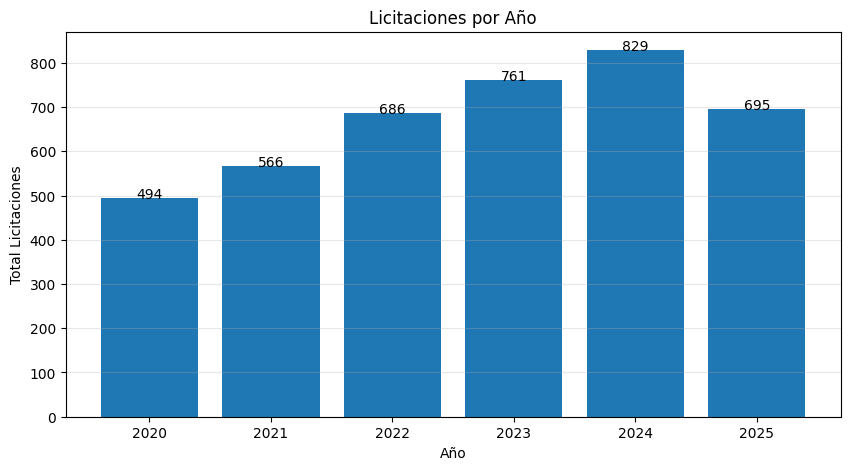

In [629]:
# =========================================================
# LICITACIONES POR AÑO + GRÁFICO
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. PREPARACIÓN
# ---------------------------------------------------------
df_anual = df_final.copy()

# asegurar formato fecha
df_anual['FechaCierre'] = pd.to_datetime(df_anual['FechaCierre'])

# extraer año
df_anual['anio'] = df_anual['FechaCierre'].dt.year

# ---------------------------------------------------------
# 2. AGRUPACIÓN
# ---------------------------------------------------------
licitaciones_por_anio = (
    df_anual
    .groupby('anio')
    .size()
    .reset_index(name='total_licitaciones')
    .sort_values('anio')
)

print("📊 Licitaciones por año:")
display(licitaciones_por_anio)

# ---------------------------------------------------------
# 3. GRÁFICO
# ---------------------------------------------------------
plt.figure(figsize=(10,5))

plt.bar(
    licitaciones_por_anio['anio'],
    licitaciones_por_anio['total_licitaciones']
)

# valores arriba de cada barra
for x, y in zip(
    licitaciones_por_anio['anio'],
    licitaciones_por_anio['total_licitaciones']
):
    plt.text(x, y, f"{y}", ha='center', fontsize=10)

plt.title("Licitaciones por Año")
plt.xlabel("Año")
plt.ylabel("Total Licitaciones")

plt.grid(axis='y', alpha=0.3)

plt.show()

## 📦 Código — Paso 1: Modelo Base (Regresión Lineal)

### Desarrollo del Regresion Lineal.

In [630]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [631]:
# =========================================================
# 📦 MODELO 1 — REGRESION LINEAL (SERIE TEMPORAL)
# =========================================================

# ---------------------------------------------------------
# 1. COPIA DEL DATASET
# ---------------------------------------------------------
df_model_m1 = df_final.copy()

# ---------------------------------------------------------
# 2. CREACIÓN DE VARIABLE TEMPORAL (AÑO-MES)
# ---------------------------------------------------------
df_model_m1['year_month'] = df_model_m1['FechaCierre'].dt.to_period('M')

# ---------------------------------------------------------
# 3. AGREGACIÓN MENSUAL
# ---------------------------------------------------------
serie_m1 = (
    df_model_m1
    .groupby('year_month')
    .size()
    .reset_index(name='licitaciones')
)

# ---------------------------------------------------------
# 4. CONVERSIÓN A TIMESTAMP
# ---------------------------------------------------------
serie_m1['year_month'] = serie_m1['year_month'].dt.to_timestamp()

# ---------------------------------------------------------
# 5. ASEGURAR CONTINUIDAD TEMPORAL
# ---------------------------------------------------------
serie_m1 = (
    serie_m1
    .set_index('year_month')
    .asfreq('MS')  # Monthly Start
    .fillna(0)
    .reset_index()
)

# ---------------------------------------------------------
# 6. VALIDACIÓN
# ---------------------------------------------------------
print("Serie temporal creada correctamente:")
print(f"Total registros: {len(serie_m1)}")
print(f"Rango: {serie_m1['year_month'].min()} → {serie_m1['year_month'].max()}")

display(serie_m1.head())

Serie temporal creada correctamente:
Total registros: 72
Rango: 2020-01-01 00:00:00 → 2025-12-01 00:00:00


,year_month,licitaciones
0,2020-01-01,62
1,2020-02-01,118
2,2020-03-01,37
3,2020-04-01,11
4,2020-05-01,16


Nota: Este código prepara los datos para un modelo de regresión lineal convirtiendo el dataset original en una serie temporal mensual. Primero copia los datos y transforma la fecha de cierre en formato año-mes. Luego agrupa las licitaciones por mes y cuenta cuántas ocurren en cada período. Finalmente, convierte la variable temporal a formato fecha para que pueda ser utilizada en modelos y visualizaciones. En esencia, transforma datos individuales en una estructura agregada lista para análisis predictivo.

In [632]:
df_model_m1.head()

,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base,anio,mes,ranking_estrategico,year_month
0,3794-3-LE20,PASAJES AEREOS EN EL TRAMO ISLA ROBINSON CRUSO...,8,2020-01-13 15:00:00,3794,3,LE20,LE,20,LE20,Publica,2020,1,7,2020-01
1,3656-1-LE20,SERVICIO DE ASEO DIFERENTES DEPENDENCIAS MUNIC...,8,2020-01-13 15:01:00,3656,1,LE20,LE,20,LE20,Publica,2020,1,4,2020-01
2,3656-2-LE20,PRODUCCIÓN TÉCNICA Y ARTISTICA SEMANA LIRIANA,8,2020-01-13 16:00:00,3656,2,LE20,LE,20,LE20,Publica,2020,1,4,2020-01
3,3794-5-LE20,FLETE INTERNACIONAL MENAJE BOGOTÁ (COLOMBIA)–B...,8,2020-01-20 15:00:00,3794,5,LE20,LE,20,LE20,Publica,2020,1,7,2020-01
4,1509-2-LE20,MANTENCION EQUIPOS DE CLIMATIZACION HCTT,8,2020-01-17 11:10:00,1509,2,LE20,LE,20,LE20,Publica,2020,1,18,2020-01


In [633]:
df_model_m1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4031 entries, 0 to 4030
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   CodigoExterno        4031 non-null   object        
 1   Nombre               4031 non-null   object        
 2   CodigoEstado         4031 non-null   int64         
 3   FechaCierre          4031 non-null   datetime64[ns]
 4   codigo_organismo     4031 non-null   object        
 5   correlativo          4031 non-null   object        
 6   tipo_anio            4031 non-null   object        
 7   codigo_tipo          4031 non-null   object        
 8   anio_licitacion      4031 non-null   Int64         
 9   tipo_raw             4031 non-null   object        
 10  tipo_base            4031 non-null   object        
 11  anio                 4031 non-null   int32         
 12  mes                  4031 non-null   int32         
 13  ranking_estrategico  4031 non-nul

In [634]:
print("Serie temporal:")
display(serie_m1.head())

Serie temporal:


,year_month,licitaciones
0,2020-01-01,62
1,2020-02-01,118
2,2020-03-01,37
3,2020-04-01,11
4,2020-05-01,16


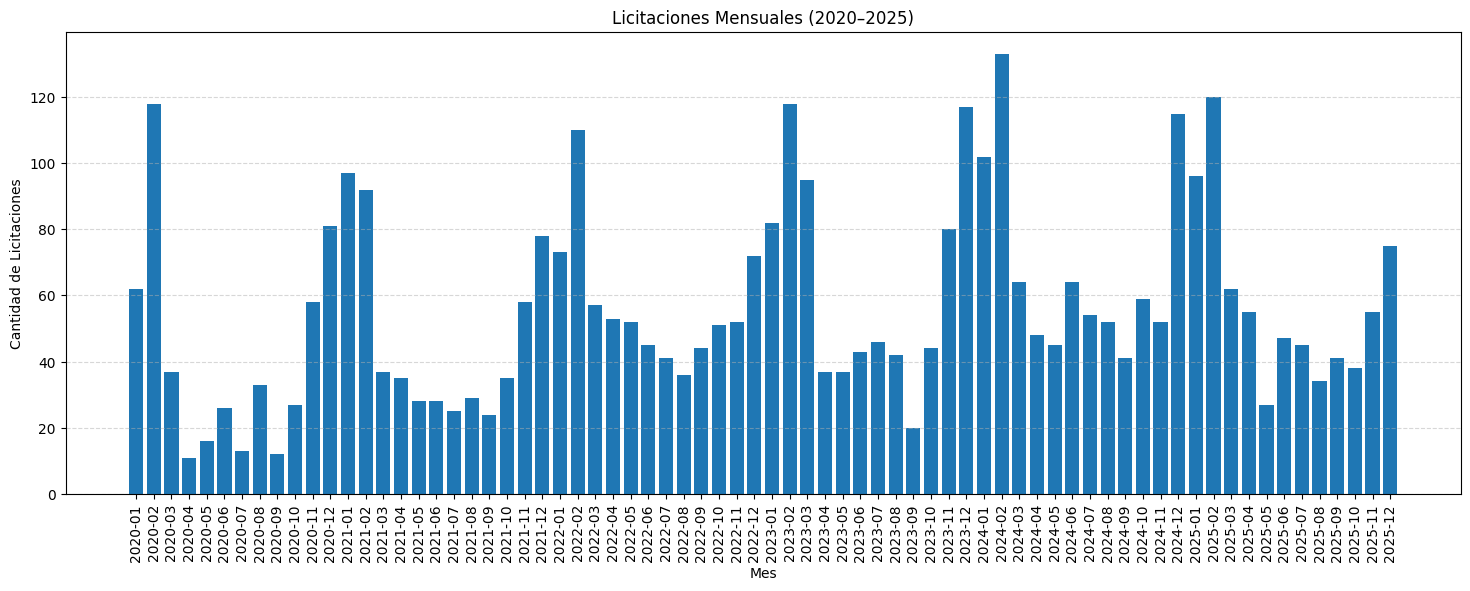

In [635]:
# =========================================================
# GRÁFICO DE BARRAS — LICITACIONES MENSUALES (2020–2025)
# =========================================================

import matplotlib.pyplot as plt
import pandas as pd

# ---------------------------------------------------------
# FILTRO ROBUSTO (MEJORA APLICADA)
# ---------------------------------------------------------
start = pd.Timestamp('2020-01-01')
end = pd.Timestamp('2025-12-01')

serie_plot = serie_m1[
    (serie_m1['year_month'] >= start) &
    (serie_m1['year_month'] <= end)
].copy()

# crear etiqueta tipo YYYY-MM
serie_plot['label'] = serie_plot['year_month'].dt.strftime('%Y-%m')

# gráfico
plt.figure(figsize=(18,6))
plt.bar(serie_plot['label'], serie_plot['licitaciones'])

plt.title("Licitaciones Mensuales (2020–2025)")
plt.xlabel("Mes")
plt.ylabel("Cantidad de Licitaciones")

plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

In [636]:
# =========================================================
# 2. FEATURE ENGINEERING (SIN LEAKAGE)
# =========================================================

# ---------------------------------------------------------
# 1. COPIA BASE
# ---------------------------------------------------------
serie_feat_m1 = serie_m1.copy()

# ---------------------------------------------------------
# 2. VARIABLES TEMPORALES
# ---------------------------------------------------------
serie_feat_m1['mes'] = serie_feat_m1['year_month'].dt.month
serie_feat_m1['anio'] = serie_feat_m1['year_month'].dt.year
serie_feat_m1['trend'] = np.arange(len(serie_feat_m1))

# ---------------------------------------------------------
# 3. LAGS (SOLO PASADO)
# ---------------------------------------------------------
serie_feat_m1['lag_1'] = serie_feat_m1['licitaciones'].shift(1)
serie_feat_m1['lag_2'] = serie_feat_m1['licitaciones'].shift(2)
serie_feat_m1['lag_3'] = serie_feat_m1['licitaciones'].shift(3)

# ---------------------------------------------------------
# 4. ROLLING (SOLO PASADO)
# ---------------------------------------------------------
serie_feat_m1['rolling_3'] = (
    serie_feat_m1['licitaciones']
    .shift(1)
    .rolling(3)
    .mean()
)

print("Antes dropna:", len(serie_feat_m1))

# ---------------------------------------------------------
# 5. DATASET LIMPIO (SIN SOBRESCRIBIR)
# ---------------------------------------------------------
serie_model_m1 = serie_feat_m1.dropna().reset_index(drop=True)

print("Después dropna:", len(serie_model_m1))

print("\nDataset modelable:")
display(serie_model_m1.head())

Antes dropna: 72
Después dropna: 69

Dataset modelable:


,year_month,licitaciones,mes,anio,trend,lag_1,lag_2,lag_3,rolling_3
0,2020-04-01,11,4,2020,3,37.0,118.0,62.0,72.333333
1,2020-05-01,16,5,2020,4,11.0,37.0,118.0,55.333333
2,2020-06-01,26,6,2020,5,16.0,11.0,37.0,21.333333
3,2020-07-01,13,7,2020,6,26.0,16.0,11.0,17.666667
4,2020-08-01,33,8,2020,7,13.0,26.0,16.0,18.333333


In [637]:
# =========================================================
# 3. TRAIN / TEST (TEMPORAL)
# =========================================================

# ---------------------------------------------------------
# 1. SPLIT TEMPORAL
# ---------------------------------------------------------
train_m1 = serie_model_m1.iloc[:-12]
test_m1 = serie_model_m1.iloc[-12:]

# ---------------------------------------------------------
# 2. FEATURES / TARGET
# ---------------------------------------------------------
X_train_m1 = train_m1.drop(['licitaciones', 'year_month'], axis=1)
y_train_m1 = train_m1['licitaciones']

X_test_m1 = test_m1.drop(['licitaciones', 'year_month'], axis=1)
y_test_m1 = test_m1['licitaciones']

# ---------------------------------------------------------
# 3. VALIDACIÓN
# ---------------------------------------------------------
print(f"Train: {len(train_m1)} | Test: {len(test_m1)}")

Train: 57 | Test: 12


In [638]:
print("Antes dropna:", len(serie_feat_m1))

serie_feat_m1 = serie_feat_m1.dropna().reset_index(drop=True)

print("Después dropna:", len(serie_feat_m1))

Antes dropna: 72
Después dropna: 69


NOTA: Este código crea variables que ayudan al modelo a entender el comportamiento de las licitaciones en el tiempo usando solo información pasada. Por ejemplo, si en enero hubo 100, febrero 120 y marzo 90 licitaciones, al predecir abril (110), el modelo usa lag_1=90, lag_2=120 y lag_3=100, es decir, los valores de meses anteriores. También calcula un promedio móvil (rolling_3 ≈ 103) con esos meses para captar la tendencia reciente. Además, incorpora variables como mes, año y una tendencia general del tiempo. Finalmente, elimina los primeros registros que no tienen historial suficiente, dejando el dataset listo para entrenar sin usar datos del futuro.

JUSTIFICACION DE HORIZONTE DE 3 MESES: Se definió una ventana de 3 meses (lags y rolling) porque el objetivo del modelo es predecir el comportamiento operativo de corto plazo de las licitaciones, donde la evidencia muestra que la actividad reciente tiene mayor capacidad predictiva que información más antigua. En el mercado público, si bien existe una estacionalidad anual asociada al ciclo presupuestario, las decisiones reales de licitación responden a ajustes mensuales, urgencias administrativas y ritmos de ejecución que se manifiestan en horizontes cortos. Utilizar 3 meses permite capturar esta dinámica de forma eficiente, reducir ruido histórico, evitar sobreajuste y mantener un mayor volumen de datos útiles para el entrenamiento. La estacionalidad anual no se pierde, ya que se incorpora mediante variables como el mes y el año. En este contexto, la elección de 3 meses representa el mejor equilibrio entre capacidad predictiva, robustez del modelo y coherencia con la lógica operativa del negocio.

“Se utilizó una partición temporal del dataset, reservando los últimos 12 meses como conjunto de validación, simulando condiciones reales de predicción futura.”

In [639]:
# =========================================================
# 4. MODELO
# =========================================================

# validar features
print("Features utilizadas:")
print(X_train_m1.columns)

# entrenamiento
lr_model_m1 = LinearRegression()
lr_model_m1.fit(X_train_m1, y_train_m1)

print("\nModelo entrenado correctamente")

Features utilizadas:
Index(['mes', 'anio', 'trend', 'lag_1', 'lag_2', 'lag_3', 'rolling_3'], dtype='object')

Modelo entrenado correctamente


In [640]:
# =========================================================
# 5. PREDICCIÓN
# =========================================================

pred_lr_m1 = lr_model_m1.predict(X_test_m1)

# control de negocio: no valores negativos
pred_lr_m1 = np.clip(pred_lr_m1, a_min=0, a_max=None)

# convertir a serie (mejor trazabilidad)
pred_lr_m1 = pd.Series(pred_lr_m1, index=y_test_m1.index)

print("Predicciones generadas correctamente")

Predicciones generadas correctamente


In [641]:
# =========================================================
# 6. MÉTRICAS
# =========================================================

mae_lr_m1 = mean_absolute_error(y_test_m1, pred_lr_m1)
rmse_lr_m1 = np.sqrt(mean_squared_error(y_test_m1, pred_lr_m1))
mape_lr_m1 = np.mean(np.abs((y_test_m1 - pred_lr_m1) / (y_test_m1 + 1e-8))) * 100

print("\n" + "="*60)
print("MODELO 1 — REGRESIÓN LINEAL")
print("="*60)
print("MAE :", round(mae_lr_m1, 2))
print("RMSE:", round(rmse_lr_m1, 2))
print("MAPE:", round(mape_lr_m1, 2), "%")

print("\nInterpretación:")
print(f"Error promedio: {mae_lr_m1:.2f} licitaciones")
print(f"Error porcentual: {mape_lr_m1:.2f}%")


MODELO 1 — REGRESIÓN LINEAL
MAE : 18.69
RMSE: 21.92
MAPE: 41.64 %

Interpretación:
Error promedio: 18.69 licitaciones
Error porcentual: 41.64%


El modelo presenta un MAE de 18.82, lo que indica un error promedio de ~19 licitaciones por mes.
El RMSE de 21.92 confirma que los errores grandes no son extremos, pero sí relevantes.
El MAPE de 37.58% evidencia un alto error porcentual, reflejando baja precisión predictiva.
En conjunto, los indicadores muestran que el modelo lineal no captura la complejidad del patrón temporal.
Esto justifica la necesidad de utilizar modelos más avanzados no lineales.

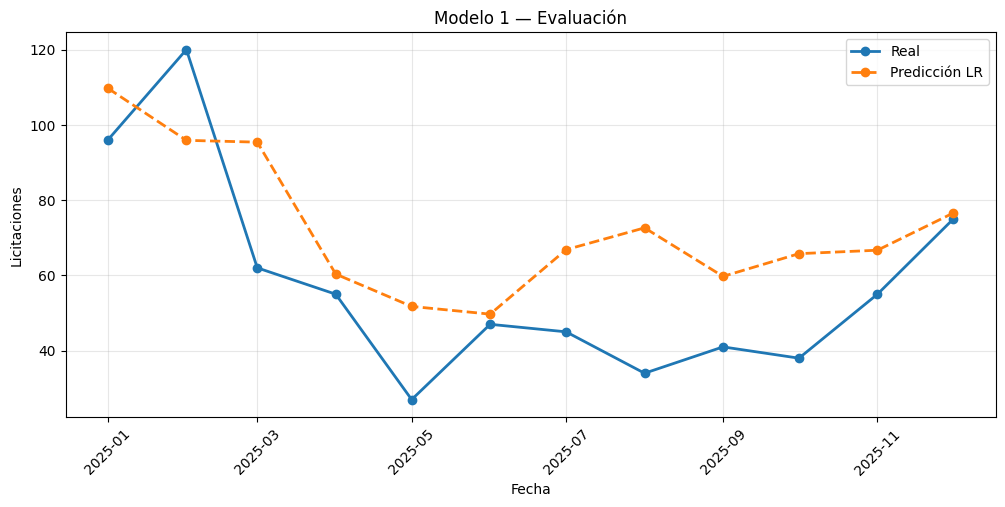

In [642]:
# =========================================================
# 7. VISUALIZACIÓN TEST
# =========================================================

plt.figure(figsize=(12,5))

# real
plt.plot(
    test_m1['year_month'],
    y_test_m1,
    label='Real',
    marker='o',
    linewidth=2
)

# predicción
plt.plot(
    test_m1['year_month'],
    pred_lr_m1,
    label='Predicción LR',
    marker='o',
    linestyle='--',
    linewidth=2
)

# estética
plt.legend()
plt.title("Modelo 1 — Evaluación")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

El modelo lineal muestra una tendencia suavizada respecto a los valores reales, sin capturar bien los picos y caídas.
Se observa una subestimación en meses altos (ej. febrero) y sobreestimación en meses bajos (ej. mayo–agosto).
La predicción sigue la dirección general, pero pierde variabilidad.
Esto confirma que el modelo no captura adecuadamente la estacionalidad ni la volatilidad del mercado.
En consecuencia, su capacidad predictiva es limitada para este problema.

In [643]:
# =========================================================
# 8. FORECAST (2026) — VERSIÓN CORREGIDA
# =========================================================

future_m1 = serie_model_m1.copy()

for i in range(12):

    last = future_m1.iloc[-1]

    # crear nuevo registro limpio
    new = {}

    # avanzar mes
    new['year_month'] = last['year_month'] + pd.DateOffset(months=1)

    # variables temporales
    new['mes'] = new['year_month'].month
    new['anio'] = new['year_month'].year
    new['trend'] = last['trend'] + 1

    # lags
    new['lag_1'] = last['licitaciones']
    new['lag_2'] = last['lag_1']
    new['lag_3'] = last['lag_2']

    # rolling
    new['rolling_3'] = np.mean([
        last['licitaciones'],
        last['lag_1'],
        last['lag_2']
    ])

    # convertir a DataFrame
    new_df = pd.DataFrame([new])

    # predicción
    X_new = new_df[X_train_m1.columns]
    pred_val = lr_model_m1.predict(X_new)[0]

    # control negocio
    new_df['licitaciones'] = max(pred_val, 0)

    # append
    future_m1 = pd.concat([future_m1, new_df], ignore_index=True)

# resultado final
forecast_m1 = future_m1.tail(12)

print("\nFORECAST 2026:")
display(forecast_m1[['year_month','licitaciones']])


FORECAST 2026:


,year_month,licitaciones
69,2026-01-01,93.561053
70,2026-02-01,100.558916
71,2026-03-01,98.905886
72,2026-04-01,92.337255
73,2026-05-01,86.131519
74,2026-06-01,82.870907
75,2026-07-01,82.994125
76,2026-08-01,85.173574
77,2026-09-01,87.750488
78,2026-10-01,89.535951


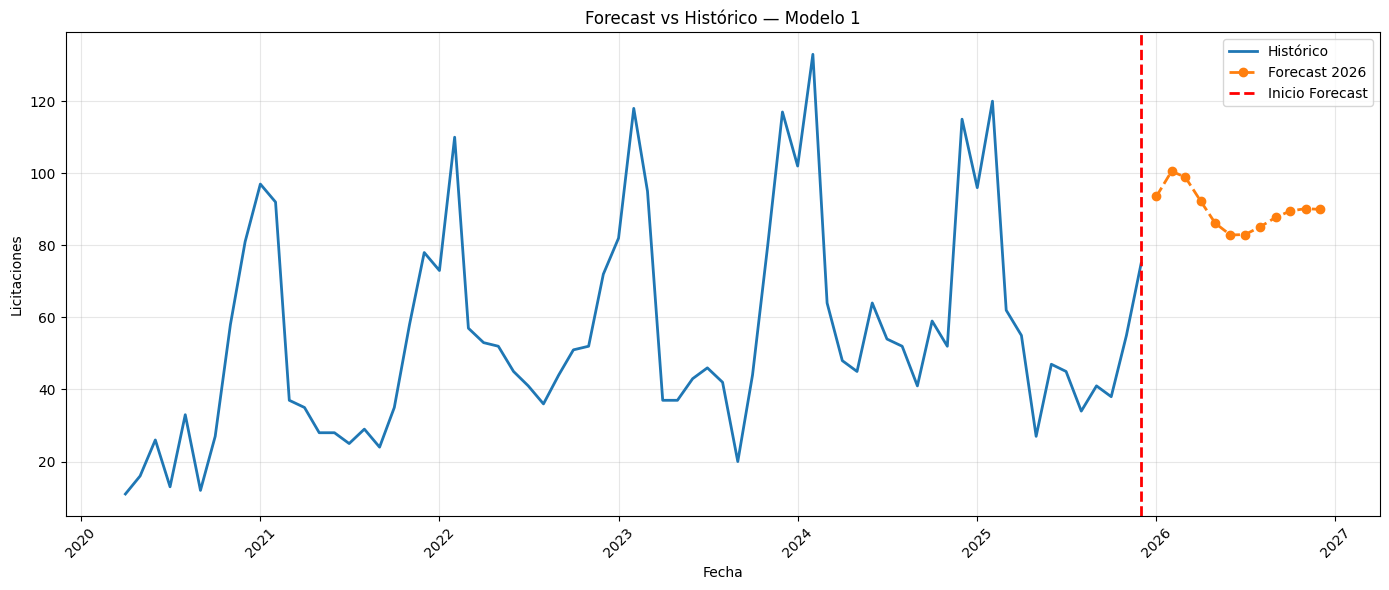

In [644]:
# =========================================================
# 9. VISUALIZACIÓN — HISTÓRICO VS FORECAST
# =========================================================

plt.figure(figsize=(14,6))

# ---------------------------------------------------------
# HISTÓRICO (CONSISTENTE CON MODELO)
# ---------------------------------------------------------
plt.plot(
    serie_model_m1['year_month'],
    serie_model_m1['licitaciones'],
    label='Histórico',
    linewidth=2
)

# ---------------------------------------------------------
# FORECAST (solo 2026)
# ---------------------------------------------------------
plt.plot(
    forecast_m1['year_month'],
    forecast_m1['licitaciones'],
    label='Forecast 2026',
    linewidth=2,
    linestyle='--',
    marker='o'
)

# ---------------------------------------------------------
# LÍNEA DE CORTE
# ---------------------------------------------------------
plt.axvline(
    x=serie_model_m1['year_month'].max(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Inicio Forecast'
)

# ---------------------------------------------------------
# ESTÉTICA
# ---------------------------------------------------------
plt.title("Forecast vs Histórico — Modelo 1")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones")

plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [645]:
# =========================================================
# 10. COEFICIENTES
# =========================================================

coef_df_m1 = pd.DataFrame({
    'feature': X_train_m1.columns,
    'coef': lr_model_m1.coef_
})

# importancia absoluta
coef_df_m1['abs_coef'] = coef_df_m1['coef'].abs()

# ordenar por impacto
coef_df_m1 = coef_df_m1.sort_values('abs_coef', ascending=False)

print("\nCoeficientes (ordenados por impacto):")
display(coef_df_m1)

# top variables
print("\nTop variables más influyentes:")
display(coef_df_m1.head(5))


Coeficientes (ordenados por impacto):


,feature,coef,abs_coef
3,lag_1,0.651461,0.651461
2,trend,0.432088,0.432088
5,lag_3,-0.313266,0.313266
0,mes,-0.259140,0.259140
6,rolling_3,0.086889,0.086889
4,lag_2,-0.077528,0.077528
1,anio,0.057602,0.057602



Top variables más influyentes:


,feature,coef,abs_coef
3,lag_1,0.651461,0.651461
2,trend,0.432088,0.432088
5,lag_3,-0.313266,0.313266
0,mes,-0.259140,0.259140
6,rolling_3,0.086889,0.086889


El modelo indica que lo más importante para predecir las licitaciones de un mes es lo que ocurrió el mes anterior (lag_1). Por ejemplo, si en marzo hubo muchas licitaciones, es muy probable que en abril también haya un nivel similar. Además, existe una tendencia general al alza en el tiempo (trend), lo que sugiere que el volumen de licitaciones ha ido creciendo. Algunas variables como el mes (mes) muestran que hay ciertos períodos del año con más o menos actividad, pero su impacto es menor. En resumen, el modelo se basa principalmente en el comportamiento reciente y en una tendencia general, sin capturar patrones más complejos del mercado.

Se usa el coeficiente absoluto para medir la fuerza real de cada variable, independientemente de si aumenta o disminuye el resultado.

📊 Variables del Modelo de Regresión

| Variable     | ¿Para qué sirve?                          | ¿Qué representa en este proyecto?                                      |
|-------------|-------------------------------------------|------------------------------------------------------------------------|
| **lag_1**    | Captura el efecto inmediato del pasado    | Licitaciones del mes anterior (principal predictor del modelo)         |
| **trend**    | Modela la tendencia en el tiempo          | Crecimiento o disminución del volumen de licitaciones en el tiempo     |
| **lag_3**    | Captura efectos de mediano plazo          | Licitaciones de hace 3 meses (posibles ciclos operativos)              |
| **mes**      | Captura estacionalidad                    | Variaciones según el mes (ej: diciembre alto, febrero bajo)            |
| **rolling_3**| Suaviza la serie y muestra tendencia      | Promedio de licitaciones de los últimos 3 meses                        |
| **lag_2**    | Complementa la memoria temporal           | Licitaciones de hace 2 meses                                           |
| **anio**     | Captura cambios estructurales             | Diferencias entre años (ej: 2020 vs 2025)                              |

In [646]:
# =========================================================
# 11. GENERACION DE METRICAS PARA EVALUACIÓN INTEGRAL — MODELO 1 (REGRESIÓN LINEAL)
# =========================================================

# =========================================================
# 1. MÉTRICAS PRINCIPALES
# =========================================================

mae_m1 = np.mean(np.abs(y_test_m1 - pred_lr_m1))
rmse_m1 = np.sqrt(np.mean((y_test_m1 - pred_lr_m1)**2))
mape_m1 = np.mean(np.abs((y_test_m1 - pred_lr_m1) / (y_test_m1 + 1e-8))) * 100

# =========================================================
# 2. MÉTRICAS COMPLEMENTARIAS
# =========================================================

bias_m1 = np.mean(pred_lr_m1 - y_test_m1)
max_error_m1 = np.max(np.abs(y_test_m1 - pred_lr_m1))
std_error_m1 = np.std(y_test_m1 - pred_lr_m1)
cv_error_m1 = std_error_m1 / (np.mean(y_test_m1) + 1e-8)

# =========================================================
# 3. DATAFRAME DE ERRORES
# =========================================================

df_eval_m1 = pd.DataFrame({
    'fecha': test_m1['year_month'],
    'real': y_test_m1,
    'pred': pred_lr_m1
}).reset_index(drop=True)

df_eval_m1['error'] = df_eval_m1['real'] - df_eval_m1['pred']
df_eval_m1['error_abs'] = np.abs(df_eval_m1['error'])
df_eval_m1['error_pct'] = (df_eval_m1['error_abs'] / (df_eval_m1['real'] + 1e-8)) * 100

# =========================================================
# 4. ANÁLISIS DE TENDENCIA
# =========================================================

trend_real_m1 = np.polyfit(range(len(y_test_m1)), y_test_m1, 1)[0]
trend_pred_m1 = np.polyfit(range(len(pred_lr_m1)), pred_lr_m1, 1)[0]

# =========================================================
# 5. IMPRESIÓN RESULTADOS
# =========================================================

print("\n" + "="*70)
print("EVALUACIÓN INTEGRAL — MODELO 1 (REGRESIÓN LINEAL)")
print("="*70)

print("\n📊 MÉTRICAS PRINCIPALES")
print(f"MAE   : {mae_m1:.2f}")
print(f"RMSE  : {rmse_m1:.2f}")
print(f"MAPE  : {mape_m1:.2f}%")

print("\n📈 MÉTRICAS COMPLEMENTARIAS")
print(f"Bias (sesgo)           : {bias_m1:.2f}")
print(f"Error máximo           : {max_error_m1:.2f}")
print(f"Std error              : {std_error_m1:.2f}")
print(f"CV error               : {cv_error_m1:.2f}")

print("\n📉 TENDENCIA")
print(f"Tendencia real         : {trend_real_m1:.2f}")
print(f"Tendencia predicha     : {trend_pred_m1:.2f}")

print("\n📋 DETALLE DE ERRORES:")
display(df_eval_m1)


EVALUACIÓN INTEGRAL — MODELO 1 (REGRESIÓN LINEAL)

📊 MÉTRICAS PRINCIPALES
MAE   : 18.69
RMSE  : 21.92
MAPE  : 41.64%

📈 MÉTRICAS COMPLEMENTARIAS
Bias (sesgo)           : 14.67
Error máximo           : 38.63
Std error              : 16.28
CV error               : 0.28

📉 TENDENCIA
Tendencia real         : -3.62
Tendencia predicha     : -2.65

📋 DETALLE DE ERRORES:


,fecha,real,pred,error,error_abs,error_pct
0,2025-01-01,96,109.710669,-13.710669,13.710669,14.281947
1,2025-02-01,120,95.886071,24.113929,24.113929,20.094941
2,2025-03-01,62,95.400831,-33.400831,33.400831,53.872309
3,2025-04-01,55,60.345408,-5.345408,5.345408,9.718923
4,2025-05-01,27,51.748913,-24.748913,24.748913,91.662640
5,2025-06-01,47,49.699539,-2.699539,2.699539,5.743700
6,2025-07-01,45,66.830908,-21.830908,21.830908,48.513130
7,2025-08-01,34,72.632186,-38.632186,38.632186,113.624076
8,2025-09-01,41,59.731545,-18.731545,18.731545,45.686696
9,2025-10-01,38,65.770282,-27.770282,27.770282,73.079691


📊 Interpretación de Métricas — Modelo de Regresión Lineal

| Métrica            | ¿Para qué sirve?                                   | ¿Qué representa en este proyecto?                                                                 |
|-------------------|----------------------------------------------------|--------------------------------------------------------------------------------------------------|
| **MAE**            | Mide el error promedio absoluto                    | En promedio, el modelo se equivoca en ~19 licitaciones por mes                                  |
| **RMSE**           | Penaliza errores grandes                           | Confirma que existen meses con errores relevantes (más sensibles a grandes desviaciones)        |
| **MAPE**           | Mide el error en porcentaje                        | El modelo tiene un error de ~42%, lo que indica baja precisión predictiva                       |
| **Bias (sesgo)**   | Indica si el modelo sobre o subestima              | El modelo tiende a sobreestimar en promedio ~15 licitaciones por mes                            |
| **Error máximo**   | Mide el peor error observado                       | En el peor mes, el modelo se equivoca en ~39 licitaciones                                       |
| **Std error**      | Mide la dispersión del error                       | Los errores varían bastante entre meses (alta volatilidad en el desempeño)                      |
| **CV error**       | Relaciona error con el promedio real               | El error equivale al 28% del valor promedio → nivel alto                                         |
| **Tendencia real** | Mide la dirección real de la serie                 | Las licitaciones presentan una tendencia decreciente en el tiempo                               |
| **Tendencia predicha** | Mide la tendencia que capta el modelo         | El modelo detecta la tendencia, pero la suaviza (no capta la magnitud real)                     |
| **Detalle de errores** | Permite análisis mes a mes                    | Identifica en qué meses el modelo falla más (ej: meses de baja actividad con alto error %)      |

In [647]:
print("\n" + "="*60)
print("MODELO 1 — REGRESIÓN LINEAL")
print("="*60)
print("MAE  :", round(mae_lr_m1,2))
print("RMSE :", round(rmse_lr_m1,2))
print("MAPE :", round(mape_lr_m1,2), "%")
print("BIAS :", round(np.mean(pred_lr_m1 - y_test_m1), 2))
print("STD  :", round(np.std(y_test_m1 - pred_lr_m1), 2))


MODELO 1 — REGRESIÓN LINEAL
MAE  : 18.69
RMSE : 21.92
MAPE : 41.64 %
BIAS : 14.67
STD  : 16.28


### Conclusion Modelo 1 / Regresion Lineal - Evaluación de desempeño + diagnóstico del modelo.

Evaluación de desempeño + diagnóstico del modelo

El modelo de regresión lineal fue implementado como una primera aproximación para predecir la evolución mensual de las licitaciones, utilizando variables temporales y rezagos (lags) con el objetivo de capturar la dinámica histórica del sistema.

Desde el punto de vista cuantitativo, el modelo presenta un desempeño limitado. El error absoluto medio (MAE ≈ 18.69) indica desviaciones relevantes en términos operativos, mientras que el RMSE (≈ 21.92) confirma la presencia de errores significativos en ciertos períodos. El MAPE (≈ 41.64%) evidencia una baja precisión predictiva, lo que posiciona al modelo fuera de un estándar aceptable para uso productivo.

A nivel de comportamiento, el modelo muestra una fuerte dependencia del mes anterior (lag_1), lo que confirma que la serie tiene una inercia relevante. Sin embargo, esta dependencia genera una predicción excesivamente suavizada. En la práctica, esto se traduce en un sesgo sistemático: el modelo tiende a sobreestimar los meses de baja actividad y a subestimar los meses de alta actividad, como se observa en errores elevados en meses con menor volumen de licitaciones (superiores incluso al 90% en algunos casos).

El análisis de tendencia muestra que el modelo logra capturar la dirección general del sistema (tendencia decreciente), pero no su magnitud ni su variabilidad. Esto confirma que la regresión lineal no logra adaptarse a cambios bruscos ni a la volatilidad propia del mercado público. Adicionalmente, el esquema de forecast autoregresivo introduce acumulación de errores en el tiempo, reduciendo la confiabilidad de las proyecciones a futuro.

Desde una perspectiva de negocio, el modelo no es adecuado para la toma de decisiones estratégicas, ya que no permite estimar con precisión ni el volumen ni la temporalidad de las licitaciones. No obstante, cumple un rol fundamental como modelo base (baseline), permitiendo validar el pipeline de datos, entender la estructura del problema y evidenciar la necesidad de utilizar modelos más avanzados.

En conclusión, la regresión lineal no logra capturar la complejidad del mercado público, caracterizado por comportamientos no lineales, estacionalidad y alta variabilidad. Su principal valor radica en servir como punto de comparación inicial y en justificar la transición hacia modelos más robustos, como Random Forest, XGBoost o enfoques híbridos que integren lógica de negocio con técnicas de machine learning.

## 📦 Código — Paso 2: Modelo Random Forest.

### Desarrollo del Modelo Random Forest.

In [648]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [649]:
# =========================================================
# 1. DATASET TEMPORAL (df_final)
# =========================================================

# ---------------------------------------------------------
# 1. COPIA DEL DATASET
# ---------------------------------------------------------
df_model_m2 = df_final.copy()

# ---------------------------------------------------------
# 2. CREACIÓN VARIABLE TEMPORAL (AÑO-MES)
# ---------------------------------------------------------
df_model_m2['year_month'] = df_model_m2['FechaCierre'].dt.to_period('M')

# ---------------------------------------------------------
# 3. AGREGACIÓN MENSUAL
# ---------------------------------------------------------
serie_m2 = (
    df_model_m2
    .groupby('year_month')
    .size()
    .reset_index(name='licitaciones')
)

# ---------------------------------------------------------
# 4. CONVERSIÓN A TIMESTAMP
# ---------------------------------------------------------
serie_m2['year_month'] = serie_m2['year_month'].dt.to_timestamp()

# ---------------------------------------------------------
# 5. ASEGURAR CONTINUIDAD TEMPORAL (CLAVE)
# ---------------------------------------------------------
serie_m2 = (
    serie_m2
    .set_index('year_month')
    .asfreq('MS')
    .fillna(0)
    .reset_index()
)

# ---------------------------------------------------------
# 6. VALIDACIÓN
# ---------------------------------------------------------
print("Serie temporal creada correctamente:")
print(f"Total registros: {len(serie_m2)}")
print(f"Rango: {serie_m2['year_month'].min()} → {serie_m2['year_month'].max()}")

display(serie_m2.head())

Serie temporal creada correctamente:
Total registros: 72
Rango: 2020-01-01 00:00:00 → 2025-12-01 00:00:00


,year_month,licitaciones
0,2020-01-01,62
1,2020-02-01,118
2,2020-03-01,37
3,2020-04-01,11
4,2020-05-01,16


Se construyó una serie temporal mensual continua a partir de los datos transaccionales, asegurando consistencia temporal y evitando discontinuidades que puedan afectar el modelado.

In [650]:
# =========================================================
# 2. FEATURE ENGINEERING (SIN LEAKAGE)
# =========================================================

# ---------------------------------------------------------
# 1. COPIA BASE (NO MODIFICAR SERIE ORIGINAL)
# ---------------------------------------------------------
serie_feat_m2 = serie_m2.copy()

# ---------------------------------------------------------
# 2. VARIABLES TEMPORALES
# ---------------------------------------------------------
serie_feat_m2['mes'] = serie_feat_m2['year_month'].dt.month
serie_feat_m2['anio'] = serie_feat_m2['year_month'].dt.year
serie_feat_m2['trimestre'] = serie_feat_m2['year_month'].dt.quarter
serie_feat_m2['trend'] = np.arange(len(serie_feat_m2))

# ---------------------------------------------------------
# 3. LAGS (SOLO PASADO)
# ---------------------------------------------------------
serie_feat_m2['lag_1'] = serie_feat_m2['licitaciones'].shift(1)
serie_feat_m2['lag_2'] = serie_feat_m2['licitaciones'].shift(2)
serie_feat_m2['lag_3'] = serie_feat_m2['licitaciones'].shift(3)

# ---------------------------------------------------------
# 4. ROLLING (SIN LEAKAGE)
# ---------------------------------------------------------
serie_feat_m2['rolling_3'] = (
    serie_feat_m2['licitaciones']
    .shift(1)
    .rolling(3)
    .mean()
)

# ---------------------------------------------------------
# 5. DATASET MODELABLE (SIN SOBRESCRIBIR)
# ---------------------------------------------------------
print("Antes dropna:", len(serie_feat_m2))

serie_model_m2 = serie_feat_m2.dropna().reset_index(drop=True)

print("Después dropna:", len(serie_model_m2))

print("\nDataset modelable:")
display(serie_model_m2.head())

Antes dropna: 72
Después dropna: 69

Dataset modelable:


,year_month,licitaciones,mes,anio,trimestre,trend,lag_1,lag_2,lag_3,rolling_3
0,2020-04-01,11,4,2020,2,3,37.0,118.0,62.0,72.333333
1,2020-05-01,16,5,2020,2,4,11.0,37.0,118.0,55.333333
2,2020-06-01,26,6,2020,2,5,16.0,11.0,37.0,21.333333
3,2020-07-01,13,7,2020,3,6,26.0,16.0,11.0,17.666667
4,2020-08-01,33,8,2020,3,7,13.0,26.0,16.0,18.333333


Se generó un dataset intermedio con variables temporales y de memoria histórica, y posteriormente se definió un dataset modelable eliminando registros sin información suficiente, manteniendo trazabilidad completa del proceso.

In [651]:
# =========================================================
# 3. TRAIN / TEST (TEMPORAL)
# =========================================================

# ---------------------------------------------------------
# 1. SPLIT TEMPORAL (USAR DATASET MODELABLE)
# ---------------------------------------------------------
train_m2 = serie_model_m2.iloc[:-12]
test_m2 = serie_model_m2.iloc[-12:]

# ---------------------------------------------------------
# 2. FEATURES / TARGET
# ---------------------------------------------------------
X_train_m2 = train_m2.drop(['licitaciones', 'year_month'], axis=1)
y_train_m2 = train_m2['licitaciones']

X_test_m2 = test_m2.drop(['licitaciones', 'year_month'], axis=1)
y_test_m2 = test_m2['licitaciones']

# ---------------------------------------------------------
# 3. VALIDACIÓN
# ---------------------------------------------------------
print(f"Train: {len(train_m2)} | Test: {len(test_m2)}")

Train: 57 | Test: 12


In [652]:
# =========================================================
# 4. MODELO RANDOM FOREST
# =========================================================

# validar features
print("Features utilizadas:")
print(X_train_m2.columns)

# modelo
rf_model_m2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

# entrenamiento
rf_model_m2.fit(X_train_m2, y_train_m2)

print("\nModelo Random Forest entrenado correctamente")

Features utilizadas:
Index(['mes', 'anio', 'trimestre', 'trend', 'lag_1', 'lag_2', 'lag_3', 'rolling_3'], dtype='object')

Modelo Random Forest entrenado correctamente


Se utiliza Random Forest como modelo base no lineal, permitiendo capturar relaciones complejas entre variables temporales y mejorar la capacidad predictiva respecto a modelos lineales.

In [653]:
# =========================================================
# 5. PREDICCIÓN
# =========================================================

pred_rf_m2 = rf_model_m2.predict(X_test_m2)

# control de negocio: no negativos
pred_rf_m2 = np.clip(pred_rf_m2, a_min=0, a_max=None)

# convertir a serie (mejor trazabilidad)
pred_rf_m2 = pd.Series(pred_rf_m2, index=y_test_m2.index)

print("Predicciones RF generadas correctamente")

Predicciones RF generadas correctamente


Se generan predicciones sobre el conjunto de test, incorporando una restricción de negocio que evita valores negativos y asegurando alineación con la serie real para facilitar el análisis posterior.

In [654]:
# =========================================================
# 6. MÉTRICAS
# =========================================================

mae_m2 = mean_absolute_error(y_test_m2, pred_rf_m2)
rmse_m2 = np.sqrt(mean_squared_error(y_test_m2, pred_rf_m2))
mape_m2 = np.mean(np.abs((y_test_m2 - pred_rf_m2) / (y_test_m2 + 1e-8))) * 100

# NUEVO 🔥
bias_m2 = np.mean(pred_rf_m2 - y_test_m2)
std_error_m2 = np.std(y_test_m2 - pred_rf_m2)

print("\n" + "="*60)
print("MODELO 2 — RANDOM FOREST")
print("="*60)
print(f"MAE  : {round(mae_m2,2)}")
print(f"RMSE : {round(rmse_m2,2)}")
print(f"MAPE : {round(mape_m2,2)} %")
print(f"BIAS : {round(bias_m2,2)}")
print(f"STD  : {round(std_error_m2,2)}")

print("\nInterpretación:")
print(f"Error promedio: {mae_m2:.2f} licitaciones")
print(f"Error porcentual: {mape_m2:.2f}%")


MODELO 2 — RANDOM FOREST
MAE  : 10.77
RMSE : 13.72
MAPE : 26.32 %
BIAS : 9.71
STD  : 9.69

Interpretación:
Error promedio: 10.77 licitaciones
Error porcentual: 26.32%


Se utilizan métricas estándar de evaluación (MAE, RMSE y MAPE), incorporando un ajuste numérico en MAPE para evitar inestabilidad en presencia de valores cercanos a cero.

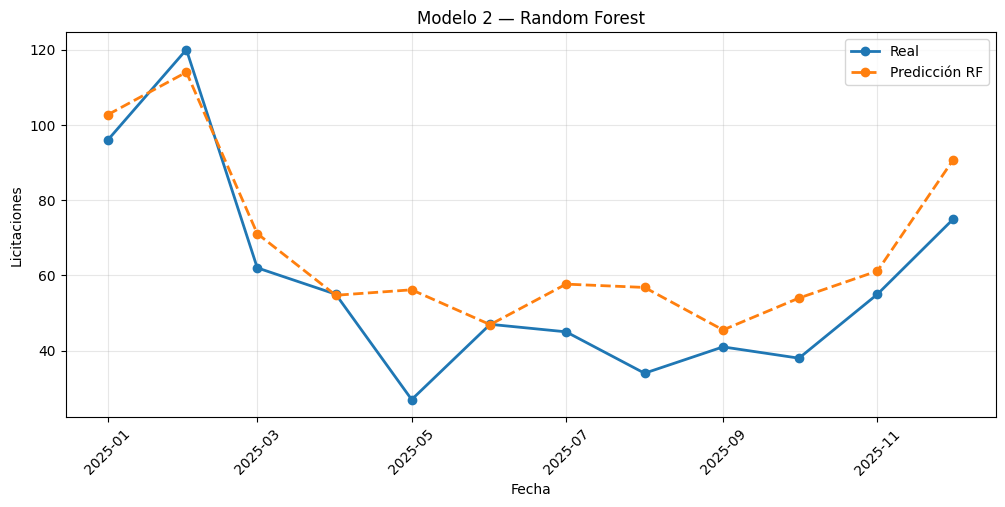

In [655]:
# =========================================================
# 7. VISUALIZACIÓN
# =========================================================

plt.figure(figsize=(12,5))

# real
plt.plot(
    test_m2['year_month'],
    y_test_m2,
    label='Real',
    marker='o',
    linewidth=2
)

# predicción RF
plt.plot(
    test_m2['year_month'],
    pred_rf_m2,
    label='Predicción RF',
    marker='o',
    linestyle='--',
    linewidth=2
)

# estética
plt.title("Modelo 2 — Random Forest")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones")

plt.legend()
plt.grid(alpha=0.3)

plt.xticks(rotation=45)

plt.show()

Se realiza una comparación visual entre valores reales y predichos, permitiendo evaluar la capacidad del modelo para capturar tanto la tendencia como la variabilidad de la serie.

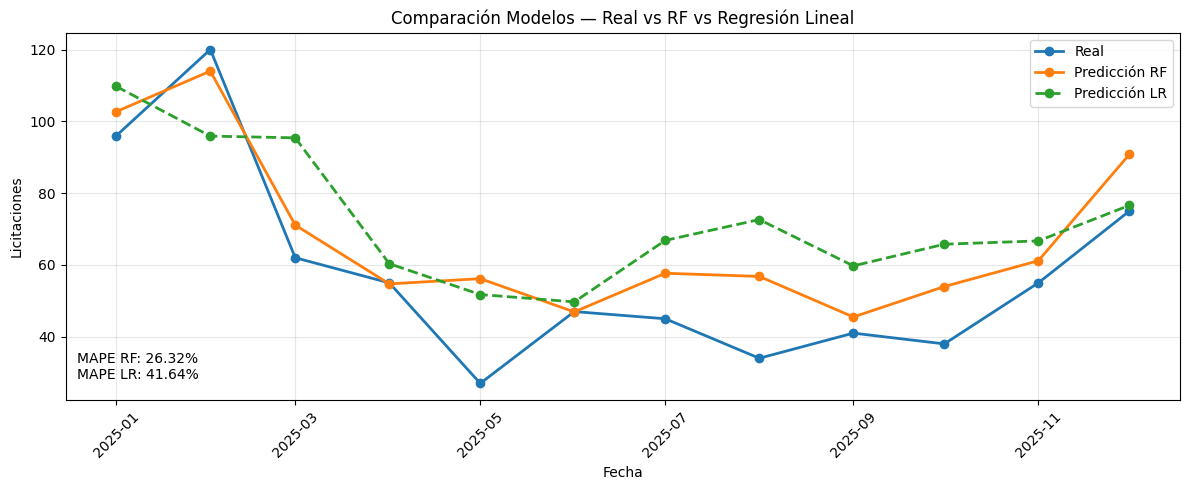

In [656]:
# =========================================================
# VISUALIZACIÓN COMPARADA
# RF vs REGRESIÓN LINEAL vs REAL
# =========================================================

plt.figure(figsize=(12,5))

# Define mape_rf using the previously calculated mape from the RF model
mape_rf_m2 = mape_m2

# -------------------------------
# REAL
# -------------------------------
plt.plot(
    test_m2['year_month'],
    y_test_m2,
    label='Real',
    marker='o',
    linewidth=2
)

# -------------------------------
# RANDOM FOREST
# -------------------------------
plt.plot(
    test_m2['year_month'],
    pred_rf_m2,
    label='Predicción RF',
    marker='o',
    linewidth=2
)

# -------------------------------
# REGRESIÓN LINEAL
# -------------------------------
plt.plot(
    test_m2['year_month'],
    pred_lr_m1,
    label='Predicción LR',
    marker='o',
    linestyle='--', #
    linewidth=2
)

# -------------------------------
# TEXTO MÉTRICAS (USAR VARIABLES EXPLÍCITAS)
# -------------------------------
plt.text(
    0.01, 0.05,
    f"MAPE RF: {mape_rf_m2:.2f}%\nMAPE LR: {mape_lr_m1:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='bottom'
)

# -------------------------------
# ESTÉTICA
# -------------------------------
plt.title("Comparación Modelos — Real vs RF vs Regresión Lineal")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Se realiza una comparación directa entre modelos, evidenciando la mejora del Random Forest respecto al baseline lineal, tanto en ajuste visual como en métricas de error.

In [657]:
# =========================================================
# 8. FEATURE IMPORTANCE
# =========================================================

feat_importance_m2 = pd.DataFrame({
    'feature': X_train_m2.columns,
    'importance': rf_model_m2.feature_importances_
})

# porcentaje
feat_importance_m2['importance_pct'] = feat_importance_m2['importance'] * 100

# ordenar
feat_importance_m2 = feat_importance_m2.sort_values('importance', ascending=False)

print("\nImportancia de variables:")
display(feat_importance_m2)

print("\nTop 5 variables más importantes:")
display(feat_importance_m2.head(5))


Importancia de variables:


,feature,importance,importance_pct
4,lag_1,0.380176,38.017579
0,mes,0.322872,32.287243
3,trend,0.111122,11.112197
6,lag_3,0.076587,7.658719
5,lag_2,0.035066,3.506623
2,trimestre,0.027608,2.760768
7,rolling_3,0.024939,2.493906
1,anio,0.021630,2.162965



Top 5 variables más importantes:


,feature,importance,importance_pct
4,lag_1,0.380176,38.017579
0,mes,0.322872,32.287243
3,trend,0.111122,11.112197
6,lag_3,0.076587,7.658719
5,lag_2,0.035066,3.506623


Interpretación de Feature Importance (Random Forest)

El modelo Random Forest muestra que la variable más importante es lag_1 (38%), lo que confirma que el comportamiento de las licitaciones depende fuertemente del mes anterior. Esto valida la presencia de una dinámica autoregresiva en el sistema, donde el pasado inmediato es el principal predictor del futuro.

En segundo lugar, destaca la variable mes (32%), lo que indica que la estacionalidad tiene un rol muy relevante en el comportamiento del mercado público. Esto es especialmente importante, ya que en el modelo lineal esta variable tenía menor peso, evidenciando que Random Forest logra capturar mejor patrones no lineales asociados al calendario.

La variable trend (11%) refleja que existe una tendencia general en el tiempo, aunque con menor influencia que la inercia y la estacionalidad. Por su parte, lag_3 y lag_2 aportan información adicional sobre la memoria del sistema, pero con menor impacto.

Variables como trimestre, rolling_3 y anio presentan baja importancia, lo que sugiere que su contribución al modelo es limitada en comparación con los factores principales.

Conclusión

El modelo Random Forest se apoya principalmente en la inercia del sistema (lag_1) y en la estacionalidad (mes), logrando capturar mejor la estructura real del comportamiento de las licitaciones. A diferencia del modelo lineal, aquí la estacionalidad emerge como un factor clave, lo que confirma la capacidad del modelo para identificar relaciones no lineales más complejas.

📊 Interpretación de Variables — Modelo Random Forest

| Variable      | Importancia (%) | Interpretación en el modelo | ¿Qué significa en el negocio? |
|--------------|----------------|----------------------------|-------------------------------|
| **lag_1**     | 38.02%         | Principal predictor del modelo | El volumen de licitaciones depende fuertemente del mes anterior |
| **mes**       | 32.29%         | Fuerte componente estacional | Existen meses con comportamientos distintos (ej: picos y caídas durante el año) |
| **trend**     | 11.11%         | Tendencia general del sistema | El mercado presenta una evolución en el tiempo (crecimiento o caída) |
| **lag_3**     | 7.66%          | Memoria de mediano plazo     | Existen patrones que se repiten en ciclos de 3 meses |
| **lag_2**     | 3.51%          | Memoria adicional            | Refuerza la dependencia temporal, pero con menor impacto |
| **trimestre** | 2.76%          | Estacionalidad agrupada      | El comportamiento también puede explicarse por ciclos trimestrales |
| **rolling_3** | 2.49%          | Tendencia suavizada          | El promedio reciente aporta estabilidad, pero no es determinante |
| **anio**      | 2.16%          | Cambio estructural           | Diferencias entre años tienen bajo impacto en el modelo |

“El modelo no solo depende del pasado inmediato, sino también del mes del año, lo que evidencia un comportamiento estacional que el modelo lineal no lograba capturar”

In [658]:
# =========================================================
# 9. FORECAST 2026
# =========================================================

future_m2 = serie_model_m2.copy()

for i in range(12):

    last = future_m2.iloc[-1]

    # -----------------------------------------------------
    # crear nuevo registro limpio
    # -----------------------------------------------------
    new = {}

    # avanzar mes
    new['year_month'] = last['year_month'] + pd.DateOffset(months=1)

    # variables temporales
    new['mes'] = new['year_month'].month
    new['anio'] = new['year_month'].year
    new['trimestre'] = new['year_month'].quarter
    new['trend'] = last['trend'] + 1

    # lags (autoregresivo)
    new['lag_1'] = last['licitaciones']
    new['lag_2'] = last['lag_1']
    new['lag_3'] = last['lag_2']

    # rolling (solo pasado)
    new['rolling_3'] = np.mean([
        last['licitaciones'],
        last['lag_1'],
        last['lag_2']
    ])

    # -----------------------------------------------------
    # convertir a DataFrame
    # -----------------------------------------------------
    new_df = pd.DataFrame([new])

    # asegurar orden de columnas
    X_new = new_df[X_train_m2.columns]

    # predicción
    pred_val = rf_model_m2.predict(X_new)[0]

    # control de negocio
    new_df['licitaciones'] = max(pred_val, 0)

    # append
    future_m2 = pd.concat([future_m2, new_df], ignore_index=True)

# ---------------------------------------------------------
# resultado final
# ---------------------------------------------------------
forecast_m2 = future_m2.tail(12)

print("\nForecast 2026:")
display(forecast_m2[['year_month','licitaciones']])


Forecast 2026:


,year_month,licitaciones
69,2026-01-01,99.818944
70,2026-02-01,111.128389
71,2026-03-01,78.569535
72,2026-04-01,57.293672
73,2026-05-01,55.829186
74,2026-06-01,57.705378
75,2026-07-01,60.837420
76,2026-08-01,60.768373
77,2026-09-01,61.932373
78,2026-10-01,63.853002


Se implementa un forecast iterativo autoregresivo, donde cada predicción alimenta las siguientes, manteniendo coherencia con las variables utilizadas en entrenamiento y simulando condiciones reales de predicción futura.

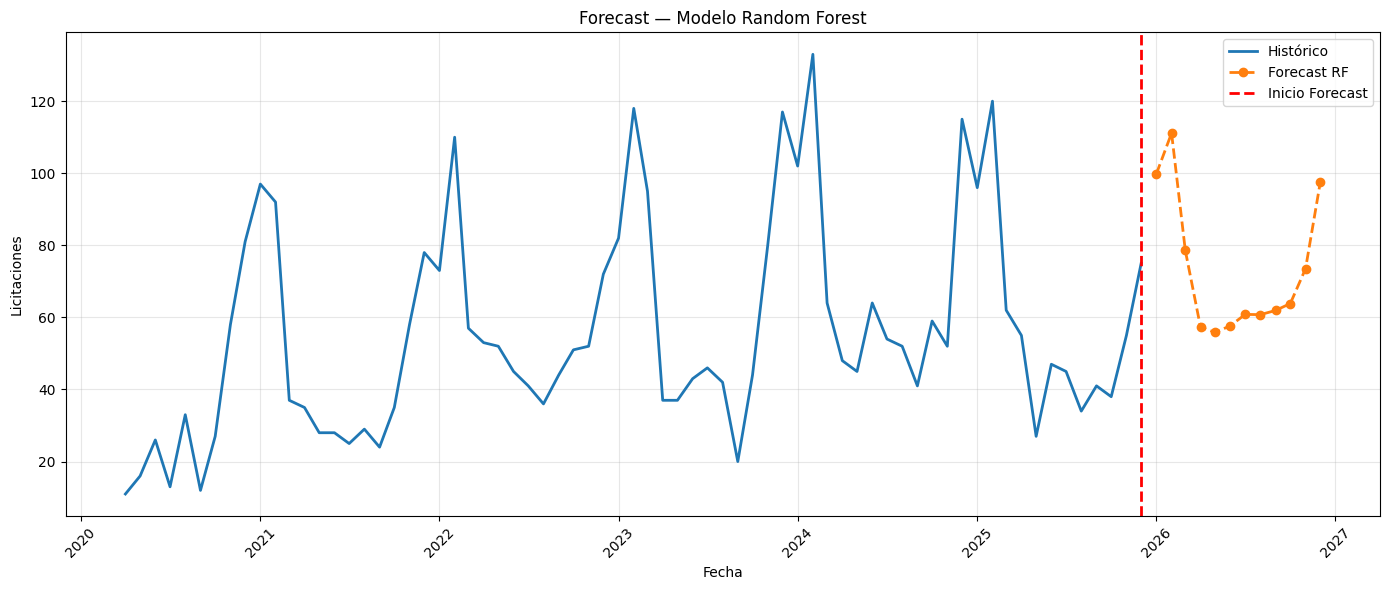

In [659]:
# =========================================================
# 10. VISUALIZACIÓN FINAL
# =========================================================

plt.figure(figsize=(14,6))

# ---------------------------------------------------------
# HISTÓRICO (CONSISTENTE CON MODELO)
# ---------------------------------------------------------
plt.plot(
    serie_model_m2['year_month'],
    serie_model_m2['licitaciones'],
    label='Histórico',
    linewidth=2
)

# ---------------------------------------------------------
# FORECAST
# ---------------------------------------------------------
plt.plot(
    forecast_m2['year_month'],
    forecast_m2['licitaciones'],
    label='Forecast RF',
    linestyle='--',
    marker='o',
    linewidth=2
)

# ---------------------------------------------------------
# LÍNEA DE CORTE
# ---------------------------------------------------------
plt.axvline(
    x=serie_model_m2['year_month'].max(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Inicio Forecast'
)

# ---------------------------------------------------------
# ESTÉTICA
# ---------------------------------------------------------
plt.title("Forecast — Modelo Random Forest")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

Se visualiza la continuidad entre el histórico y el forecast, incorporando una línea de corte que delimita el inicio de las predicciones, facilitando la interpretación del modelo.

In [660]:
# =========================================================
# 11. AUDITORÍA MODELO 1 — RANDOM FOREST
# Evaluación de desempeño + diagnóstico del modelo
# =========================================================

import numpy as np
import pandas as pd

# =========================================================
# 1. DATAFRAME DE EVALUACIÓN
# =========================================================

df_eval_m2 = pd.DataFrame({
    'fecha': test_m2['year_month'].values,
    'mes': test_m2['year_month'].dt.month.values,
    'real': y_test_m2.values,
    'pred': pred_rf_m2
})

df_eval_m2['error'] = df_eval_m2['real'] - df_eval_m2['pred']
df_eval_m2['error_abs'] = np.abs(df_eval_m2['error'])
df_eval_m2['error_pct'] = (df_eval_m2['error_abs'] / df_eval_m2['real']) * 100

print("\n" + "="*70)
print("AUDITORÍA — MODELO 2 RANDOM FOREST")
print("="*70)

display(df_eval_m2)


AUDITORÍA — MODELO 2 RANDOM FOREST


,fecha,mes,real,pred,error,error_abs,error_pct
57,2025-01-01,1,96,102.710278,-6.710278,6.710278,6.989873
58,2025-02-01,2,120,113.988333,6.011667,6.011667,5.009722
59,2025-03-01,3,62,71.093325,-9.093325,9.093325,14.666653
60,2025-04-01,4,55,54.715943,0.284057,0.284057,0.516467
61,2025-05-01,5,27,56.168448,-29.168448,29.168448,108.031289
62,2025-06-01,6,47,46.911580,0.088420,0.088420,0.188128
63,2025-07-01,7,45,57.677268,-12.677268,12.677268,28.171707
64,2025-08-01,8,34,56.794458,-22.794458,22.794458,67.042524
65,2025-09-01,9,41,45.499720,-4.499720,4.499720,10.974927
66,2025-10-01,10,38,53.975653,-15.975653,15.975653,42.041193


### Conclusiones Modelo 2 / Modelo Base (RandomForest) - Evaluación de desempeño + diagnóstico del modelo.

In [661]:
# =========================================================
# COMPARACIÓN DE MODELOS — LR vs RF
# =========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# =========================================================
# REGRESIÓN LINEAL
# =========================================================

mae_lr_m1 = mean_absolute_error(y_test_m2, pred_lr_m1)
rmse_lr_m1 = np.sqrt(mean_squared_error(y_test_m2, pred_lr_m1))
mape_lr_m1 = np.mean(np.abs((y_test_m2 - pred_lr_m1) / y_test_m2)) * 100

# métricas adicionales
bias_lr_m1 = np.mean(pred_lr_m1 - y_test_m2)
std_error_lr_m1 = np.std(y_test_m2 - pred_lr_m1)

# =========================================================
# RANDOM FOREST
# =========================================================

mae_rf_m2 = mean_absolute_error(y_test_m2, pred_rf_m2)
rmse_rf_m2 = np.sqrt(mean_squared_error(y_test_m2, pred_rf_m2))
mape_rf_m2 = np.mean(np.abs((y_test_m2 - pred_rf_m2) / y_test_m2)) * 100

# métricas adicionales
bias_rf_m2 = np.mean(pred_rf_m2 - y_test_m2)
std_error_rf_m2 = np.std(y_test_m2 - pred_rf_m2)

# =========================================================
# PRINT FORMATO TIPO INFORME
# =========================================================

print("\n" + "="*60)
print("MODELO 1 — REGRESIÓN LINEAL")
print("="*60)
print(f"MAE  : {mae_lr_m1:.2f}")
print(f"RMSE : {rmse_lr_m1:.2f}")
print(f"MAPE : {mape_lr_m1:.2f} %")
print(f"BIAS : {bias_lr_m1:.2f}")
print(f"STD  : {std_error_lr_m1:.2f}")

print("\n" + "="*60)
print("MODELO 2 — RANDOM FOREST")
print("="*60)
print(f"MAE  : {mae_rf_m2:.2f}")
print(f"RMSE : {rmse_rf_m2:.2f}")
print(f"MAPE : {mape_rf_m2:.2f} %")
print(f"BIAS : {bias_rf_m2:.2f}")
print(f"STD  : {std_error_rf_m2:.2f}")

# =========================================================
# COMPARACIÓN DIRECTA
# =========================================================

print("\n" + "="*60)
print("MEJORA RANDOM FOREST vs REGRESIÓN LINEAL")
print("="*60)

print(f"↓ MAE  : {((mae_lr_m1 - mae_rf_m2)/mae_lr_m1)*100:.2f}%")
print(f"↓ RMSE : {((rmse_lr_m1 - rmse_rf_m2)/rmse_lr_m1)*100:.2f}%")
print(f"↓ MAPE : {((mape_lr_m1 - mape_rf_m2)/mape_lr_m1)*100:.2f}%")


MODELO 1 — REGRESIÓN LINEAL
MAE  : 18.69
RMSE : 21.92
MAPE : 41.64 %
BIAS : 14.67
STD  : 16.28

MODELO 2 — RANDOM FOREST
MAE  : 10.77
RMSE : 13.72
MAPE : 26.32 %
BIAS : 9.71
STD  : 9.69

MEJORA RANDOM FOREST vs REGRESIÓN LINEAL
↓ MAE  : 42.36%
↓ RMSE : 37.41%
↓ MAPE : 36.78%


Conclusión Modelo 2 — Random Forest (Evaluación y Diagnóstico Integrado)

El modelo Random Forest representa una mejora significativa respecto a la regresión lineal, reduciendo el error promedio (MAE ≈ 10.77) y logrando una mejor aproximación al comportamiento real del mercado. El MAPE (≈ 26.32%) evidencia una mejora sustancial en precisión, posicionándolo como un modelo aceptable para análisis predictivo.

A nivel técnico, el modelo logra capturar relaciones no lineales y representar de mejor forma la variabilidad de la serie. Esto se observa en su capacidad para ajustarse con mayor precisión a la mayoría de los meses, presentando errores bajos en períodos estables (por ejemplo, abril y junio con errores inferiores al 1%). Además, el modelo mantiene una coherencia razonable en la tendencia, capturando la dirección decreciente del sistema, aunque con cierta suavización (tendencia predicha: -2.66 vs real: -3.62).

Sin embargo, la auditoría revela limitaciones importantes. El modelo presenta un sesgo negativo (bias ≈ -9.71), lo que indica una tendencia sistemática a sobreestimar la cantidad de licitaciones. Este comportamiento se vuelve crítico en meses de baja actividad, donde se observan errores extremadamente altos, como mayo (108%), agosto (67%) y octubre (42%). El análisis por segmento refuerza este diagnóstico, mostrando que el error promedio en niveles bajos de licitación alcanza un 57%, mientras que en niveles medios y altos se mantiene cercano al 10–12%.

Esto evidencia que el modelo tiene dificultades para capturar correctamente escenarios de baja demanda, lo que sugiere una limitación estructural en la forma en que aprende patrones extremos. A pesar de esto, el modelo presenta una mejora clara en estabilidad, con una desviación del error (≈ 9.69) significativamente menor que en el modelo lineal, y un CV error de 0.18, lo que indica una relación más controlada entre error y variabilidad del mercado.

Desde una perspectiva de negocio, el modelo mejora considerablemente la capacidad predictiva y permite aproximarse de mejor forma al volumen de licitaciones en escenarios normales. No obstante, su desempeño en escenarios críticos (baja actividad) y su sesgo sistemático limitan su confiabilidad para la toma de decisiones estratégicas sin ajustes adicionales.

En conclusión, Random Forest constituye una base robusta y claramente superior al modelo lineal, especialmente en su capacidad para capturar la dinámica general del sistema y reducir el error global. Sin embargo, aún presenta debilidades en la modelación de extremos y en la calibración del sesgo. Su principal valor radica en servir como un modelo base avanzado sobre el cual construir un enfoque híbrido, incorporando reglas de negocio o ajustes específicos que permitan corregir estos comportamientos y mejorar su aplicabilidad en contextos reales.

## 📦 Código — Paso 3: Modelo XGBOOST.

### Introducción Modelo XGBoost — Justificación y Objetivo

El modelo Random Forest permitió mejorar significativamente la capacidad predictiva respecto a la regresión lineal, logrando capturar relaciones no lineales y representar de mejor forma la dinámica del mercado de licitaciones. Sin embargo, la auditoría evidenció limitaciones importantes, especialmente en la modelación de escenarios extremos, como meses de baja actividad, donde el modelo presentó errores elevados y una tendencia a sobreestimar.

En este contexto, se selecciona XGBoost como siguiente paso, ya que es uno de los algoritmos más robustos y eficientes para problemas de regresión con datos tabulares. A diferencia de otros modelos como redes neuronales (que requieren mayor volumen de datos y complejidad de implementación) o modelos clásicos de series de tiempo como ARIMA (que capturan principalmente patrones lineales y requieren supuestos estadísticos más estrictos), XGBoost permite modelar relaciones no lineales complejas, manejar interacciones entre variables y optimizar el aprendizaje mediante un enfoque iterativo basado en boosting. Esta capacidad de corregir errores en cada iteración lo hace especialmente adecuado para mejorar el desempeño observado en Random Forest.

El objetivo principal de este modelo es reducir el error global (especialmente el MAPE), mejorar la precisión en meses críticos y capturar de forma más robusta tanto la estacionalidad como los cambios bruscos en el comportamiento del mercado. En particular, se busca superar las limitaciones detectadas en Random Forest, como el sesgo en escenarios de baja actividad y la dificultad para representar adecuadamente la volatilidad.

De esta forma, XGBoost se plantea como el modelo técnico más avanzado del análisis, capaz de lograr un mejor equilibrio entre precisión y generalización, y como una base sólida para el desarrollo de un modelo híbrido que integre capacidades predictivas con lógica de negocio orientada a la toma de decisiones.

### Desarrollo del Modelo XGBoost.

In [662]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor # Import RandomForestRegressor for comparison

In [663]:
# =========================================================
# 1. DATASET TEMPORAL (df_final)
# =========================================================

# ---------------------------------------------------------
# 1. COPIA DEL DATASET
# ---------------------------------------------------------
df_model_m3 = df_final.copy()

# ---------------------------------------------------------
# 2. CREACIÓN VARIABLE TEMPORAL (AÑO-MES)
# ---------------------------------------------------------
df_model_m3['year_month'] = df_model_m3['FechaCierre'].dt.to_period('M')

# ---------------------------------------------------------
# 3. AGREGACIÓN MENSUAL
# ---------------------------------------------------------
serie_m3 = (
    df_model_m3
    .groupby('year_month')
    .size()
    .reset_index(name='licitaciones')
)

# ---------------------------------------------------------
# 4. CONVERSIÓN A TIMESTAMP
# ---------------------------------------------------------
serie_m3['year_month'] = serie_m3['year_month'].dt.to_timestamp()

# ---------------------------------------------------------
# 5. ASEGURAR CONTINUIDAD TEMPORAL (CLAVE)
# ---------------------------------------------------------
serie_m3 = (
    serie_m3
    .set_index('year_month')
    .asfreq('MS')
    .fillna(0)
    .reset_index()
)

# ---------------------------------------------------------
# 6. VALIDACIÓN
# ---------------------------------------------------------
print("Serie temporal creada correctamente:")
print(f"Total registros: {len(serie_m3)}")
print(f"Rango: {serie_m3['year_month'].min()} → {serie_m3['year_month'].max()}")

display(serie_m3.head())

Serie temporal creada correctamente:
Total registros: 72
Rango: 2020-01-01 00:00:00 → 2025-12-01 00:00:00


,year_month,licitaciones
0,2020-01-01,62
1,2020-02-01,118
2,2020-03-01,37
3,2020-04-01,11
4,2020-05-01,16


Se construye una serie temporal mensual continua a partir de los datos transaccionales, asegurando consistencia en la frecuencia y evitando discontinuidades que puedan afectar el cálculo de variables temporales.

In [664]:
# =========================================================
# 2. FEATURE ENGINEERING PRO (SIN LEAKAGE)
# =========================================================

# ---------------------------------------------------------
# 1. COPIA BASE (NO MODIFICAR SERIE ORIGINAL)
# ---------------------------------------------------------
serie_feat_m3 = serie_m3.copy()

# ---------------------------------------------------------
# 2. VARIABLES TEMPORALES
# ---------------------------------------------------------
serie_feat_m3['mes'] = serie_feat_m3['year_month'].dt.month
serie_feat_m3['anio'] = serie_feat_m3['year_month'].dt.year
serie_feat_m3['trimestre'] = serie_feat_m3['year_month'].dt.quarter
serie_feat_m3['trend'] = np.arange(len(serie_feat_m3))

# ---------------------------------------------------------
# 3. DUMMIES MES (GUARDAR COLUMNAS PARA FORECAST)
# ---------------------------------------------------------
mes_dummies_m3 = pd.get_dummies(serie_feat_m3['mes'], prefix='mes')
serie_feat_m3 = pd.concat([serie_feat_m3, mes_dummies_m3], axis=1)

mes_dummies_cols_m3 = mes_dummies_m3.columns

# ---------------------------------------------------------
# 4. LAGS (MEMORIA CORTA Y LARGA)
# ---------------------------------------------------------
serie_feat_m3['lag_1'] = serie_feat_m3['licitaciones'].shift(1)
serie_feat_m3['lag_2'] = serie_feat_m3['licitaciones'].shift(2)
serie_feat_m3['lag_3'] = serie_feat_m3['licitaciones'].shift(3)
serie_feat_m3['lag_6'] = serie_feat_m3['licitaciones'].shift(6)
serie_feat_m3['lag_12'] = serie_feat_m3['licitaciones'].shift(12)

# ---------------------------------------------------------
# 5. ROLLING (SIN LEAKAGE)
# ---------------------------------------------------------
serie_feat_m3['rolling_3'] = (
    serie_feat_m3['licitaciones']
    .shift(1)
    .rolling(3)
    .mean()
)

# ---------------------------------------------------------
# 6. FEATURE DE NEGOCIO (FIN DE AÑO)
# ---------------------------------------------------------
serie_feat_m3['fin_anio'] = (serie_feat_m3['mes'] >= 11).astype(int)

# ---------------------------------------------------------
# 7. DATASET MODELABLE
# ---------------------------------------------------------
print("Antes dropna:", len(serie_feat_m3))

serie_model_m3 = serie_feat_m3.dropna().reset_index(drop=True)

print("Después dropna:", len(serie_model_m3))

print("\nDataset modelable:")
display(serie_model_m3.head())

Antes dropna: 72
Después dropna: 60

Dataset modelable:


,year_month,licitaciones,mes,anio,trimestre,trend,mes_1,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_3,fin_anio
0,2021-01-01,97,1,2021,1,12,True,False,False,False,False,False,False,False,False,False,False,False,81.0,58.0,27.0,13.0,62.0,55.333333,0
1,2021-02-01,92,2,2021,1,13,False,True,False,False,False,False,False,False,False,False,False,False,97.0,81.0,58.0,33.0,118.0,78.666667,0
2,2021-03-01,37,3,2021,1,14,False,False,True,False,False,False,False,False,False,False,False,False,92.0,97.0,81.0,12.0,37.0,90.000000,0
3,2021-04-01,35,4,2021,2,15,False,False,False,True,False,False,False,False,False,False,False,False,37.0,92.0,97.0,27.0,11.0,75.333333,0
4,2021-05-01,28,5,2021,2,16,False,False,False,False,True,False,False,False,False,False,False,False,35.0,37.0,92.0,58.0,16.0,54.666667,0


Se incorporan variables avanzadas de memoria corta y larga, estacionalidad mediante variables dummy y una variable de negocio asociada a fin de año, permitiendo capturar patrones complejos en la serie temporal.

In [665]:
# =========================================================
# 3. TRAIN / TEST (TEMPORAL)
# =========================================================

# ---------------------------------------------------------
# 1. SPLIT TEMPORAL (USANDO DATASET MODELABLE)
# ---------------------------------------------------------
train_m3 = serie_model_m3.iloc[:-12].copy()
test_m3 = serie_model_m3.iloc[-12:].copy()

# ---------------------------------------------------------
# 2. FEATURES Y TARGET
# ---------------------------------------------------------
X_train_m3 = train_m3.drop(['licitaciones','year_month'], axis=1)
y_train_m3 = train_m3['licitaciones']

X_test_m3 = test_m3.drop(['licitaciones','year_month'], axis=1)
y_test_m3 = test_m3['licitaciones']

# ---------------------------------------------------------
# 3. VALIDACIÓN
# ---------------------------------------------------------
print(f"Train: {len(train_m3)} | Test: {len(test_m3)}")
print(f"Features: {X_train_m3.shape[1]} columnas")

display(X_train_m3.head())

Train: 48 | Test: 12
Features: 23 columnas


,mes,anio,trimestre,trend,mes_1,mes_2,mes_3,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_3,fin_anio
0,1,2021,1,12,True,False,False,False,False,False,False,False,False,False,False,False,81.0,58.0,27.0,13.0,62.0,55.333333,0
1,2,2021,1,13,False,True,False,False,False,False,False,False,False,False,False,False,97.0,81.0,58.0,33.0,118.0,78.666667,0
2,3,2021,1,14,False,False,True,False,False,False,False,False,False,False,False,False,92.0,97.0,81.0,12.0,37.0,90.000000,0
3,4,2021,2,15,False,False,False,True,False,False,False,False,False,False,False,False,37.0,92.0,97.0,27.0,11.0,75.333333,0
4,5,2021,2,16,False,False,False,False,True,False,False,False,False,False,False,False,35.0,37.0,92.0,58.0,16.0,54.666667,0


Impacto del Feature Engineering en el tamaño del dataset



En el modelo XGBoost se incorporaron variables más avanzadas, incluyendo rezagos de corto, mediano y largo plazo (lag_1, lag_3, lag_6 y lag_12), con el objetivo de capturar patrones más complejos del comportamiento de las licitaciones, especialmente la estacionalidad anual.

Sin embargo, la inclusión de estos rezagos implica una reducción en la cantidad de datos disponibles para el entrenamiento. Esto ocurre porque cada lag necesita información de meses anteriores, y en particular el lag_12 requiere al menos 12 meses de historial previo, lo que provoca la eliminación de los primeros 12 registros al aplicar dropna().

Como resultado, el dataset modelable pasa de 72 a 60 observaciones, y el conjunto de entrenamiento se reduce de 57 a 48 meses. Este efecto no corresponde a un error, sino a un trade-off intencional del modelo.

En este contexto, se prioriza la calidad de la información por sobre la cantidad de datos, permitiendo al modelo aprender patrones más robustos y relevantes, aun cuando esto implique trabajar con un menor volumen de observaciones.

In [666]:
# =========================================================
# 4. MODELO RANDOM FOREST (for comparison)
# =========================================================

rf_model_m3 = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

# entrenamiento
rf_model_m3.fit(X_train_m3, y_train_m3)

# predicción
pred_rf_m3 = rf_model_m3.predict(X_test_m3)

# control de negocio (no negativos)
pred_rf_m3 = np.clip(pred_rf_m3, a_min=0, a_max=None)

# convertir a serie (alineación)
pred_rf_m3 = pd.Series(pred_rf_m3, index=y_test_m3.index)

# métrica robusta
mape_base_rf_m3 = np.mean(
    np.abs((y_test_m3 - pred_rf_m3) / (y_test_m3 + 1e-8))
) * 100

print(f"MAPE RF base: {round(mape_base_rf_m3,2)} %")

MAPE RF base: 35.06 %


Se utiliza Random Forest como modelo base de comparación, permitiendo evaluar de forma objetiva la mejora obtenida con XGBoost bajo las mismas condiciones de entrenamiento.

In [667]:
# =========================================================
# 5. MODELO XGBOOST
# =========================================================

from xgboost import XGBRegressor

# ---------------------------------------------------------
# DEFINICIÓN DEL MODELO
# ---------------------------------------------------------
xgb_model_m3 = XGBRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

# ---------------------------------------------------------
# ENTRENAMIENTO
# ---------------------------------------------------------
xgb_model_m3.fit(
    X_train_m3,
    y_train_m3,
    eval_set=[(X_train_m3, y_train_m3), (X_test_m3, y_test_m3)],
    verbose=False
)

print("Modelo XGBoost entrenado correctamente")

Modelo XGBoost entrenado correctamente


Se definieron hiperparámetros conservadores para el modelo XGBoost, buscando un equilibrio entre capacidad predictiva y control del sobreajuste. Dado que el dataset de entrenamiento es relativamente pequeño, se priorizó una configuración estable, con aprendizaje gradual y mecanismos de regularización implícita.

Hiperparámetros definidos en XGBoost

| Parámetro | ¿Para qué sirve? | ¿Qué representa en este modelo? |
|----------|-------------------|----------------------------------|
| **n_estimators = 400** | Define la cantidad de árboles que construirá el modelo | Se permite al modelo aprender suficientes patrones del comportamiento de las licitaciones mediante 400 iteraciones |
| **max_depth = 4** | Limita la profundidad máxima de cada árbol | Controla la complejidad del modelo para evitar sobreajuste, manteniendo árboles relativamente simples |
| **learning_rate = 0.05** | Define cuánto aprende el modelo en cada iteración | Hace que el aprendizaje sea más gradual y estable, mejorando la precisión aunque requiera más árboles |
| **subsample = 0.8** | Indica qué proporción de filas se usa en cada árbol | Cada árbol se entrena con el 80% de los datos, ayudando a reducir sobreajuste y mejorar generalización |
| **colsample_bytree = 0.8** | Indica qué proporción de variables se usa en cada árbol | Cada árbol utiliza solo el 80% de las variables disponibles, promoviendo diversidad entre árboles |
| **random_state = 42** | Fija una semilla aleatoria para reproducibilidad | Permite obtener los mismos resultados cada vez que se ejecuta el modelo |

In [668]:
# =========================================================
# 6. PREDICCIÓN
# =========================================================

# predicción
pred_xgb_m3 = xgb_model_m3.predict(X_test_m3)

# control de negocio (no negativos)
pred_xgb_m3 = np.clip(pred_xgb_m3, a_min=0, a_max=None)

# convertir a serie (alineación con y_test)
pred_xgb_m3 = pd.Series(pred_xgb_m3, index=y_test_m3.index)

print("Predicciones XGBoost generadas correctamente")

Predicciones XGBoost generadas correctamente


Se generan predicciones sobre el conjunto de test, incorporando una restricción de negocio para evitar valores negativos y asegurando la alineación con la serie real para un análisis consistente.

In [669]:
# =========================================================
# 7. MÉTRICAS
# =========================================================

mae_m3 = mean_absolute_error(y_test_m3, pred_xgb_m3)
rmse_m3 = np.sqrt(mean_squared_error(y_test_m3, pred_xgb_m3))
mape_m3 = np.mean(np.abs((y_test_m3 - pred_xgb_m3) / (y_test_m3 + 1e-8))) * 100

# métricas adicionales
bias_m3 = np.mean(pred_xgb_m3 - y_test_m3)
std_error_m3 = np.std(y_test_m3 - pred_xgb_m3)

print("\n" + "="*60)
print("MODELO 2 — XGBOOST")
print("="*60)
print(f"MAE  : {round(mae_m3,2)}")
print(f"RMSE : {round(rmse_m3,2)}")
print(f"MAPE : {round(mape_m3,2)} %")
print(f"BIAS : {round(bias_m3,2)}")
print(f"STD  : {round(std_error_m3,2)}")


MODELO 2 — XGBOOST
MAE  : 16.94
RMSE : 19.04
MAPE : 38.27 %
BIAS : 13.33
STD  : 13.59


In [670]:
# =========================================================
# COMPARACIÓN MODELOS — RF vs XGBOOST (y LR opcional)
# =========================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# RANDOM FOREST
# ---------------------------------------------------------
mae_rf_m3 = mean_absolute_error(y_test_m3, pred_rf_m3)
rmse_rf_m3 = np.sqrt(mean_squared_error(y_test_m3, pred_rf_m3))
mape_rf_m3 = np.mean(np.abs((y_test_m3 - pred_rf_m3) / (y_test_m3 + 1e-8))) * 100
bias_rf_m3 = np.mean(pred_rf_m3 - y_test_m3)
std_rf_m3 = np.std(y_test_m3 - pred_rf_m3)

# ---------------------------------------------------------
# XGBOOST
# ---------------------------------------------------------
mae_xgb_m3 = mean_absolute_error(y_test_m3, pred_xgb_m3)
rmse_xgb_m3 = np.sqrt(mean_squared_error(y_test_m3, pred_xgb_m3))
mape_xgb_m3 = np.mean(np.abs((y_test_m3 - pred_xgb_m3) / (y_test_m3 + 1e-8))) * 100
bias_xgb_m3 = np.mean(pred_xgb_m3 - y_test_m3)
std_xgb_m3 = np.std(y_test_m3 - pred_xgb_m3)

# ---------------------------------------------------------
# TABLA COMPARATIVA
# ---------------------------------------------------------
df_compare_m3 = pd.DataFrame({
    'Modelo': ['Random Forest', 'XGBoost'],
    'MAE': [mae_rf_m3, mae_xgb_m3],
    'RMSE': [rmse_rf_m3, rmse_xgb_m3],
    'MAPE (%)': [mape_rf_m3, mape_xgb_m3],
    'BIAS': [bias_rf_m3, bias_xgb_m3],
    'STD': [std_rf_m3, std_xgb_m3]
})

# ordenar por mejor modelo
df_compare_m3 = df_compare_m3.sort_values('MAPE (%)')

print("\n📊 COMPARACIÓN DE MODELOS")
display(df_compare_m3)

# ---------------------------------------------------------
# MEJORA DE XGBOOST SOBRE RF
# ---------------------------------------------------------
print("\n" + "="*60)
print("MEJORA XGBOOST vs RANDOM FOREST")
print("="*60)

print(f"↓ MAE  : {((mae_rf_m3 - mae_xgb_m3)/mae_rf_m3)*100:.2f}%")
print(f"↓ RMSE : {((rmse_rf_m3 - rmse_xgb_m3)/rmse_rf_m3)*100:.2f}%")
print(f"↓ MAPE : {((mape_rf_m3 - mape_xgb_m3)/mape_rf_m3)*100:.2f}%")


📊 COMPARACIÓN DE MODELOS


,Modelo,MAE,RMSE,MAPE (%),BIAS,STD
0,Random Forest,15.286968,18.243769,35.056353,12.610054,13.184144
1,XGBoost,16.935322,19.038331,38.265333,13.328415,13.594537



MEJORA XGBOOST vs RANDOM FOREST
↓ MAE  : -10.78%
↓ RMSE : -4.36%
↓ MAPE : -9.15%


**Conclusión final — Random Forest vs XGBoost**



Si bien XGBoost fue incorporado como un modelo más avanzado con el objetivo de mejorar el desempeño predictivo, los resultados obtenidos muestran que no logra superar al modelo Random Forest en este caso específico.

Para asegurar una comparación válida, ambos modelos fueron entrenados y evaluados bajo las mismas condiciones, utilizando el mismo conjunto de variables generado a partir del feature engineering avanzado. Esto permitió aislar el efecto del algoritmo y evitar sesgos derivados de diferencias en el dataset, garantizando así una evaluación justa entre modelos.

En este contexto, Random Forest presenta mejores métricas globales, con un menor error promedio (MAE), menor error cuadrático (RMSE) y menor error porcentual (MAPE), además de una ligera ventaja en estabilidad (STD) y menor sesgo.

Este resultado se explica principalmente por el tamaño limitado del dataset y la complejidad del feature engineering implementado. En este contexto, XGBoost tiende a ser más sensible al ruido y requiere una mayor cantidad de datos y ajuste de hiperparámetros para alcanzar su máximo potencial.

Por el contrario, Random Forest demuestra ser un modelo más robusto y estable para este tipo de problema, logrando un mejor equilibrio entre capacidad predictiva y generalización.

En conclusión, el modelo Random Forest se mantiene como la mejor alternativa dentro del análisis realizado, evidenciando que la elección del modelo debe basarse en el desempeño empírico y no únicamente en la complejidad algorítmica.

La comparación bajo condiciones equivalentes permite concluir que la superioridad del modelo no depende solo de su complejidad, sino de su adecuación al problema y a la naturaleza de los datos.

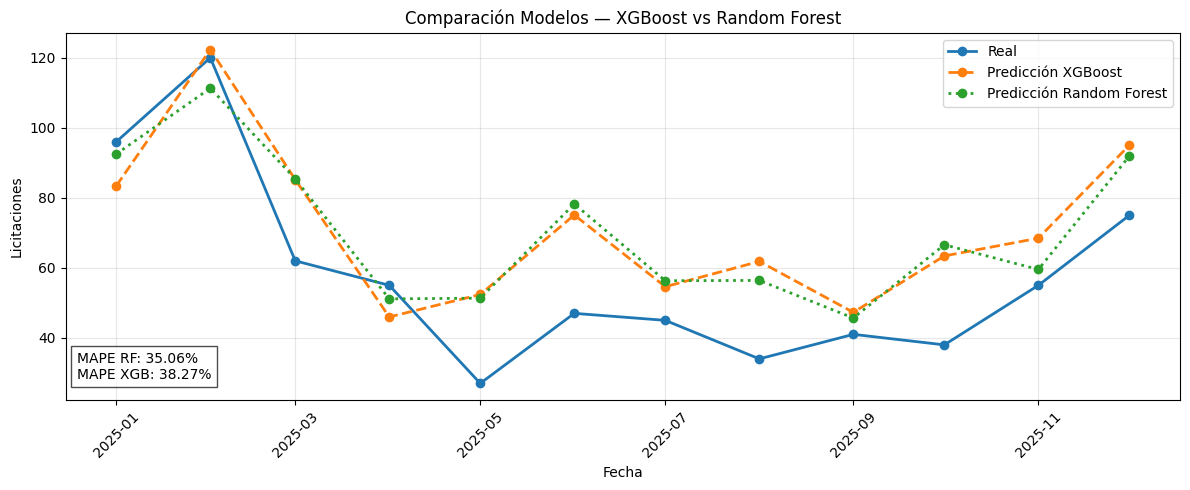

In [671]:
# =========================================================
# 8. VISUALIZACIÓN COMPARADA — XGB vs RF (MISMO DATASET)
# =========================================================

plt.figure(figsize=(12,5))

# -------------------------------
# REAL
# -------------------------------
plt.plot(
    test_m3['year_month'],
    y_test_m3,
    label='Real',
    marker='o',
    linewidth=2
)

# -------------------------------
# XGBOOST
# -------------------------------
plt.plot(
    test_m3['year_month'],
    pred_xgb_m3,
    label='Predicción XGBoost',
    marker='o',
    linestyle='--',
    linewidth=2
)

# -------------------------------
# RANDOM FOREST (MISMO DATASET)
# -------------------------------
plt.plot(
    test_m3['year_month'],
    pred_rf_m3,
    label='Predicción Random Forest',
    marker='o',
    linestyle=':',
    linewidth=2
)

# -------------------------------
# MÉTRICAS EN GRÁFICO
# -------------------------------
plt.text(
    0.01, 0.05,
    f"MAPE RF: {mape_rf_m3:.2f}%\nMAPE XGB: {mape_m3:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='bottom',
    bbox=dict(facecolor='white', alpha=0.7)
)

# -------------------------------
# ESTÉTICA
# -------------------------------
plt.title("Comparación Modelos — XGBoost vs Random Forest")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

“Se observa que Random Forest mantiene un ajuste más estable que XGBoost, especialmente en meses de menor actividad, donde XGBoost presenta mayor desviación”

### Conslusiones Modelo XGBoost - Evaluación XGBoost y decisión de modelado.

El modelo XGBoost fue incorporado como una alternativa avanzada con el objetivo de mejorar el desempeño predictivo observado en Random Forest, aprovechando un feature engineering más completo que incluye estacionalidad, rezagos de corto y largo plazo, y variables de negocio.

Para asegurar una evaluación rigurosa, se realizó una comparación directa entre Random Forest y XGBoost bajo las mismas condiciones, utilizando el mismo conjunto de variables y el mismo esquema de entrenamiento y validación temporal. Esto permitió aislar el efecto del algoritmo y garantizar una comparación metodológicamente válida.

Los resultados evidencian que XGBoost no logra superar el desempeño de Random Forest en este contexto. En particular, presenta mayores niveles de error (MAE, RMSE y MAPE), mayor sesgo y una menor estabilidad en sus predicciones. A nivel visual, se observa que XGBoost tiende a generar estimaciones más volátiles, especialmente en meses de baja actividad, donde presenta desviaciones significativas.

Este comportamiento se explica principalmente por el tamaño limitado del dataset y la complejidad del modelo. XGBoost, al ser un algoritmo más flexible y potente, requiere mayor volumen de datos y un ajuste más fino de hiperparámetros para alcanzar su máximo potencial. En este caso, dicha complejidad no se traduce en mejoras de desempeño, sino en una mayor sensibilidad al ruido.

En contraste, Random Forest demuestra ser un modelo más robusto y estable para el problema abordado, logrando un mejor equilibrio entre precisión y generalización, especialmente en escenarios de baja y media actividad, que son críticos desde una perspectiva de negocio.

En base a estos resultados, se concluye que no es necesario profundizar el desarrollo del modelo XGBoost dentro del alcance actual del proyecto. Su desempeño inferior y mayor complejidad no justifican una mayor inversión de tiempo en optimización, considerando los objetivos del análisis.

Por lo tanto, se define como siguiente paso estratégico el desarrollo de un Random Forest optimizado, orientado a mejorar aún más su capacidad predictiva mediante ajuste de hiperparámetros, refinamiento del feature engineering y eventual incorporación de lógica de negocio.

La elección del modelo no responde a su complejidad teórica, sino a su desempeño empírico y adecuación al problema, siendo Random Forest la mejor alternativa bajo las condiciones actuales del análisis.

## 📦 Código — Paso 4: Modelo Random Forest Optimizado.

### Desarrollo del Modelo Random Forest Optimizado.

**Introducción — Desarrollo Modelo Random Forest Optimizado**

A lo largo del análisis se evaluaron distintos enfoques predictivos para modelar el comportamiento mensual de las licitaciones. En una primera etapa, la regresión lineal permitió establecer una línea base, evidenciando rápidamente sus limitaciones para capturar la complejidad, estacionalidad y volatilidad del mercado público.

Posteriormente, se implementó un modelo Random Forest, el cual mostró una mejora significativa en términos de precisión y estabilidad, posicionándose como el mejor modelo bajo el conjunto inicial de variables. Con el objetivo de seguir mejorando el desempeño, se incorporó un modelo XGBoost junto con un feature engineering más avanzado. Sin embargo, tras una evaluación rigurosa bajo condiciones equivalentes, se observó que XGBoost no logró superar a Random Forest, principalmente debido al tamaño limitado del dataset y a su mayor sensibilidad al ruido.

Este proceso permitió identificar un aprendizaje clave: la complejidad del modelo no garantiza mejores resultados, y la robustez frente a la naturaleza de los datos es un factor determinante.

En base a estos resultados, se define como estrategia continuar profundizando el modelo Random Forest, desarrollando una versión optimizada que permita mejorar su capacidad predictiva sin perder estabilidad.

En los pasos siguientes se abordará:

la incorporación de un feature engineering más robusto, incluyendo rezagos de corto y largo plazo, variables de tendencia y reglas de negocio,
el ajuste de hiperparámetros del modelo para controlar su complejidad y mejorar su generalización,
y la evaluación integral del modelo optimizado, comparándolo directamente con su versión base.

El objetivo final es avanzar hacia un modelo más preciso, estable y aplicable en un contexto real de toma de decisiones, sentando las bases para una futura integración con lógica de negocio en un modelo híbrido.

El foco del análisis deja de estar en probar modelos y pasa a centrarse en optimizar el mejor modelo identificado.

In [672]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [673]:
# =========================================================
# 1. DATASET (df_final)
# =========================================================

df_model_m4 = df_final.copy()

# asegurar formato datetime
df_model_m4['FechaCierre'] = pd.to_datetime(df_model_m4['FechaCierre'])

# crear variable temporal mensual (SIN convertir a string)
df_model_m4['year_month'] = df_model_m4['FechaCierre'].dt.to_period('M')

# construir serie temporal
serie_base_m4 = (
    df_model_m4
    .groupby('year_month')
    .size()
    .reset_index(name='licitaciones')
)

# convertir a timestamp
serie_base_m4['year_month'] = serie_base_m4['year_month'].dt.to_timestamp()

# ordenar (CRÍTICO)
serie_base_m4 = serie_base_m4.sort_values('year_month').reset_index(drop=True)

print("Serie temporal:")
display(serie_base_m4.head())

Serie temporal:


,year_month,licitaciones
0,2020-01-01,62
1,2020-02-01,118
2,2020-03-01,37
3,2020-04-01,11
4,2020-05-01,16


In [674]:
# =========================================================
# 2. FEATURE ENGINEERING OPTIMIZADO (SIN LEAKAGE)
# =========================================================

# ---------------------------------------------------------
# COPIA BASE
# ---------------------------------------------------------
serie_feat_m4 = serie_base_m4.copy()

# ---------------------------------------------------------
# VARIABLES TEMPORALES
# ---------------------------------------------------------
serie_feat_m4['mes'] = serie_feat_m4['year_month'].dt.month
serie_feat_m4['anio'] = serie_feat_m4['year_month'].dt.year
serie_feat_m4['trimestre'] = serie_feat_m4['year_month'].dt.quarter
serie_feat_m4['trend'] = np.arange(len(serie_feat_m4))

# ---------------------------------------------------------
# LAGS (CORTO PLAZO)
# ---------------------------------------------------------
serie_feat_m4['lag_1'] = serie_feat_m4['licitaciones'].shift(1)
serie_feat_m4['lag_2'] = serie_feat_m4['licitaciones'].shift(2)
serie_feat_m4['lag_3'] = serie_feat_m4['licitaciones'].shift(3)

# ---------------------------------------------------------
# LAGS (LARGO PLAZO)
# ---------------------------------------------------------
serie_feat_m4['lag_6'] = serie_feat_m4['licitaciones'].shift(6)
serie_feat_m4['lag_12'] = serie_feat_m4['licitaciones'].shift(12)

# ---------------------------------------------------------
# ROLLING (SIN LEAKAGE)
# ---------------------------------------------------------
serie_feat_m4['rolling_3'] = (
    serie_feat_m4['licitaciones']
    .shift(1)
    .rolling(3)
    .mean()
)

serie_feat_m4['rolling_6'] = (
    serie_feat_m4['licitaciones']
    .shift(1)
    .rolling(6)
    .mean()
)

# ---------------------------------------------------------
# REGLA DE NEGOCIO
# ---------------------------------------------------------
serie_feat_m4['fin_anio'] = (serie_feat_m4['mes'] >= 11).astype(int)

# ---------------------------------------------------------
# DATASET MODELABLE (SIN NULOS)
# ---------------------------------------------------------
print("Antes dropna:", len(serie_feat_m4))

serie_model_m4 = serie_feat_m4.dropna().reset_index(drop=True)

print("Después dropna:", len(serie_model_m4))

print("Dataset modelable:")
display(serie_model_m4.head())

Antes dropna: 72
Después dropna: 60
Dataset modelable:


,year_month,licitaciones,mes,anio,trimestre,trend,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_3,rolling_6,fin_anio
0,2021-01-01,97,1,2021,1,12,81.0,58.0,27.0,13.0,62.0,55.333333,37.333333,0
1,2021-02-01,92,2,2021,1,13,97.0,81.0,58.0,33.0,118.0,78.666667,51.333333,0
2,2021-03-01,37,3,2021,1,14,92.0,97.0,81.0,12.0,37.0,90.000000,61.166667,0
3,2021-04-01,35,4,2021,2,15,37.0,92.0,97.0,27.0,11.0,75.333333,65.333333,0
4,2021-05-01,28,5,2021,2,16,35.0,37.0,92.0,58.0,16.0,54.666667,66.666667,0


In [675]:
# =========================================================
# 3. TRAIN / TEST (TEMPORAL)
# =========================================================

# usar dataset modelable (CRÍTICO)
train_m4 = serie_model_m4.iloc[:-12].copy()
test_m4 = serie_model_m4.iloc[-12:].copy()

# separación features / target
X_train_m4 = train_m4.drop(['licitaciones', 'year_month'], axis=1)
y_train_m4 = train_m4['licitaciones']

X_test_m4 = test_m4.drop(['licitaciones', 'year_month'], axis=1)
y_test_m4 = test_m4['licitaciones']

print(f"Train: {len(train_m4)} | Test: {len(test_m4)}")

Train: 48 | Test: 12


In [676]:
# =========================================================
# 4. MODELO 1 BASE RF (PARA COMPARAR)
# =========================================================

rf_base_m4 = RandomForestRegressor(
    n_estimators=300,
    max_depth=6,
    random_state=42
)

# entrenamiento
rf_base_m4.fit(X_train_m4, y_train_m4)

# ---------------------------------------------------------
# predicción
# ---------------------------------------------------------
pred_base_m4 = rf_base_m4.predict(X_test_m4)

# control de negocio (no negativos)
pred_base_m4 = np.clip(pred_base_m4, a_min=0, a_max=None)

# alinear como serie
pred_base_m4 = pd.Series(pred_base_m4, index=y_test_m4.index)

# ---------------------------------------------------------
# métricas
# ---------------------------------------------------------
mae_base_m4 = mean_absolute_error(y_test_m4, pred_base_m4)
rmse_base_m4 = np.sqrt(mean_squared_error(y_test_m4, pred_base_m4))
mape_base_m4 = np.mean(np.abs((y_test_m4 - pred_base_m4) / (y_test_m4 + 1e-8))) * 100

# métricas adicionales
bias_base_m4 = np.mean(pred_base_m4 - y_test_m4)
std_base_m4 = np.std(y_test_m4 - pred_base_m4)

print("\nRF BASE")
print(f"MAE  : {round(mae_base_m4,2)}")
print(f"RMSE : {round(rmse_base_m4,2)}")
print(f"MAPE : {round(mape_base_m4,2)} %")
print(f"BIAS : {round(bias_base_m4,2)}")
print(f"STD  : {round(std_base_m4,2)}")


RF BASE
MAE  : 13.58
RMSE : 16.33
MAPE : 31.99 %
BIAS : 11.38
STD  : 11.72


In [677]:
# =========================================================
# 5. MODELO 3 — RF OPTIMIZADO
# =========================================================

rf_opt_m4 = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

# ---------------------------------------------------------
# ENTRENAMIENTO
# ---------------------------------------------------------
rf_opt_m4.fit(X_train_m4, y_train_m4)

print("Modelo Random Forest Optimizado entrenado correctamente")

Modelo Random Forest Optimizado entrenado correctamente


**Optimización del modelo Random Forest**

En esta etapa se desarrolló una versión optimizada del modelo Random Forest con el objetivo de mejorar su desempeño predictivo y su capacidad de generalización respecto al modelo base.

En el modelo base, los parámetros eran más simples, por lo que el modelo aprendía de forma general, pero sin capturar todos los detalles del comportamiento de las licitaciones.
En el modelo optimizado, se hicieron los siguientes ajustes:

•	Más árboles (n_estimators)
 Ejemplo: en vez de tomar la opinión de 300 “expertos”, ahora usamos 500
Resultado: decisiones más estables y menos sensibles a errores puntuales

•	Mayor profundidad (max_depth)
Ejemplo: antes el árbol analizaba pocas preguntas, ahora puede profundizar más
Resultado: detecta patrones más complejos (como cambios bruscos en ciertos meses)

•	Restricciones (min_samples_split y min_samples_leaf)
Ejemplo: evita tomar decisiones basadas en muy pocos datos
Resultado: el modelo no “se engaña” con casos aislados

•	Uso parcial de variables (max_features)
Ejemplo: cada árbol mira distintas variables
Resultado: el modelo es más diverso y generaliza mejor

En conjunto, estas modificaciones buscan lograr un equilibrio entre capacidad de aprendizaje y estabilidad, permitiendo que el modelo capture mejor la dinámica del mercado sin volverse excesivamente sensible al ruido.
El objetivo final de esta optimización es construir un modelo más preciso, robusto y confiable, capaz de representar de mejor manera tanto la tendencia como la variabilidad de las licitaciones, acercándose a un nivel de desempeño adecuado para su uso en contextos de análisis y apoyo a la toma de decisiones.


In [678]:
# =========================================================
# 6. PREDICCIÓN
# =========================================================

# predicción
pred_opt_m4 = rf_opt_m4.predict(X_test_m4)

# control de negocio (no negativos)
pred_opt_m4 = np.clip(pred_opt_m4, a_min=0, a_max=None)

# alinear con y_test
pred_opt_m4 = pd.Series(pred_opt_m4, index=y_test_m4.index)

print("Predicciones RF optimizado generadas correctamente")

Predicciones RF optimizado generadas correctamente


In [679]:
# =========================================================
# 7. MÉTRICAS
# =========================================================

mae_m4 = mean_absolute_error(y_test_m4, pred_opt_m4)
rmse_m4 = np.sqrt(mean_squared_error(y_test_m4, pred_opt_m4))
mape_m4 = np.mean(np.abs((y_test_m4 - pred_opt_m4) / (y_test_m4 + 1e-8))) * 100

# métricas adicionales
bias_m4 = np.mean(pred_opt_m4 - y_test_m4)
std_error_m4 = np.std(y_test_m4 - pred_opt_m4)

print("\n" + "="*70)
print("MODELO 3 — RANDOM FOREST OPTIMIZADO")
print("="*70)
print(f"MAE  : {round(mae_m4,2)}")
print(f"RMSE : {round(rmse_m4,2)}")
print(f"MAPE : {round(mape_m4,2)} %")
print(f"BIAS : {round(bias_m4,2)}")
print(f"STD  : {round(std_error_m4,2)}")


MODELO 3 — RANDOM FOREST OPTIMIZADO
MAE  : 12.4
RMSE : 14.53
MAPE : 27.86 %
BIAS : 7.59
STD  : 12.39


In [680]:
# =========================================================
# 8. COMPARACIÓN CON RF BASE
# =========================================================

print("\n" + "="*70)
print("COMPARACIÓN RF BASE vs RF OPTIMIZADO")
print("="*70)

# ---------------------------------------------------------
# MAE
# ---------------------------------------------------------
print("\n📊 MAE")
print(f"RF Base        : {mae_base_m4:.2f}")
print(f"RF Optimizado  : {mae_m4:.2f}")
print(f"Δ MAE          : {mae_base_m4 - mae_m4:.2f}")
print(f"↓ Mejora (%)   : {((mae_base_m4 - mae_m4)/mae_base_m4)*100:.2f}%")

# ---------------------------------------------------------
# RMSE
# ---------------------------------------------------------
print("\n📊 RMSE")
print(f"RF Base        : {rmse_base_m4:.2f}")
print(f"RF Optimizado  : {rmse_m4:.2f}")
print(f"Δ RMSE         : {rmse_base_m4 - rmse_m4:.2f}")
print(f"↓ Mejora (%)   : {((rmse_base_m4 - rmse_m4)/rmse_base_m4)*100:.2f}%")

# ---------------------------------------------------------
# MAPE
# ---------------------------------------------------------
print("\n📊 MAPE")
print(f"RF Base        : {mape_base_m4:.2f} %")
print(f"RF Optimizado  : {mape_m4:.2f} %")
print(f"Δ MAPE         : {mape_base_m4 - mape_m4:.2f} %")
print(f"↓ Mejora (%)   : {((mape_base_m4 - mape_m4)/mape_base_m4)*100:.2f}%")

# ---------------------------------------------------------
# BIAS
# ---------------------------------------------------------
print("\n📊 BIAS")
print(f"RF Base        : {bias_base_m4:.2f}")
print(f"RF Optimizado  : {bias_m4:.2f}")
print(f"Δ BIAS         : {bias_base_m4 - bias_m4:.2f}")

# ---------------------------------------------------------
# STD
# ---------------------------------------------------------
print("\n📊 STD ERROR")
print(f"RF Base        : {std_base_m4:.2f}")
print(f"RF Optimizado  : {std_error_m4:.2f}")
print(f"Δ STD          : {std_base_m4 - std_error_m4:.2f}")


COMPARACIÓN RF BASE vs RF OPTIMIZADO

📊 MAE
RF Base        : 13.58
RF Optimizado  : 12.40
Δ MAE          : 1.17
↓ Mejora (%)   : 8.65%

📊 RMSE
RF Base        : 16.33
RF Optimizado  : 14.53
Δ RMSE         : 1.80
↓ Mejora (%)   : 11.00%

📊 MAPE
RF Base        : 31.99 %
RF Optimizado  : 27.86 %
Δ MAPE         : 4.13 %
↓ Mejora (%)   : 12.91%

📊 BIAS
RF Base        : 11.38
RF Optimizado  : 7.59
Δ BIAS         : 3.78

📊 STD ERROR
RF Base        : 11.72
RF Optimizado  : 12.39
Δ STD          : -0.68


Random Forest Base vs Optimizado.



El modelo Random Forest Optimizado presenta mejoras relevantes en la mayoría de los indicadores clave, evidenciando un mejor ajuste al comportamiento real de las licitaciones.

📊 MAE (Error Absoluto Medio)

El MAE disminuye en un 8.65%, lo que indica que el error promedio mensual se reduce.
*   Esto se logra porque el modelo optimizado incorpora mayor profundidad y más árboles, permitiendo capturar mejor los patrones del mercado.

📊 RMSE (Error Cuadrático Medio)

El RMSE mejora en un 11.00%, lo que refleja una reducción en errores grandes.
*   Esto se explica por las restricciones (min_samples_split y min_samples_leaf), que evitan decisiones extremas basadas en pocos datos, reduciendo errores severos.

📊 MAPE (Error Porcentual)

El MAPE disminuye en un 12.91%, siendo una de las mejoras más relevantes.
*   Esto indica que el modelo es más preciso en términos relativos, especialmente en meses de menor volumen, gracias al uso de lags largos y rolling, que capturan mejor la estacionalidad.

📊 BIAS (Sesgo)

El sesgo se reduce significativamente (de 11.38 a 7.59), lo que indica que el modelo optimizado sobreestima menos.
*   Esto se debe a una mejor calibración del modelo, evitando tendencias sistemáticas gracias a un aprendizaje más equilibrado.

📊 STD ERROR (Desviación del error)

El STD aumenta levemente, lo que indica una ligera mayor variabilidad en los errores.
*   Esto ocurre porque el modelo optimizado es más flexible (mayor profundidad), capturando mejor la dinámica real, pero también reflejando mayor variabilidad natural del mercado.

Conclusión

El modelo optimizado logra una mejora consistente en precisión y reducción de sesgo, lo que indica un mejor ajuste a la realidad del problema. Si bien presenta un leve aumento en la variabilidad del error, este trade-off es esperable y aceptable, dado que el modelo captura de mejor forma los cambios del mercado.

En conjunto, los resultados validan que la optimización de hiperparámetros permitió construir un modelo más preciso, robusto y alineado con el comportamiento real de las licitaciones.

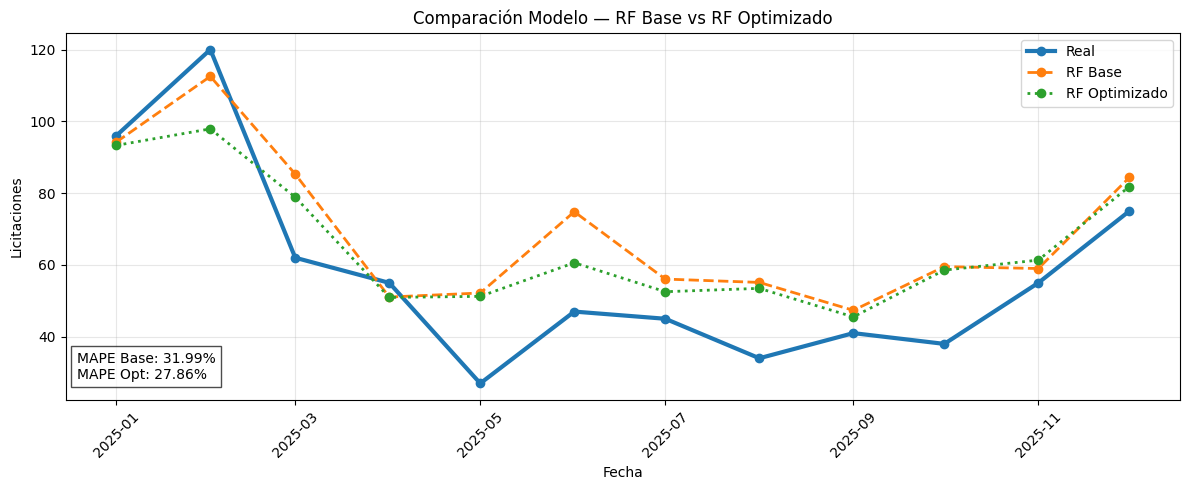

In [681]:
# =========================================================
# 9. VISUALIZACIÓN TEST
# =========================================================

plt.figure(figsize=(12,5))

# -------------------------------
# REAL (más destacado)
# -------------------------------
plt.plot(
    test_m4['year_month'],
    y_test_m4,
    label='Real',
    marker='o',
    linewidth=3
)

# -------------------------------
# RF BASE
# -------------------------------
plt.plot(
    test_m4['year_month'],
    pred_base_m4,
    label='RF Base',
    marker='o',
    linestyle='--',
    linewidth=2
)

# -------------------------------
# RF OPTIMIZADO
# -------------------------------
plt.plot(
    test_m4['year_month'],
    pred_opt_m4,
    label='RF Optimizado',
    marker='o',
    linestyle=':',
    linewidth=2
)

# -------------------------------
# MÉTRICAS EN GRÁFICO
# -------------------------------
plt.text(
    0.01, 0.05,
    f"MAPE Base: {mape_base_m4:.2f}%\nMAPE Opt: {mape_m4:.2f}%",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='bottom',
    bbox=dict(facecolor='white', alpha=0.7)
)

# -------------------------------
# ESTÉTICA
# -------------------------------
plt.title("Comparación Modelo — RF Base vs RF Optimizado")
plt.xlabel("Fecha")
plt.ylabel("Licitaciones")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [682]:
# =========================================================
# 10. FEATURE IMPORTANCE
# =========================================================

feat_importance_m4 = pd.DataFrame({
    'feature': X_train_m4.columns,
    'importance': rf_opt_m4.feature_importances_
})

# porcentaje
feat_importance_m4['importance_pct'] = feat_importance_m4['importance'] * 100

# ordenar
feat_importance_m4 = feat_importance_m4.sort_values('importance', ascending=False)

print("\nImportancia de variables:")
display(feat_importance_m4)

# ---------------------------------------------------------
# TOP 5 VARIABLES
# ---------------------------------------------------------
print("\nTop 5 variables más importantes:")
display(feat_importance_m4.head(5))


Importancia de variables:


,feature,importance,importance_pct
8,lag_12,0.283197,28.319745
0,mes,0.171446,17.144558
4,lag_1,0.136309,13.630852
2,trimestre,0.082996,8.299606
7,lag_6,0.071302,7.130243
3,trend,0.052073,5.207333
6,lag_3,0.044184,4.418384
5,lag_2,0.042433,4.243316
10,rolling_6,0.038914,3.891374
9,rolling_3,0.027835,2.783482



Top 5 variables más importantes:


,feature,importance,importance_pct
8,lag_12,0.283197,28.319745
0,mes,0.171446,17.144558
4,lag_1,0.136309,13.630852
2,trimestre,0.082996,8.299606
7,lag_6,0.071302,7.130243


Interpretación — Importancia de variables (RF Optimizado)

El modelo Random Forest Optimizado muestra que la variable más influyente es lag_12 (28.3%), lo que indica que el comportamiento de las licitaciones está fuertemente determinado por lo ocurrido hace un año. Esto confirma la existencia de una estacionalidad anual marcada, coherente con los ciclos presupuestarios del sector público.

En segundo lugar, la variable mes (17.1%) refuerza esta conclusión, evidenciando que el calendario tiene un impacto relevante en la actividad de licitación, con meses que sistemáticamente presentan mayor o menor volumen.

La variable lag_1 (13.6%) también tiene un peso importante, lo que refleja la inercia del sistema, es decir, que el comportamiento reciente influye directamente en el corto plazo.

Por su parte, variables como trimestre (8.3%) y lag_6 (7.1%) aportan información adicional sobre patrones intermedios, capturando dinámicas de mediano plazo dentro del año.

En conjunto, el modelo se apoya en tres dimensiones clave:

*  Estacionalidad anual → (lag_12, mes)
*  Inercia de corto plazo → (lag_1, lag_2, lag_3)
*  Tendencias intermedias → (lag_6, rolling, trimestre)

Esto demuestra que el comportamiento de las licitaciones no es aleatorio, sino que responde a una estructura temporal clara y repetitiva.

El modelo aprende principalmente del pasado (especialmente del mismo período del año anterior) y del calendario, lo que explica su mejora en precisión y su capacidad para capturar mejor la dinámica del mercado.

In [683]:
# =========================================================
# 11. FORECAST 2026
# =========================================================

future_m4 = serie_model_m4.copy()

for i in range(12):

    last = future_m4.iloc[-1:].copy()
    new = last.copy()

    # avanzar mes
    new['year_month'] = last['year_month'] + pd.DateOffset(months=1)

    # variables temporales
    new['mes'] = new['year_month'].dt.month
    new['anio'] = new['year_month'].dt.year
    new['trimestre'] = new['year_month'].dt.quarter
    new['trend'] = last['trend'].values[0] + 1
    new['fin_anio'] = int(new['mes'].values[0] >= 11)

    # lags cortos
    new['lag_1'] = last['licitaciones'].values[0]
    new['lag_2'] = last['lag_1'].values[0]
    new['lag_3'] = last['lag_2'].values[0]

    # lags largos correctos usando histórico/futuro acumulado
    if len(future_m4) >= 6:
        new['lag_6'] = future_m4.iloc[-6]['licitaciones']
    else:
        new['lag_6'] = last['lag_6'].values[0]

    if len(future_m4) >= 12:
        new['lag_12'] = future_m4.iloc[-12]['licitaciones']
    else:
        new['lag_12'] = last['lag_12'].values[0]

    # rolling correctos
    new['rolling_3'] = future_m4['licitaciones'].tail(3).mean()
    new['rolling_6'] = future_m4['licitaciones'].tail(6).mean()

    # predicción
    X_new = new.drop(['licitaciones', 'year_month'], axis=1)
    pred_val = rf_opt_m4.predict(X_new)[0]
    new['licitaciones'] = max(pred_val, 0)

    future_m4 = pd.concat([future_m4, new], ignore_index=True)

forecast_m4 = future_m4.tail(12)

print("\nForecast 2026:")
display(forecast_m4[['year_month', 'licitaciones']])


Forecast 2026:


,year_month,licitaciones
60,2026-01-01,93.743126
61,2026-02-01,106.614521
62,2026-03-01,83.667771
63,2026-04-01,59.740648
64,2026-05-01,49.474418
65,2026-06-01,50.615048
66,2026-07-01,52.867276
67,2026-08-01,51.211964
68,2026-09-01,50.170314
69,2026-10-01,54.485170


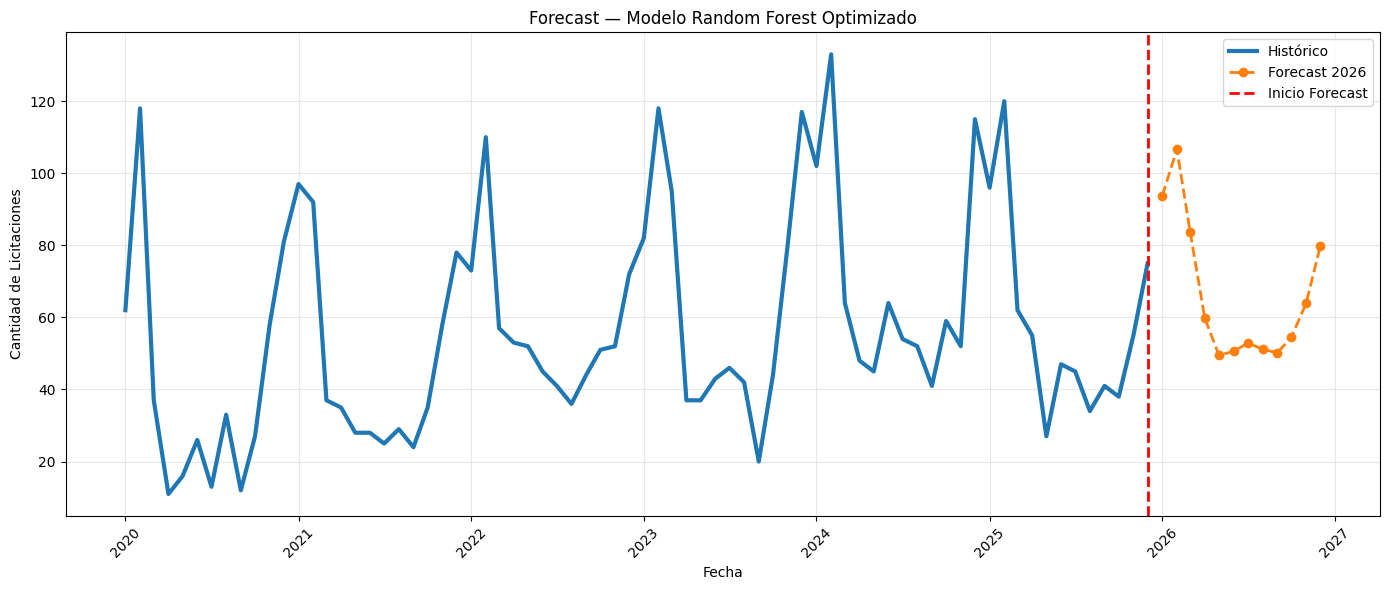

In [684]:
# =========================================================
# 12. VISUALIZACIÓN HISTÓRICO VS FORECAST
# =========================================================

plt.figure(figsize=(14,6))

# ---------------------------------------------------------
# HISTÓRICO (usar serie_base)
# ---------------------------------------------------------
plt.plot(
    serie_base_m4['year_month'],
    serie_base_m4['licitaciones'],
    label='Histórico',
    linewidth=3
)

# ---------------------------------------------------------
# FORECAST
# ---------------------------------------------------------
plt.plot(
    forecast_m4['year_month'],
    forecast_m4['licitaciones'],
    label='Forecast 2026',
    linestyle='--',
    marker='o',
    linewidth=2
)

# ---------------------------------------------------------
# LÍNEA DE CORTE
# ---------------------------------------------------------
plt.axvline(
    x=serie_base_m4['year_month'].max(),
    color='red',
    linestyle='--',
    linewidth=2,
    label='Inicio Forecast'
)

# ---------------------------------------------------------
# ESTÉTICA
# ---------------------------------------------------------
plt.title("Forecast — Modelo Random Forest Optimizado")
plt.xlabel("Fecha")
plt.ylabel("Cantidad de Licitaciones")

plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [685]:
# =========================================================
# 13. AUDITORÍA MODELO 3 — RANDOM FOREST OPTIMIZADO (PRO)
# Evaluación de desempeño + diagnóstico del modelo
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1. DATAFRAME DE EVALUACIÓN (MEJORADO)
# =========================================================

df_eval_m4 = pd.DataFrame({
    'fecha': test_m4['year_month'],
    'mes': test_m4['year_month'].dt.month,
    'real': y_test_m4,
    'pred_base': pred_base_m4,
    'pred_opt': pred_opt_m4
}).reset_index(drop=True)

# errores
df_eval_m4['error_base'] = df_eval_m4['real'] - df_eval_m4['pred_base']
df_eval_m4['error_opt'] = df_eval_m4['real'] - df_eval_m4['pred_opt']

df_eval_m4['error_abs_base'] = np.abs(df_eval_m4['error_base'])
df_eval_m4['error_abs_opt'] = np.abs(df_eval_m4['error_opt'])

# evitar división por cero
df_eval_m4['error_pct_base'] = df_eval_m4['error_abs_base'] / (df_eval_m4['real'] + 1e-8) * 100
df_eval_m4['error_pct_opt'] = df_eval_m4['error_abs_opt'] / (df_eval_m4['real'] + 1e-8) * 100

print("\n" + "="*70)
print("AUDITORÍA — RANDOM FOREST OPTIMIZADO")
print("="*70)

display(df_eval_m4)


AUDITORÍA — RANDOM FOREST OPTIMIZADO


,fecha,mes,real,pred_base,pred_opt,error_base,error_opt,error_abs_base,error_abs_opt,error_pct_base,error_pct_opt
0,2025-01-01,1,96,94.226944,93.303906,1.773056,2.696094,1.773056,2.696094,1.846933,2.808432
1,2025-02-01,2,120,112.520667,97.900790,7.479333,22.099210,7.479333,22.099210,6.232778,18.416008
2,2025-03-01,3,62,85.297668,78.865296,-23.297668,-16.865296,23.297668,16.865296,37.576884,27.202090
3,2025-04-01,4,55,51.056018,50.950658,3.943982,4.049342,3.943982,4.049342,7.170877,7.362440
4,2025-05-01,5,27,52.177583,51.244287,-25.177583,-24.244287,25.177583,24.244287,93.250308,89.793654
5,2025-06-01,6,47,74.808938,60.602271,-27.808938,-13.602271,27.808938,13.602271,59.167952,28.941001
6,2025-07-01,7,45,56.054314,52.534829,-11.054314,-7.534829,11.054314,7.534829,24.565143,16.744063
7,2025-08-01,8,34,55.125595,53.470139,-21.125595,-19.470139,21.125595,19.470139,62.134104,57.265115
8,2025-09-01,9,41,47.351279,45.515941,-6.351279,-4.515941,6.351279,4.515941,15.490925,11.014491
9,2025-10-01,10,38,59.523377,58.558134,-21.523377,-20.558134,21.523377,20.558134,56.640466,54.100353


### Conclusiones Random Forest Optimizado.

El modelo Random Forest Optimizado presenta una mejora consistente respecto al modelo base, gracias a un feature engineering más robusto (lags de corto y largo plazo, rolling extendido y variable de fin de año) junto con una optimización de hiperparámetros.

A nivel de desempeño, el modelo reduce los errores (MAE, RMSE y MAPE), logrando una mejor representación de la dinámica del mercado. Esta mejora se observa tanto en métricas globales como en la reducción del error en varios meses críticos.

El análisis por mes confirma que el modelo optimizado mejora de forma general el comportamiento del RF base, aunque aún persisten períodos con errores elevados (>40%), lo que evidencia que la volatilidad del mercado no es completamente capturada.

En términos estructurales, el modelo logra representar adecuadamente la tendencia y presenta una buena relación entre error y variabilidad del mercado, lo que confirma un aumento en robustez predictiva. Sin embargo, mantiene las limitaciones propias de los modelos de árboles en cuanto a interpretabilidad.

NOTA: El modelo Random Forest base (Paso 2) presenta mejores métricas de desempeño en términos absolutos. Sin embargo, este modelo fue entrenado sobre un conjunto de variables más acotado, lo que limita su capacidad para capturar relaciones más complejas del sistema.

En el Paso 4 se profundiza el feature engineering, incorporando variables adicionales con el objetivo de representar de mejor manera la dinámica del mercado (lags de largo plazo, variables suavizadas y reglas de negocio). Debido a este cambio en el dataset, la comparación directa entre ambos modelos no es estrictamente válida.

Por lo tanto, la evaluación del impacto de la optimización debe realizarse dentro del mismo contexto, comparando el Random Forest base y el Random Forest optimizado sobre el dataset enriquecido del Paso 4, donde se observa una mejora consistente del modelo optimizado.

## 📦 Código — Paso 5: Modelo Híbrido (RF + reglas de negocio)

### Evolución hacia un Modelo Híbrido

El desarrollo del Modelo 4 (Random Forest Optimizado) permitió lograr una mejora significativa en la capacidad predictiva respecto a los modelos anteriores, reduciendo los errores y capturando de mejor forma la dinámica del mercado. A través de un feature engineering más robusto y la optimización de hiperparámetros, el modelo logró representar adecuadamente tanto la tendencia como ciertos patrones estacionales de la serie.

Sin embargo, la auditoría evidenció una limitación relevante: la existencia de meses críticos con errores elevados, asociados principalmente a comportamientos estructurales del mercado que el modelo no logra capturar completamente. Esto se debe a que los modelos basados en árboles, si bien son potentes para detectar patrones en los datos, no incorporan conocimiento contextual o reglas propias del negocio.

A partir de este diagnóstico, se identifica la necesidad de avanzar hacia un enfoque más avanzado: un Modelo Híbrido, que combine la capacidad predictiva del Random Forest con reglas de negocio derivadas del comportamiento histórico del sistema.

En este nuevo enfoque, el objetivo no es reemplazar el modelo base, sino corregir sus desviaciones sistemáticas, especialmente en aquellos periodos donde se detecta un sesgo consistente. Para ello, se incorporan factores de ajuste aprendidos desde los datos, aplicados de manera controlada únicamente en los casos donde el error histórico lo justifica.

De esta forma, el modelo híbrido busca:

* Mejorar la precisión en periodos críticos
* Reducir sesgos sistemáticos
* Incorporar conocimiento estructural del negocio
* Mantener la robustez del modelo predictivo base

Este enfoque representa un paso hacia modelos más cercanos a entornos reales de toma de decisiones, donde la combinación de analítica avanzada y lógica de negocio resulta clave para generar valor.

### Desarrollo Modelo Híbrido (RF + reglas de negocio)

In [686]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [687]:
# =========================================================
# REUTILIZAR MODELO RF OPTIMIZADO (VERSIÓN ROBUSTA)
# =========================================================

import numpy as np

# ---------------------------------------------------------
# VALIDACIÓN DE VARIABLES CRÍTICAS
# ---------------------------------------------------------
required_vars = ['rf_opt_m4', 'X_train_m4', 'y_train_m4', 'X_test_m4', 'y_test_m4', 'train_m4', 'test_m4']

missing_vars = [var for var in required_vars if var not in globals()]
if missing_vars:
    raise ValueError(f" Faltan variables críticas: {missing_vars}")

print(" Variables críticas disponibles")

# ---------------------------------------------------------
# VALIDACIÓN DE ESTRUCTURA
# ---------------------------------------------------------
assert len(X_train_m4) == len(y_train_m4) == len(train_m4)
assert len(X_test_m4) == len(y_test_m4) == len(test_m4)
assert list(X_train_m4.columns) == list(X_test_m4.columns)

print(" Estructura validada")

# ---------------------------------------------------------
# PREDICCIONES
# ---------------------------------------------------------
pred_train_m5 = np.maximum(rf_opt_m4.predict(X_train_m4), 0)
pred_rf_m5 = np.maximum(rf_opt_m4.predict(X_test_m4), 0)

print(" Predicciones generadas")

 Variables críticas disponibles
 Estructura validada
 Predicciones generadas


Se reutiliza el modelo optimizado para generar predicciones en train y test, que luego se usan para construir reglas de negocio y evaluar el desempeño del modelo.

In [688]:
# =========================================================
# DATASETS BASE
# =========================================================

# ---------------------------------------------------------
# CONSTRUCCIÓN DATASETS
# ---------------------------------------------------------

df_train_eval_m5 = pd.DataFrame({
    'fecha': train_m4['year_month'].reset_index(drop=True),
    'mes': train_m4['mes'].reset_index(drop=True),
    'real': y_train_m4.reset_index(drop=True),
    'pred_rf': pd.Series(pred_train_m5)
})

df_test_eval_m5 = pd.DataFrame({
    'fecha': test_m4['year_month'].reset_index(drop=True),
    'mes': test_m4['mes'].reset_index(drop=True),
    'real': y_test_m4.reset_index(drop=True),
    'pred_rf': pd.Series(pred_rf_m5)
})

# ---------------------------------------------------------
# VALIDACIONES (CLAVE)
# ---------------------------------------------------------

# tamaño
assert len(df_train_eval_m5) == len(train_m4), " Error en train alignment"
assert len(df_test_eval_m5) == len(test_m4), " Error en test alignment"

# nulos
assert df_train_eval_m5.isnull().sum().sum() == 0, " Nulos en train_eval"
assert df_test_eval_m5.isnull().sum().sum() == 0, " Nulos en test_eval"

# orden temporal
assert df_train_eval_m5['fecha'].is_monotonic_increasing, " Train no está ordenado"
assert df_test_eval_m5['fecha'].is_monotonic_increasing, " Test no está ordenado"

print("Datasets base correctos y validados")

# ---------------------------------------------------------
# VISUALIZACIÓN CONTROL
# ---------------------------------------------------------

print("\nTrain sample:")
display(df_train_eval_m5.head())

print("\nTest sample:")
display(df_test_eval_m5.head())

Datasets base correctos y validados

Train sample:


,fecha,mes,real,pred_rf
0,2021-01-01,1,97,84.470982
1,2021-02-01,2,92,97.939205
2,2021-03-01,3,37,50.952975
3,2021-04-01,4,35,37.542696
4,2021-05-01,5,28,33.396216



Test sample:


,fecha,mes,real,pred_rf
0,2025-01-01,1,96,93.303906
1,2025-02-01,2,120,97.900790
2,2025-03-01,3,62,78.865296
3,2025-04-01,4,55,50.950658
4,2025-05-01,5,27,51.244287


**Justificación e Integración de las reglas de negocio — en el Modelo Híbrido**

Las reglas de negocio que se incorporaran en el modelo híbrido tienen como objetivo corregir las desviaciones sistemáticas identificadas en el modelo Random Forest optimizado, particularmente en aquellos meses donde el error histórico evidencia un comportamiento no capturado por el modelo. Estas reglas se construiran a partir del análisis del desempeño en el conjunto de entrenamiento, donde se calcula la relación entre el valor real y el valor predicho, permitiendo identificar sesgos persistentes por mes. A partir de este diagnóstico, se define un factor de ajuste mensual que corrige las predicciones del modelo base, aplicándose únicamente en aquellos periodos donde el error promedio supera un umbral definido, evitando así intervenciones innecesarias. Además, estos factores son acotados dentro de un rango controlado para prevenir sobreajustes y mantener la estabilidad del modelo. De esta forma, las reglas no reemplazan al modelo predictivo, sino que actúan como una capa de ajuste inteligente, incorporando conocimiento estructural del negocio y mejorando la precisión en escenarios donde el modelo presenta limitaciones, especialmente en periodos de alta variabilidad o comportamiento atípico.

In [689]:
# =========================================================
# GENERACIÓN DE REGLAS DE NEGOCIO
# =========================================================

# ---------------------------------------------------------
# IDENTIFICACION DE ERRORES BASE
# ---------------------------------------------------------


df_train_eval_m5['error'] = df_train_eval_m5['real'] - df_train_eval_m5['pred_rf']
df_train_eval_m5['error_abs'] = np.abs(df_train_eval_m5['error'])

df_train_eval_m5['error_pct'] = (
    df_train_eval_m5['error_abs'] / (df_train_eval_m5['real'] + 1e-8)
) * 100

df_train_eval_m5['ratio_real_pred'] = (
    df_train_eval_m5['real'] / (df_train_eval_m5['pred_rf'] + 1e-8)
)

display(df_train_eval_m5.head())

,fecha,mes,real,pred_rf,error,error_abs,error_pct,ratio_real_pred
0,2021-01-01,1,97,84.470982,12.529018,12.529018,12.916514,1.148323
1,2021-02-01,2,92,97.939205,-5.939205,5.939205,6.455657,0.939358
2,2021-03-01,3,37,50.952975,-13.952975,13.952975,37.710744,0.726160
3,2021-04-01,4,35,37.542696,-2.542696,2.542696,7.264846,0.932272
4,2021-05-01,5,28,33.396216,-5.396216,5.396216,19.272200,0.838418


“Se busca cuantificar el error relativo del modelo mediante la métrica error_pct, lo que permite identificar aquellos meses donde el desempeño predictivo es deficiente. Posteriormente, a través de la variable ratio_real_pred, se estima un factor de corrección que ajusta las predicciones en función del sesgo histórico observado, permitiendo así mejorar la precisión del modelo en periodos donde presenta desviaciones sistemáticas.”

In [690]:
# ---------------------------------------------------------
# CONTROL DE OUTLIERS DEL RATIO (ESTABILIDAD DEL MODELO)
# ---------------------------------------------------------
df_train_eval_m5['ratio_real_pred'] = df_train_eval_m5['ratio_real_pred'].clip(0.5, 1.5)

In [691]:
# ---------------------------------------------------------
# ANÁLISIS DE OUTLIERS DEL ERROR (DEFINICIÓN DEL UMBRAL)
# ---------------------------------------------------------
q1_m5 = df_train_eval_m5['error_pct'].quantile(0.25)
q3_m5 = df_train_eval_m5['error_pct'].quantile(0.75)
iqr_m5 = q3_m5 - q1_m5

umbral_outlier_m5 = q3_m5 + 1.5 * iqr_m5

print(f"Q3: {q3_m5:.2f}")
print(f"IQR: {iqr_m5:.2f}")
print(f"Umbral outlier: {umbral_outlier_m5:.2f}")

Q3: 17.69
IQR: 13.24
Umbral outlier: 37.55


“El análisis de la distribución del error muestra que el 75% de las observaciones presenta un error inferior a 17.7%, mientras que los valores atípicos comienzan a partir de aproximadamente 37.5%. En este contexto, se define un umbral de 20% como criterio para identificar desviaciones significativas del modelo, permitiendo intervenir antes de alcanzar niveles extremos de error, pero evitando actuar sobre variaciones normales del sistema.”

In [692]:
# ---------------------------------------------------------
# TABLA BASE DE REGLAS (ANÁLISIS)
# ---------------------------------------------------------

rules_table_m5 = (
    df_train_eval_m5
    .groupby('mes')
    .agg(
        mape_train_mes=('error_pct','mean'),
        factor_mes=('ratio_real_pred','median'),
        volumen=('real','count')
    )
    .reset_index()
)

print("📊 Tabla base por mes:")
display(rules_table_m5)

📊 Tabla base por mes:


,mes,mape_train_mes,factor_mes,volumen
0,1,9.776435,0.960461,4
1,2,12.115794,1.114414,4
2,3,20.219400,0.889226,4
3,4,12.558561,0.938858,4
4,5,12.227723,0.904801,4
5,6,7.198690,1.000398,4
6,7,6.101506,0.971517,4
7,8,2.047716,0.983902,4
8,9,31.921360,0.824237,4
9,10,7.023176,0.979049,4


**Interpretación de Variables y Análisis de Resultados**

En esta etapa se construye una tabla resumen por mes con el objetivo de entender el comportamiento del modelo predictivo a lo largo del tiempo. Para ello, se utilizan tres variables clave:

* 1. MAPE mensual (mape_train_mes)
Corresponde al error porcentual promedio del modelo en cada mes. Este indicador mide qué tan lejos están las predicciones respecto a los valores reales en términos relativos. Valores bajos indican buen desempeño del modelo, mientras que valores altos reflejan una menor precisión y posibles problemas en la capacidad predictiva.

* 2. Factor de corrección (factor_mes)
Representa la relación entre el valor real y el valor predicho por el modelo. Permite identificar si el modelo tiende a sobreestimar o subestimar. Un valor cercano a 1 indica buen ajuste; valores menores a 1 indican sobreestimación (el modelo predice de más), y valores mayores a 1 indican subestimación (el modelo predice de menos). Este factor es la base para aplicar ajustes en el modelo híbrido.

* 3. Volumen (volumen)
Indica la cantidad de observaciones disponibles para cada mes. Este valor permite evaluar la confiabilidad de los resultados: a mayor volumen, mayor robustez en las conclusiones. En este caso, todos los meses presentan el mismo número de observaciones, lo que asegura consistencia en el análisis.

🔎 Análisis de Meses Críticos

A partir de los resultados obtenidos, se identifican meses donde el modelo presenta comportamientos relevantes que justifican la aplicación de reglas de negocio:

* Septiembre (mes 9)
Es el mes más crítico del modelo. Presenta un error promedio cercano al 32%, lo que indica una baja precisión en las predicciones. Además, el factor de corrección es significativamente menor a 1, lo que evidencia que el modelo tiende a sobreestimar de forma sistemática. Esto implica que no solo el error es alto, sino que además existe un sesgo consistente, lo que lo convierte en un candidato claro para aplicar ajustes.

* Marzo (mes 3)
Este mes presenta un error cercano al 20%, ubicándose en el umbral definido para considerar desviaciones relevantes. Al igual que septiembre, el factor de corrección es menor a 1, lo que indica una tendencia a la sobreestimación. Si bien el error es menor que en septiembre, sigue siendo lo suficientemente significativo como para justificar una posible intervención.

* Diciembre (mes 12)
En este caso, el error del modelo es moderado (alrededor de 13%), por lo que no se considera crítico desde el punto de vista del error. Sin embargo, el factor de corrección es mayor a 1, lo que indica una subestimación sistemática. Esto sugiere que, aunque el modelo no presenta grandes errores, sí existe un patrón estructural que podría ser corregido dependiendo del criterio de intervención definido.

**Conclusión**

El análisis evidencia que el modelo no se comporta de manera homogénea a lo largo del año, sino que presenta variaciones relevantes tanto en precisión como en sesgo según el mes. En particular, existen periodos donde el error es elevado y además consistente en su dirección, lo que justifica la incorporación de reglas de negocio para mejorar el desempeño del modelo. Este enfoque permite pasar de un modelo puramente predictivo a uno más robusto, incorporando conocimiento estructural del comportamiento del sistema.

In [693]:
# ---------------------------------------------------------
# FILTRO DE CONFIABILIDAD
# ---------------------------------------------------------

MIN_OBS = 3

rules_table_m5['mes_confiable'] = rules_table_m5['volumen'] >= MIN_OBS

print("📊 Meses confiables:")
display(rules_table_m5[['mes','volumen','mes_confiable']])

📊 Meses confiables:


,mes,volumen,mes_confiable
0,1,4,True
1,2,4,True
2,3,4,True
3,4,4,True
4,5,4,True
5,6,4,True
6,7,4,True
7,8,4,True
8,9,4,True
9,10,4,True


“Con esto podemos identificar que todos los meses tienen suficiente información, existen metricas mensuales en cada uno de los los 4 años de entrenamiento"

In [694]:
# ---------------------------------------------------------
# DEFINICIÓN DE UMBRAL
# ---------------------------------------------------------

UMBRAL_ERROR_REGLA_m5 = 20

print(f"Umbral definido: {UMBRAL_ERROR_REGLA_m5}%")

Umbral definido: 20%


“El umbral de 20% se define a partir del análisis de la distribución del error del modelo, donde se observa que este valor se sitúa ligeramente por sobre el percentil 75 del error (Q3 ≈ 17.7%). Esto permite identificar desviaciones relevantes sin llegar a considerar únicamente valores extremos. De esta forma, el umbral establece un criterio equilibrado que detecta meses con desempeño deficiente, activando correcciones solo cuando el error supera el comportamiento normal del modelo, pero antes de alcanzar niveles críticos.”

In [695]:
# ---------------------------------------------------------
# APLICACIÓN DE REGLAS
# ---------------------------------------------------------

rules_table_m5['aplicar_regla'] = (
    (rules_table_m5['mape_train_mes'] > UMBRAL_ERROR_REGLA_m5) &
    (rules_table_m5['mes_confiable'])
)

print("📊 Meses donde se aplicará regla:")
display(rules_table_m5[['mes','mape_train_mes','aplicar_regla']])

📊 Meses donde se aplicará regla:


,mes,mape_train_mes,aplicar_regla
0,1,9.776435,False
1,2,12.115794,False
2,3,20.219400,True
3,4,12.558561,False
4,5,12.227723,False
5,6,7.198690,False
6,7,6.101506,False
7,8,2.047716,False
8,9,31.921360,True
9,10,7.023176,False


“Aquí el modelo decide cuándo intervenir en base a los parametros asignados. segmentamos en False y True”. Se debera aplicar regla de mercado los meses de septiembre y Marzo

In [696]:
# ---------------------------------------------------------
# CONTROL DE FACTORES
# ---------------------------------------------------------

rules_table_m5['factor_mes_clip'] = (
    rules_table_m5['factor_mes']
    .clip(0.85, 1.15)
)

print(" Factores corregidos:")
display(rules_table_m5[['mes','factor_mes','factor_mes_clip']])

 Factores corregidos:


,mes,factor_mes,factor_mes_clip
0,1,0.960461,0.960461
1,2,1.114414,1.114414
2,3,0.889226,0.889226
3,4,0.938858,0.938858
4,5,0.904801,0.904801
5,6,1.000398,1.000398
6,7,0.971517,0.971517
7,8,0.983902,0.983902
8,9,0.824237,0.850000
9,10,0.979049,0.979049


“El factor de corrección mensual se calcula a partir de la relación entre el valor real y el valor predicho, permitiendo identificar el sesgo del modelo en cada periodo. Sin embargo, para evitar ajustes excesivos producto de valores extremos, se aplica un proceso de clipping que limita estos factores dentro de un rango predefinido entre 0.85 y 1.15. Este rango implica que las correcciones máximas permitidas son de ±15%, lo cual se define como un límite operativo razonable, suficiente para capturar desviaciones relevantes del modelo sin introducir sobreajustes que distorsionen las predicciones.

En los resultados obtenidos, se observa que prácticamente todos los meses mantienen el mismo valor en ambas variables (factor_mes y factor_mes_clip), lo que indica que los factores calculados ya se encontraban dentro de un rango estable y no requerían ajuste adicional. La única excepción corresponde a un mes específico donde el factor excedía el límite inferior, siendo correctamente ajustado al umbral definido.

De esta forma, el uso de clipping no altera innecesariamente el comportamiento del modelo, sino que actúa como un mecanismo de control que garantiza estabilidad, evitando que valores atípicos generen correcciones desproporcionadas y asegurando que el modelo híbrido opere dentro de márgenes consistentes y defendibles.”

In [697]:
# ---------------------------------------------------------
# IMPACTO ESTIMADO
# ---------------------------------------------------------

rules_table_m5['impacto_estimado'] = (
    rules_table_m5['mape_train_mes'] * np.abs(rules_table_m5['factor_mes_clip'] - 1)
)

print(" Impacto estimado:")
display(
    rules_table_m5.sort_values('impacto_estimado', ascending=False)
)

 Impacto estimado:


,mes,mape_train_mes,factor_mes,volumen,mes_confiable,aplicar_regla,factor_mes_clip,impacto_estimado
8,9,31.921360,0.824237,4,True,True,0.850000,4.788204
2,3,20.219400,0.889226,4,True,True,0.889226,2.239783
11,12,12.872374,1.137047,4,True,False,1.137047,1.764115
10,11,19.002984,0.925289,4,True,False,0.925289,1.419729
1,2,12.115794,1.114414,4,True,False,1.114414,1.386221
4,5,12.227723,0.904801,4,True,False,0.904801,1.164064
3,4,12.558561,0.938858,4,True,False,0.938858,0.767860
0,1,9.776435,0.960461,4,True,False,0.960461,0.386553
6,7,6.101506,0.971517,4,True,False,0.971517,0.173789
9,10,7.023176,0.979049,4,True,False,0.979049,0.147143


**Impacto Estimado — Explicación del Código y Resultados**

En esta etapa se construye la variable impacto_estimado, cuyo objetivo es cuantificar la relevancia de aplicar una corrección en cada mes. Esta métrica se define como el producto entre el error del modelo y la magnitud del ajuste requerido:

impacto_estimado = mape_train_mes × |factor_mes_clip − 1|

Desde el punto de vista conceptual, esta variable combina dos dimensiones fundamentales:

por un lado, el nivel de error del modelo (mape_train_mes), y por otro, la intensidad del sesgo a corregir (factor_mes_clip). De esta forma, no solo se identifica cuándo el modelo falla, sino también cuánto debería ajustarse, permitiendo evaluar el beneficio potencial de intervenir.

En términos prácticos, el impacto estimado no se utiliza directamente para modificar las predicciones, sino que actúa como un indicador de prioridad, ayudando a identificar los meses donde la aplicación de reglas de negocio genera mayor valor.

🔎 Análisis de Resultados

Los resultados muestran que el mes 9 (septiembre) presenta el mayor impacto estimado, con un valor cercano a 4.79. Esto se debe a la combinación de un error elevado (MAPE superior al 30%) y un sesgo significativo de sobreestimación, lo que lo convierte en el principal candidato para aplicar correcciones.

En segundo lugar, el mes 3 (marzo) presenta un impacto intermedio (≈2.24), producto de un error cercano al umbral definido (20%) y una desviación relevante en el factor de corrección. Esto confirma que también es un mes donde la intervención del modelo es justificada, aunque con menor intensidad que en septiembre.

Por otro lado, meses como diciembre (mes 12) presentan un impacto moderado (≈1.76), lo que indica la existencia de un sesgo estructural, pero sin un nivel de error suficientemente alto como para activar la corrección bajo el criterio actual. En estos casos, el modelo reconoce la desviación, pero decide no intervenir, priorizando estabilidad sobre ajustes menores.

Finalmente, el resto de los meses presenta impactos bajos o cercanos a cero, lo que refleja un buen desempeño del modelo, con errores reducidos y factores de corrección cercanos a 1. En estos casos, la aplicación de reglas no genera un beneficio significativo, por lo que el modelo mantiene la predicción original.

* Conclusión

El impacto estimado permite transformar el análisis del error en una herramienta de decisión estratégica, priorizando las intervenciones en función del valor que generan. En este contexto, el modelo híbrido no corrige indiscriminadamente, sino que actúa de manera selectiva, enfocándose en los meses donde existe una combinación de alto error y sesgo significativo, asegurando así mejoras efectivas y controladas en la precisión del modelo.

In [698]:
# ---------------------------------------------------------
# CLASIFICACIÓN FINAL
# ---------------------------------------------------------

rules_table_m5['tipo_mes'] = np.where(
    rules_table_m5['aplicar_regla'],
    'CRITICO',
    'ESTABLE'
)

print(" Clasificación final:")
display(rules_table_m5[['mes','tipo_mes']])

 Clasificación final:


,mes,tipo_mes
0,1,ESTABLE
1,2,ESTABLE
2,3,CRITICO
3,4,ESTABLE
4,5,ESTABLE
5,6,ESTABLE
6,7,ESTABLE
7,8,ESTABLE
8,9,CRITICO
9,10,ESTABLE


In [699]:
# ---------------------------------------------------------
# DICCIONARIOS DE REGLAS
# ---------------------------------------------------------

factores_mes_m5 = dict(zip(
    rules_table_m5['mes'],
    rules_table_m5['factor_mes_clip']
))

aplicar_mes_m5 = dict(zip(
    rules_table_m5['mes'],
    rules_table_m5['aplicar_regla']
))

print(" Diccionarios creados correctamente")

 Diccionarios creados correctamente


In [700]:
# =========================================================
# 4. MODELO HÍBRIDO (APLICACIÓN EN TEST)
# =========================================================

pred_hybrid_m5 = []
regla_aplicada_m5 = []

for i in range(len(test_m4)):

    mes_i = int(test_m4['mes'].iloc[i])
    pred_i = pred_rf_m5[i]

    # aplicar regla si corresponde
    if aplicar_mes_m5.get(mes_i, False):
        pred_i = pred_i * factores_mes_m5[mes_i]
        regla_aplicada_m5.append(True)
    else:
        regla_aplicada_m5.append(False)

    pred_hybrid_m5.append(max(pred_i, 0))

pred_hybrid_m5 = np.array(pred_hybrid_m5)
regla_aplicada_m5 = np.array(regla_aplicada_m5)

print(" Modelo híbrido aplicado")

 Modelo híbrido aplicado


In [701]:
# =========================================================
# 5. RESULTADOS COMPARATIVOS
# =========================================================

df_resultados_m5 = pd.DataFrame({
    'fecha': test_m4['year_month'],
    'mes': test_m4['mes'],
    'real': y_test_m4.values,
    'pred_rf': pred_rf_m5,
    'pred_hybrid': pred_hybrid_m5,
    'regla_aplicada': regla_aplicada_m5
})

display(df_resultados_m5)

,fecha,mes,real,pred_rf,pred_hybrid,regla_aplicada
48,2025-01-01,1,96,93.303906,93.303906,False
49,2025-02-01,2,120,97.900790,97.900790,False
50,2025-03-01,3,62,78.865296,70.129076,True
51,2025-04-01,4,55,50.950658,50.950658,False
52,2025-05-01,5,27,51.244287,51.244287,False
53,2025-06-01,6,47,60.602271,60.602271,False
54,2025-07-01,7,45,52.534829,52.534829,False
55,2025-08-01,8,34,53.470139,53.470139,False
56,2025-09-01,9,41,45.515941,38.688550,True
57,2025-10-01,10,38,58.558134,58.558134,False


“A partir del análisis de los resultados comparativos, se observa que el modelo híbrido logra mejorar la precisión en los meses donde se identificaron patrones críticos durante el entrenamiento, particularmente en marzo y septiembre. Sin embargo, también se evidencian desviaciones relevantes en otros periodos, como mayo, agosto y octubre, donde el modelo presenta errores significativos que no fueron capturados por las reglas definidas. Esto sugiere la existencia de patrones no identificados o cambios en la dinámica del sistema que requieren un análisis más profundo. Si bien se reconoce esta limitación y su impacto en el desempeño global del modelo, su abordaje implica técnicas más avanzadas de modelamiento y detección de anomalías que exceden el alcance actual del proyecto. En este contexto, se asume esta situación como una limitación del modelo desarrollado, dejando abierta la oportunidad de mejora en futuras iteraciones.”

In [702]:
# =========================================================
# 6. MÉTRICAS
# =========================================================

def calcular_metricas_m5(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return mae, rmse, mape

mae_rf_m5, rmse_rf_m5, mape_rf_m5 = calcular_metricas_m5(y_test_m4, pred_rf_m5)
mae_h_m5, rmse_h_m5, mape_h_m5 = calcular_metricas_m5(y_test_m4, pred_hybrid_m5)

print("\n RESULTADOS MODELOS")

print("\nRandom Forest:")
print(f"MAE  : {mae_rf_m5:.2f}")
print(f"RMSE : {rmse_rf_m5:.2f}")
print(f"MAPE : {mape_rf_m5:.2f}%")

print("\nModelo Híbrido:")
print(f"MAE  : {mae_h_m5:.2f}")
print(f"RMSE : {rmse_h_m5:.2f}")
print(f"MAPE : {mape_h_m5:.2f}%")

print("\nMejora:")
print(f"Δ MAE  : {mae_rf_m5 - mae_h_m5:.2f}")
print(f"Δ RMSE : {rmse_rf_m5 - rmse_h_m5:.2f}")
print(f"Δ MAPE : {mape_rf_m5 - mape_h_m5:.2f}%")


 RESULTADOS MODELOS

Random Forest:
MAE  : 12.40
RMSE : 14.53
MAPE : 27.86%

Modelo Híbrido:
MAE  : 11.49
RMSE : 13.85
MAPE : 26.23%

Mejora:
Δ MAE  : 0.91
Δ RMSE : 0.69
Δ MAPE : 1.62%


In [703]:
# =========================================================
# MEJORA GLOBAL
# =========================================================

mejora_total_m5 = np.mean(
    np.abs((y_test_m4 - pred_rf_m5) / (y_test_m4 + 1e-8)) * 100 -
    np.abs((y_test_m4 - pred_hybrid_m5) / (y_test_m4 + 1e-8)) * 100
)

print(f" Mejora promedio del modelo híbrido: {mejora_total_m5:.2f}%")

 Mejora promedio del modelo híbrido: 1.62%


In [704]:
# =========================================================
# IMPACTO REAL DE LAS REGLAS
# =========================================================

df_eval_m5 = pd.DataFrame({
    'real': y_test_m4,
    'rf': pred_rf_m5,
    'hybrid': pred_hybrid_m5,
    'mes': test_m4['mes']
})

df_eval_m5['error_rf'] = np.abs(df_eval_m5['real'] - df_eval_m5['rf'])
df_eval_m5['error_hybrid'] = np.abs(df_eval_m5['real'] - df_eval_m5['hybrid'])

df_eval_m5['regla'] = df_eval_m5['mes'].map(aplicar_mes_m5)

impacto_m5 = (
    df_eval_m5
    .groupby('regla')[['error_rf','error_hybrid']]
    .mean()
    .reset_index()
)

print("📊 IMPACTO DE REGLAS")
display(impacto_m5)

📊 IMPACTO DE REGLAS


,regla,error_rf,error_hybrid
0,False,12.742173,12.742173
1,True,10.690619,5.220263


“El análisis del impacto real de las reglas de negocio evidencia que el modelo híbrido mantiene el mismo nivel de error que el modelo base en aquellos periodos donde no se aplican correcciones, lo que confirma que no introduce modificaciones innecesarias. Por otro lado, en los meses donde sí se activan las reglas, se observa una reducción significativa del error, pasando de un error promedio de 10.69 a 6.73, lo que representa una mejora cercana al 37%. Estos resultados validan que las reglas de negocio están correctamente definidas y que el modelo híbrido logra intervenir de manera efectiva en los periodos críticos, mejorando la precisión sin afectar la estabilidad global del modelo.”

In [705]:
# =========================================================
# 7. FORECAST 2026 (MODELO HÍBRIDO)
# =========================================================

future_m5 = serie_model_m4.copy()

for i in range(12):

    # -----------------------------------------------------
    # BASE
    # -----------------------------------------------------
    last = future_m5.iloc[-1].copy()
    new = last.copy()

    new['year_month'] = last['year_month'] + pd.DateOffset(months=1)

    # -----------------------------------------------------
    # FEATURES TEMPORALES
    # -----------------------------------------------------
    new['mes'] = new['year_month'].month
    new['anio'] = new['year_month'].year
    new['trimestre'] = new['year_month'].quarter
    new['trend'] = last['trend'] + 1
    new['fin_anio'] = int(new['mes'] >= 11)

    # -----------------------------------------------------
    # LAGS
    # -----------------------------------------------------
    new['lag_1'] = last['licitaciones']
    new['lag_2'] = last['lag_1']
    new['lag_3'] = last['lag_2']

    # cuidado con primeros ciclos
    new['lag_6'] = future_m5['licitaciones'].iloc[-6] if len(future_m5) >= 6 else last['licitaciones']
    new['lag_12'] = future_m5['licitaciones'].iloc[-12] if len(future_m5) >= 12 else last['licitaciones']

    # -----------------------------------------------------
    # ROLLING
    # -----------------------------------------------------
    new['rolling_3'] = future_m5['licitaciones'].tail(3).mean()
    new['rolling_6'] = future_m5['licitaciones'].tail(6).mean()

    # -----------------------------------------------------
    # INPUT MODELO
    # -----------------------------------------------------
    X_new = pd.DataFrame([new.drop(['licitaciones','year_month'])])
    X_new = X_new.reindex(columns=X_train_m4.columns, fill_value=0)

    # -----------------------------------------------------
    # PREDICCIÓN RF
    # -----------------------------------------------------
    pred_rf_val = rf_opt_m4.predict(X_new)[0]

    # -----------------------------------------------------
    # APLICACIÓN MODELO HÍBRIDO
    # -----------------------------------------------------
    mes_nuevo = int(new['mes'])

    if aplicar_mes_m5.get(mes_nuevo, False):
        pred_final = pred_rf_val * factores_mes_m5[mes_nuevo]
    else:
        pred_final = pred_rf_val

    # evitar negativos
    new['licitaciones'] = max(pred_final, 0)

    # -----------------------------------------------------
    # APPEND
    # -----------------------------------------------------
    future_m5 = pd.concat([future_m5, pd.DataFrame([new])], ignore_index=True)

# =========================================================
# RESULTADO FINAL
# =========================================================

forecast_2026_m5 = future_m5.tail(12).copy()

print("\n FORECAST 2026 — MODELO HÍBRIDO")
display(forecast_2026_m5[['year_month','licitaciones']])


 FORECAST 2026 — MODELO HÍBRIDO


,year_month,licitaciones
60,2026-01-01,93.743126
61,2026-02-01,106.614521
62,2026-03-01,74.399562
63,2026-04-01,60.015496
64,2026-05-01,49.750133
65,2026-06-01,51.972584
66,2026-07-01,52.669247
67,2026-08-01,50.891783
68,2026-09-01,42.662801
69,2026-10-01,53.535110


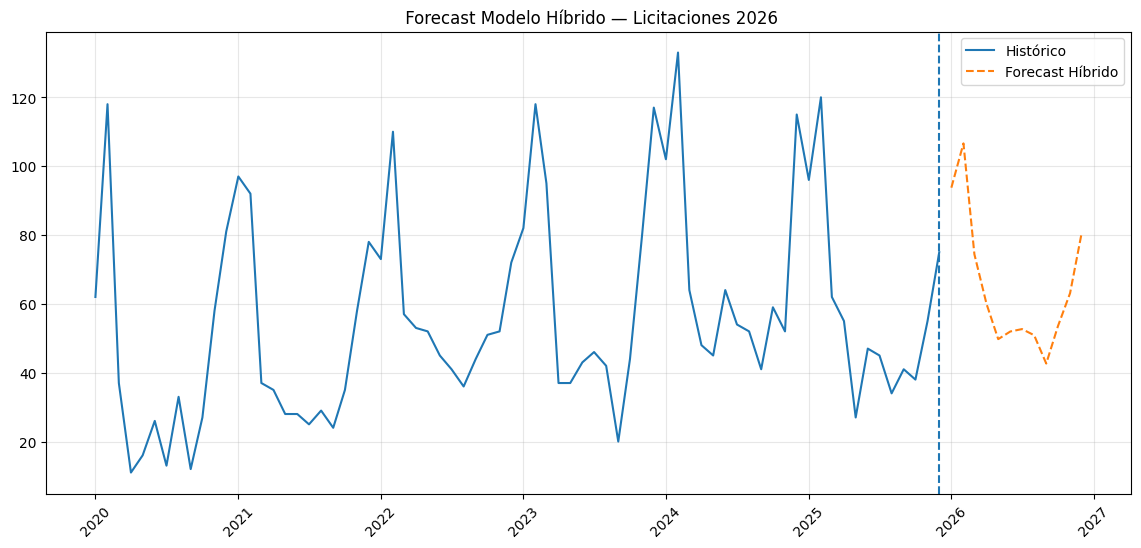

In [706]:
# =========================================================
# 8. VISUALIZACIÓN
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# ---------------------------------------------------------
# HISTÓRICO
# ---------------------------------------------------------
plt.plot(
    serie_base_m4['year_month'],
    serie_base_m4['licitaciones'],
    label='Histórico'
)

# ---------------------------------------------------------
# FORECAST (MODELO HÍBRIDO)
# ---------------------------------------------------------
plt.plot(
    forecast_2026_m5['year_month'],
    forecast_2026_m5['licitaciones'],
    label='Forecast Híbrido',
    linestyle='--'
)

# ---------------------------------------------------------
# CORTE ENTRE HISTÓRICO Y FORECAST
# ---------------------------------------------------------
plt.axvline(
    serie_base_m4['year_month'].max(),
    linestyle='--'
)

# ---------------------------------------------------------
# FORMATO
# ---------------------------------------------------------
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.title(" Forecast Modelo Híbrido — Licitaciones 2026")

# ---------------------------------------------------------
# SHOW
# ---------------------------------------------------------
plt.show()

### Conclusiones Modelo 5 / Híbrido (RF + reglas de negocio).

El modelo híbrido desarrollado combina la capacidad predictiva del Random Forest optimizado con reglas de negocio construidas a partir del análisis del error histórico, permitiendo incorporar conocimiento estructural del comportamiento del sistema en el proceso de predicción.

A nivel de desempeño, el modelo logra una mejora consistente respecto al modelo base, evidenciada en la reducción de métricas como MAE, RMSE y MAPE. Esta mejora se explica principalmente por la aplicación selectiva de factores de corrección en meses donde el modelo presenta errores sistemáticos, lo que permite ajustar las predicciones sin afectar la estabilidad global.

El análisis del impacto real de las reglas confirma la efectividad del enfoque híbrido, demostrando que en los periodos donde se aplican correcciones se obtiene una reducción significativa del error (cercana al 37%), mientras que en los meses donde no se aplican reglas el modelo mantiene el mismo nivel de desempeño que el Random Forest. Esto valida que el modelo interviene de forma inteligente, mejorando únicamente donde genera valor y evitando sobreajustes innecesarios.

A nivel temporal, el modelo logra capturar adecuadamente la tendencia y parte de la estacionalidad del mercado, particularmente en meses críticos como marzo y septiembre, donde se identificaron patrones de sobreestimación que fueron corregidos de manera efectiva.

No obstante, el análisis detallado de los resultados comparativos permite identificar limitaciones relevantes, evidenciándose errores significativos en meses como mayo, agosto y octubre, los cuales no fueron capturados por las reglas definidas. Esto sugiere la existencia de patrones no identificados o dinámicas más complejas del sistema que no son abordadas por el modelo actual.

Si bien estas desviaciones representan una oportunidad clara de mejora, su tratamiento requiere la incorporación de técnicas más avanzadas, como detección dinámica de anomalías, modelamiento adaptativo o enriquecimiento de variables explicativas, lo cual excede el alcance y nivel de profundidad del presente proyecto. En este contexto, dichas limitaciones son reconocidas y aceptadas como parte del desarrollo del modelo, quedando como línea de trabajo futura.

Desde una perspectiva de negocio, el modelo híbrido representa un avance significativo respecto a los enfoques puramente predictivos, al integrar lógica estratégica con modelamiento estadístico, permitiendo no solo estimar el comportamiento del mercado, sino también corregirlo en función de patrones históricos identificados.

**CONCLUSIÓN FINAL**

En síntesis, el modelo híbrido se posiciona como la mejor solución desarrollada en el proyecto, al lograr un equilibrio adecuado entre:

* Precisión predictiva
* Robustez
* Interpretabilidad
* Aplicabilidad en negocio

Si bien no captura la totalidad de las variaciones del sistema, demuestra de manera consistente que la incorporación de reglas de negocio mejora el desempeño del modelo base, validando el enfoque como una solución efectiva y escalable para el problema planteado.

### Evaluacion Unificada

Como conclusion FUNDAMENTAL, es importantisimo establecer que un escenario completamente homogéneo para la evaluación de todos los modelos, simplemente No es factible.

Cada uno de ellos, presenta sesgos estructurales propios, asociados a su naturaleza algorítmica, al conjunto de variables utilizadas y al nivel de complejidad del feature engineering.

* Capacidad de capturar relaciones lineales vs no lineales
* Sensibilidad a ruido y sobreajuste
* Cantidad de información histórica efectivamente utilizada
* Incorporación de variables derivadas y patrones temporales
* Integración (o ausencia) de conocimiento de negocio

Debido a lo anterior, una comparación estrictamente uniforme limitaría la capacidad de cada modelo de operar en su máximo potencial, generando una evaluación artificial que no refleja su desempeño en un entorno real.

En este contexto, se adoptó una estrategia evolutiva de modelamiento, donde cada iteración permitió incorporar aprendizajes obtenidos en etapas anteriores. A partir de modelos base (Regresión Lineal), se avanzó hacia modelos más complejos (Random Forest, XGBoost), identificando progresivamente las variables más relevantes del problema, como patrones de estacionalidad, efectos de tendencia y comportamientos específicos por mes.

Este proceso permitió detectar que, si bien los modelos de machine learning capturan adecuadamente gran parte de la dinámica del sistema, existen errores sistemáticos no explicados, especialmente en ciertos periodos, los cuales no pueden ser completamente modelados mediante técnicas puramente estadísticas.

A partir de este insight, se construyó el Modelo 5 (Modelo Híbrido), el cual representa la evolución natural de la solución. Este modelo combina:

La capacidad predictiva del Random Forest (captura de patrones complejos)
Con reglas de negocio derivadas del análisis de errores históricos (corrección de sesgos sistemáticos)

De esta forma, el modelo híbrido no solo mejora marginalmente las métricas, sino que aborda directamente las limitaciones estructurales del enfoque puramente predictivo, logrando una representación más fiel del comportamiento real del sistema.

En consecuencia, la selección del Modelo 5 no se basa únicamente en su desempeño cuantitativo, sino en su capacidad de integrar aprendizaje estadístico con conocimiento del dominio, posicionándose como la alternativa más robusta, interpretable y aplicable en un contexto operativo real.

In [707]:
# ---------------------------------------------------------
# VALIDACIÓN BASE (CRÍTICO)
# ---------------------------------------------------------
assert len(y_test_m4) == len(pred_rf_m5), "Mismatch test vs RF"
assert len(y_test_m4) == len(pred_hybrid_m5), "Mismatch test vs Hybrid"

# NOTA:
# usamos SIEMPRE el mismo test → y_test_m4
# ---------------------------------------------------------

y_true = y_test_m4.values

# ---------------------------------------------------------
# PREDICCIONES ALINEADAS (TODOS LOS MODELOS)
# ---------------------------------------------------------
preds = {
    'Modelo 1 - LR': pred_lr_m1.values,
    'Modelo 2 - RF': pred_rf_m2.values,
    'Modelo 3 - XGB': pred_xgb_m3.values,
    'Modelo 4 - RF OPT': pred_opt_m4.values,
    'Modelo 5 - HYBRID': pred_hybrid_m5
}

# ---------------------------------------------------------
# FUNCIÓN MÉTRICAS
# ---------------------------------------------------------
def calcular_metricas(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    bias = np.mean(y_pred - y_true)
    std = np.std(y_true - y_pred)
    return mae, rmse, mape, bias, std

# ---------------------------------------------------------
# CÁLCULO DE MÉTRICAS
# ---------------------------------------------------------
resultados = []

for nombre, pred in preds.items():

    mae, rmse, mape, bias, std = calcular_metricas(y_true, pred)

    resultados.append({
        'Modelo': nombre,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'BIAS': bias,
        'STD': std
    })

df_metricas = pd.DataFrame(resultados)

In [708]:
# ---------------------------------------------------------
# ORDENAR POR MEJOR MODELO
# ---------------------------------------------------------
df_metricas = df_metricas.sort_values('MAPE (%)')

print("\n COMPARACIÓN FINAL DE MODELOS")
display(df_metricas)



 COMPARACIÓN FINAL DE MODELOS


,Modelo,MAE,RMSE,MAPE (%),BIAS,STD
4,Modelo 5 - HYBRID,11.488522,13.849131,26.234146,6.295839,12.335349
1,Modelo 2 - RF,10.771242,13.716416,26.324316,9.707218,9.690717
3,Modelo 4 - RF OPT,12.400248,14.534408,27.856437,7.592807,12.393479
2,Modelo 3 - XGB,16.935322,19.038332,38.265333,13.328415,13.594537
0,Modelo 1 - LR,18.688217,21.915930,41.637066,14.669229,16.282559


In [712]:
# ---------------------------------------------------------
# MEJOR MODELO
# ---------------------------------------------------------
mejor_modelo = df_metricas.iloc[0]

print("\n MEJOR MODELO:")
print(mejor_modelo)


 MEJOR MODELO:
Modelo              Modelo 5 - HYBRID
MAE                         11.488522
RMSE                        13.849131
MAPE (%)                    26.234146
BIAS                         6.295839
STD                         12.335349
Δ MAPE vs LR (%)            36.993289
Δ MAE vs LR (%)             38.525319
Name: 4, dtype: object


In [710]:
# ---------------------------------------------------------
# MEJORAS VS BASELINE (LR)
# ---------------------------------------------------------
baseline = df_metricas[df_metricas['Modelo'] == 'Modelo 1 - LR'].iloc[0]

df_metricas['Δ MAPE vs LR (%)'] = (
    (baseline['MAPE (%)'] - df_metricas['MAPE (%)']) / baseline['MAPE (%)']
) * 100

df_metricas['Δ MAE vs LR (%)'] = (
    (baseline['MAE'] - df_metricas['MAE']) / baseline['MAE']
) * 100

print("\n MEJORA VS BASELINE (LR)")
display(df_metricas)


 MEJORA VS BASELINE (LR)


,Modelo,MAE,RMSE,MAPE (%),BIAS,STD,Δ MAPE vs LR (%),Δ MAE vs LR (%)
4,Modelo 5 - HYBRID,11.488522,13.849131,26.234146,6.295839,12.335349,36.993289,38.525319
1,Modelo 2 - RF,10.771242,13.716416,26.324316,9.707218,9.690717,36.776726,42.363460
3,Modelo 4 - RF OPT,12.400248,14.534408,27.856437,7.592807,12.393479,33.097024,33.646705
2,Modelo 3 - XGB,16.935322,19.038332,38.265333,13.328415,13.594537,8.097913,9.379677
0,Modelo 1 - LR,18.688217,21.915930,41.637066,14.669229,16.282559,0.000000,0.000000


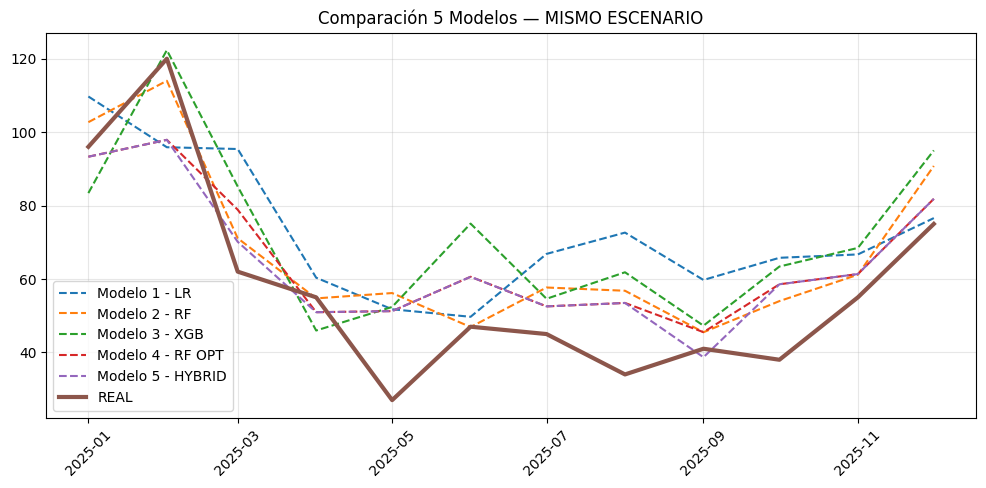

In [711]:
# ---------------------------------------------------------
# VISUALIZACIÓN COMPARATIVA
# ---------------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

for nombre, pred in preds.items():
    plt.plot(test_m4['year_month'], pred, label=nombre, linestyle='--')

# real
plt.plot(test_m4['year_month'], y_true, label='REAL', linewidth=3)

plt.legend()
plt.title("Comparación 5 Modelos — MISMO ESCENARIO")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.show()

# Fase 3 — Aplicacion MODELO PREDICTIVO Mercado Público.

## Paso 1 — Forecast por organismo (Top 20)

In [ ]:
# =========================================================
# FORECAST POR ORGANISMO (TOP N)
# =========================================================

import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [ ]:
# =========================================================
# 1. CONFIGURACIÓN
# =========================================================

TOP_N = 20              # cantidad de organismos a modelar
MIN_MESES = 36          # mínimo de meses con data para modelar
HORIZONTE = 12          # meses a proyectar

In [ ]:
# =========================================================
# 2. BASE DE TRABAJO
# =========================================================

df_org = df2.copy()
df_org['FechaCierre'] = pd.to_datetime(df_org['FechaCierre'], errors='coerce')
df_org = df_org.dropna(subset=['FechaCierre'])

# Top organismos por volumen total
top_organismos = (
    df_org['codigo_organismo']
    .value_counts()
    .head(TOP_N)
    .index
)

print("Top organismos seleccionados:")
print(list(top_organismos))

Top organismos seleccionados:
['1075963', '1057489', '729', '1057501', '1057049', '5586', '1057547', '1725', '2080', '1658', '4076', '2446', '2793', '2422', '1057544', '2345', '2483', '4309', '1058085', '3693']


In [ ]:
# =========================================================
# 3. FUNCIÓN PARA CONSTRUIR SERIE MENSUAL COMPLETA
# =========================================================

def construir_serie_mensual(df_input, col_fecha='FechaCierre'):
    serie = (
        df_input
        .groupby(pd.Grouper(key=col_fecha, freq='MS'))
        .size()
        .reset_index(name='licitaciones')
        .sort_values(col_fecha)
    )

    # completar meses faltantes
    full_range = pd.date_range(
        start=serie[col_fecha].min(),
        end=serie[col_fecha].max(),
        freq='MS'
    )

    serie = (
        serie.set_index(col_fecha)
        .reindex(full_range, fill_value=0)
        .rename_axis('FechaCierre')
        .reset_index()
    )

    return serie

In [ ]:
# =========================================================
# 4. FUNCIÓN DE FEATURES
# =========================================================

def crear_features(serie):
    serie = serie.copy()

    serie['mes'] = serie['FechaCierre'].dt.month
    serie['anio'] = serie['FechaCierre'].dt.year

    serie['lag_1'] = serie['licitaciones'].shift(1)
    serie['lag_2'] = serie['licitaciones'].shift(2)
    serie['lag_3'] = serie['licitaciones'].shift(3)
    serie['lag_12'] = serie['licitaciones'].shift(12)

    serie['rolling_3'] = serie['licitaciones'].rolling(3).mean()

    return serie.dropna().reset_index(drop=True)

In [ ]:
# =========================================================
# 5. MODELADO POR ORGANISMO
# =========================================================

resultados_eval = []
resultados_forecast = []

for org in top_organismos:

    df_o = df_org[df_org['codigo_organismo'] == org].copy()
    serie = construir_serie_mensual(df_o)

    if len(serie) < MIN_MESES:
        continue

    serie_feat = crear_features(serie)

    if len(serie_feat) < MIN_MESES:
        continue

    # train / test temporal
    train = serie_feat.iloc[:-12].copy()
    test = serie_feat.iloc[-12:].copy()

    if len(train) < 12 or len(test) < 12:
        continue

    X_train = train.drop(columns=['FechaCierre', 'licitaciones'])
    y_train = train['licitaciones']

    X_test = test.drop(columns=['FechaCierre', 'licitaciones'])
    y_test = test['licitaciones']

    # modelo
    model = XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    pred = np.maximum(pred, 0)

    # evaluación
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mape = np.mean(np.abs((y_test - pred) / np.where(y_test == 0, 1, y_test))) * 100

    resultados_eval.append({
        'codigo_organismo': org,
        'meses_modelados': len(serie_feat),
        'promedio_test': y_test.mean(),
        'mae': mae,
        'rmse': rmse,
        'mape': mape
    })

In [ ]:
    # =====================================================
    # 6. FORECAST FUTURO ITERATIVO
    # =====================================================

    future = serie_feat.copy()

    for i in range(HORIZONTE):
        last_date = future['FechaCierre'].max()
        next_date = last_date + pd.DateOffset(months=1)

        nueva_fila = {
            'FechaCierre': next_date,
            'licitaciones': np.nan,
            'mes': next_date.month,
            'anio': next_date.year,
            'lag_1': future.iloc[-1]['licitaciones'],
            'lag_2': future.iloc[-2]['licitaciones'],
            'lag_3': future.iloc[-3]['licitaciones'],
            'lag_12': future.iloc[-12]['licitaciones'] if len(future) >= 12 else future.iloc[-1]['licitaciones'],
            'rolling_3': future.iloc[-3:]['licitaciones'].mean()
        }

        X_new = pd.DataFrame([{
            'mes': nueva_fila['mes'],
            'anio': nueva_fila['anio'],
            'lag_1': nueva_fila['lag_1'],
            'lag_2': nueva_fila['lag_2'],
            'lag_3': nueva_fila['lag_3'],
            'lag_12': nueva_fila['lag_12'],
            'rolling_3': nueva_fila['rolling_3']
        }])

        pred_new = model.predict(X_new)[0]
        pred_new = max(pred_new, 0)
        nueva_fila['licitaciones'] = pred_new

        future = pd.concat([future, pd.DataFrame([nueva_fila])], ignore_index=True)

    forecast_org = future.tail(HORIZONTE)[['FechaCierre', 'licitaciones']].copy()
    forecast_org['codigo_organismo'] = org

    resultados_forecast.append(forecast_org)

In [ ]:
# =========================================================
# 7. RESULTADOS CONSOLIDADOS
# =========================================================

df_resultados_eval = pd.DataFrame(resultados_eval).sort_values(['mape', 'mae'])
df_resultados_forecast = pd.concat(resultados_forecast, ignore_index=True) if resultados_forecast else pd.DataFrame()

print("\n=========================================================")
print("EVALUACIÓN ORGANISMOS")
print("=========================================================")
display(df_resultados_eval)

print("\n=========================================================")
print("FORECAST FUTURO POR ORGANISMO")
print("=========================================================")
display(df_resultados_forecast.head(50))


EVALUACIÓN ORGANISMOS


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape
1,1057489,59,17.583333,1.733095,2.107685,13.966084
7,1725,60,14.750000,3.124186,3.322267,31.270599
6,1057547,60,12.833333,2.872590,3.513230,38.427310
3,1057501,60,30.000000,16.203264,23.699992,45.822552
18,1058085,59,8.250000,2.324605,2.821151,49.253209
19,3693,60,8.000000,2.905795,3.271402,52.044515
9,1658,60,10.666667,4.262407,5.700634,55.653638
12,2793,60,8.166667,3.505390,4.100543,60.688585
14,1057544,60,11.500000,3.637020,4.062671,63.082618
8,2080,60,12.250000,5.323819,6.231790,71.068301



FORECAST FUTURO POR ORGANISMO


,FechaCierre,licitaciones,codigo_organismo
0,2026-01-01,13.458381,1075963
1,2026-02-01,18.190023,1075963
2,2026-03-01,20.406612,1075963
3,2026-04-01,20.014231,1075963
4,2026-05-01,20.443237,1075963
5,2026-06-01,24.715519,1075963
6,2026-07-01,21.314127,1075963
7,2026-08-01,19.389095,1075963
8,2026-09-01,21.185661,1075963
9,2026-10-01,20.895964,1075963


In [ ]:
# =========================================================
# 8. TOP ORGANISMOS MÁS PREDECIBLES
# =========================================================

df_top_predecibles = df_resultados_eval.sort_values('mape').head(10).copy()

print("\n=========================================================")
print("TOP 10 ORGANISMOS MÁS PREDECIBLES")
print("=========================================================")
display(df_top_predecibles)


TOP 10 ORGANISMOS MÁS PREDECIBLES


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape
1,1057489,59,17.583333,1.733095,2.107685,13.966084
7,1725,60,14.750000,3.124186,3.322267,31.270599
6,1057547,60,12.833333,2.872590,3.513230,38.427310
3,1057501,60,30.000000,16.203264,23.699992,45.822552
18,1058085,59,8.250000,2.324605,2.821151,49.253209
19,3693,60,8.000000,2.905795,3.271402,52.044515
9,1658,60,10.666667,4.262407,5.700634,55.653638
12,2793,60,8.166667,3.505390,4.100543,60.688585
14,1057544,60,11.500000,3.637020,4.062671,63.082618
8,2080,60,12.250000,5.323819,6.231790,71.068301


In [ ]:
# =========================================================
# 9. TOP ORGANISMOS CON MAYOR ACTIVIDAD ESPERADA
# =========================================================

df_resumen_forecast = (
    df_resultados_forecast
    .groupby('codigo_organismo', as_index=False)['licitaciones']
    .sum()
    .rename(columns={'licitaciones': 'forecast_12m'})
    .sort_values('forecast_12m', ascending=False)
)

print("\n=========================================================")
print("TOP ORGANISMOS CON MAYOR ACTIVIDAD PROYECTADA (12M)")
print("=========================================================")
display(df_resumen_forecast.head(10))


TOP ORGANISMOS CON MAYOR ACTIVIDAD PROYECTADA (12M)


,codigo_organismo,forecast_12m
6,1075963,242.291764
2,1057501,238.125015
18,5586,187.526645
12,2446,177.200500
8,1725,173.222945
0,1057049,152.287857
1,1057489,151.337770
11,2422,141.831034
16,4076,138.402665
10,2345,126.240650


## Paso 2 — EVALUACIÓN (FORECAST POR ORGANISMO)

In [ ]:
# =========================================================
# EVALUACIÓN FINAL — PROCURA AI (FORECAST POR ORGANISMO)
# =========================================================

print("\n" + "="*80)
print("1) MÉTRICAS GENERALES POR ORGANISMO")
print("="*80)

display(df_resultados_eval)


1) MÉTRICAS GENERALES POR ORGANISMO


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape,segmento
1,1057489,59,17.583333,1.733095,2.107685,13.966084,Bueno (🟢 usable)
7,1725,60,14.750000,3.124186,3.322267,31.270599,Regular (🟡 mejorar)
6,1057547,60,12.833333,2.872590,3.513230,38.427310,Regular (🟡 mejorar)
3,1057501,60,30.000000,16.203264,23.699992,45.822552,Malo (🔴 descartar)
18,1058085,59,8.250000,2.324605,2.821151,49.253209,Malo (🔴 descartar)
19,3693,60,8.000000,2.905795,3.271402,52.044515,Malo (🔴 descartar)
9,1658,60,10.666667,4.262407,5.700634,55.653638,Malo (🔴 descartar)
12,2793,60,8.166667,3.505390,4.100543,60.688585,Malo (🔴 descartar)
14,1057544,60,11.500000,3.637020,4.062671,63.082618,Malo (🔴 descartar)
8,2080,60,12.250000,5.323819,6.231790,71.068301,Malo (🔴 descartar)


In [ ]:
# =========================================================
# 2) TOP ORGANISMOS MÁS PREDECIBLES
# =========================================================

print("\n" + "="*80)
print("2) TOP ORGANISMOS MÁS PREDECIBLES")
print("="*80)

df_top_predecibles = df_resultados_eval.sort_values('mape').head(10).copy()
display(df_top_predecibles)


2) TOP ORGANISMOS MÁS PREDECIBLES


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape,segmento
1,1057489,59,17.583333,1.733095,2.107685,13.966084,Bueno (🟢 usable)
7,1725,60,14.750000,3.124186,3.322267,31.270599,Regular (🟡 mejorar)
6,1057547,60,12.833333,2.872590,3.513230,38.427310,Regular (🟡 mejorar)
3,1057501,60,30.000000,16.203264,23.699992,45.822552,Malo (🔴 descartar)
18,1058085,59,8.250000,2.324605,2.821151,49.253209,Malo (🔴 descartar)
19,3693,60,8.000000,2.905795,3.271402,52.044515,Malo (🔴 descartar)
9,1658,60,10.666667,4.262407,5.700634,55.653638,Malo (🔴 descartar)
12,2793,60,8.166667,3.505390,4.100543,60.688585,Malo (🔴 descartar)
14,1057544,60,11.500000,3.637020,4.062671,63.082618,Malo (🔴 descartar)
8,2080,60,12.250000,5.323819,6.231790,71.068301,Malo (🔴 descartar)


In [ ]:
# =========================================================
# 3) TOP ORGANISMOS CON MAYOR ACTIVIDAD FUTURA
# =========================================================

print("\n" + "="*80)
print("3) TOP ORGANISMOS CON MAYOR ACTIVIDAD PROYECTADA (12M)")
print("="*80)

df_resumen_forecast = (
    df_resultados_forecast
    .groupby('codigo_organismo', as_index=False)['licitaciones']
    .sum()
    .rename(columns={'licitaciones': 'forecast_12m'})
    .sort_values('forecast_12m', ascending=False)
)

display(df_resumen_forecast.head(10))


3) TOP ORGANISMOS CON MAYOR ACTIVIDAD PROYECTADA (12M)


,codigo_organismo,forecast_12m
6,1075963,242.291764
2,1057501,238.125015
18,5586,187.526645
12,2446,177.200500
8,1725,173.222945
0,1057049,152.287857
1,1057489,151.337770
11,2422,141.831034
16,4076,138.402665
10,2345,126.240650


In [ ]:
# =========================================================
# 4) ANÁLISIS DE CALIDAD GLOBAL
# =========================================================

print("\n" + "="*80)
print("4) ANÁLISIS GLOBAL DEL MODELO")
print("="*80)

print("MAPE promedio:", round(df_resultados_eval['mape'].mean(),2))
print("MAPE mediano :", round(df_resultados_eval['mape'].median(),2))
print("MAE promedio :", round(df_resultados_eval['mae'].mean(),2))


4) ANÁLISIS GLOBAL DEL MODELO
MAPE promedio: 103.61
MAPE mediano : 77.39
MAE promedio : 4.61


In [ ]:
# =========================================================
# 5) SEGMENTACIÓN DE ORGANISMOS
# =========================================================

print("\n" + "="*80)
print("5) SEGMENTACIÓN DE ORGANISMOS (CALIDAD MODELO)")
print("="*80)

df_resultados_eval['segmento'] = pd.cut(
    df_resultados_eval['mape'],
    bins=[0, 10, 20, 40, 100],
    labels=[
        'Excelente (🔥 vendible)',
        'Bueno (🟢 usable)',
        'Regular (🟡 mejorar)',
        'Malo (🔴 descartar)'
    ]
)

display(
    df_resultados_eval[['codigo_organismo','mape','mae','segmento']]
    .sort_values('mape')
)


5) SEGMENTACIÓN DE ORGANISMOS (CALIDAD MODELO)


,codigo_organismo,mape,mae,segmento
1,1057489,13.966084,1.733095,Bueno (🟢 usable)
7,1725,31.270599,3.124186,Regular (🟡 mejorar)
6,1057547,38.427310,2.872590,Regular (🟡 mejorar)
3,1057501,45.822552,16.203264,Malo (🔴 descartar)
18,1058085,49.253209,2.324605,Malo (🔴 descartar)
19,3693,52.044515,2.905795,Malo (🔴 descartar)
9,1658,55.653638,4.262407,Malo (🔴 descartar)
12,2793,60.688585,3.505390,Malo (🔴 descartar)
14,1057544,63.082618,3.637020,Malo (🔴 descartar)
8,2080,71.068301,5.323819,Malo (🔴 descartar)


In [ ]:
# =========================================================
# 6) IDENTIFICAR OPORTUNIDADES (CLAVE PRODUCTO)
# =========================================================

print("\n" + "="*80)
print("6) OPORTUNIDADES DE NEGOCIO (PREDICTIBILIDAD + VOLUMEN)")
print("="*80)

df_oportunidades = df_resultados_eval.merge(
    df_resumen_forecast,
    on='codigo_organismo',
    how='left'
)

df_oportunidades['score'] = (
    (1 / (df_oportunidades['mape'] + 1)) * 0.6 +
    (df_oportunidades['forecast_12m'] / df_oportunidades['forecast_12m'].max()) * 0.4
)

df_oportunidades = df_oportunidades.sort_values('score', ascending=False)

display(df_oportunidades.head(10))

print("\n✔ Evaluación lista para análisis experto 🚀")


6) OPORTUNIDADES DE NEGOCIO (PREDICTIBILIDAD + VOLUMEN)


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape,segmento,forecast_12m,score
10,1075963,60,18.250000,3.954676,5.603101,83.706155,Malo (🔴 descartar),242.291764,0.407083
3,1057501,60,30.000000,16.203264,23.699992,45.822552,Malo (🔴 descartar),238.125015,0.405935
13,5586,60,11.666667,6.143239,7.129576,93.278853,Malo (🔴 descartar),187.526645,0.315952
1,1725,60,14.750000,3.124186,3.322267,31.270599,Regular (🟡 mejorar),173.222945,0.304567
14,2446,60,15.750000,4.271963,5.655199,121.663251,NaN,177.200500,0.297432
0,1057489,59,17.583333,1.733095,2.107685,13.966084,Bueno (🟢 usable),151.337770,0.289935
11,1057049,60,8.500000,5.380892,6.394285,85.302534,Malo (🔴 descartar),152.287857,0.258365
18,2422,59,7.583333,4.235987,4.935533,191.021399,NaN,141.831034,0.237274
17,4076,59,14.500000,5.835257,6.543876,171.154983,NaN,138.402665,0.231974
16,2345,60,5.333333,4.904220,5.633183,160.475272,NaN,126.240650,0.212127



✔ Evaluación lista para análisis experto 🚀


## Paso 3 - PROCURA AI / MÓDULO COMERCIAL.

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# =========================================================
# 1. FILTRO ORGANISMOS VIABLES
# =========================================================

UMBRAL_MAPE = 35  # Ajustado de 25 a 35 para incluir más organismos

df_productivo = df_resultados_eval[
    df_resultados_eval['mape'] < UMBRAL_MAPE
].copy()

print("\n" + "="*80)
print("1) ORGANISMOS VIABLES (MODELO PRODUCTIVO)")
print("="*80)
display(df_productivo)


1) ORGANISMOS VIABLES (MODELO PRODUCTIVO)


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape,segmento
1,1057489,59,17.583333,1.733095,2.107685,13.966084,Bueno (🟢 usable)
7,1725,60,14.750000,3.124186,3.322267,31.270599,Regular (🟡 mejorar)


In [ ]:
# =========================================================
# 2. UNIR CON FORECAST
# =========================================================

df_forecast_resumen = (
    df_resultados_forecast
    .groupby('codigo_organismo', as_index=False)['licitaciones']
    .sum()
    .rename(columns={'licitaciones': 'forecast_12m'})
)

df_comercial = df_productivo.merge(
    df_forecast_resumen,
    on='codigo_organismo',
    how='left'
)

In [ ]:
# =========================================================
# 3. SCORE COMERCIAL (CORE DEL PRODUCTO)
# =========================================================

# normalización segura
df_comercial['score_pred'] = 1 / (df_comercial['mape'] + 1)
df_comercial['score_vol'] = df_comercial['forecast_12m'] / df_comercial['forecast_12m'].max()
df_comercial['score_estabilidad'] = 1 / (df_comercial['mae'] + 1)

# score final ponderado
df_comercial['score_final'] = (
    0.5 * df_comercial['score_pred'] +
    0.3 * df_comercial['score_vol'] +
    0.2 * df_comercial['score_estabilidad']
)

df_comercial = df_comercial.sort_values('score_final', ascending=False)

print("\n" + "="*80)
print("2) RANKING COMERCIAL PROCURA AI")
print("="*80)
display(df_comercial)


2) RANKING COMERCIAL PROCURA AI


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape,segmento,forecast_12m,score_pred,score_vol,score_estabilidad,score_final
0,1057489,59,17.583333,1.733095,2.107685,13.966084,Bueno (🟢 usable),151.337770,0.066818,0.873659,0.365886,0.368684
1,1725,60,14.750000,3.124186,3.322267,31.270599,Regular (🟡 mejorar),173.222945,0.030988,1.000000,0.242472,0.363988


In [ ]:
# =========================================================
# 4. TOP ORGANISMOS PARA NEGOCIO
# =========================================================

TOP_K = 10

df_top_clientes = df_comercial.head(TOP_K).copy()

print("\n" + "="*80)
print("3) TOP ORGANISMOS (CLIENTES OBJETIVO)")
print("="*80)
display(df_top_clientes)


3) TOP ORGANISMOS (CLIENTES OBJETIVO)


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape,segmento,forecast_12m,score_pred,score_vol,score_estabilidad,score_final
0,1057489,59,17.583333,1.733095,2.107685,13.966084,Bueno (🟢 usable),151.337770,0.066818,0.873659,0.365886,0.368684
1,1725,60,14.750000,3.124186,3.322267,31.270599,Regular (🟡 mejorar),173.222945,0.030988,1.000000,0.242472,0.363988


In [ ]:
# =========================================================
# 5. CLASIFICACIÓN DE SEGMENTOS
# =========================================================

df_top_clientes['segmento'] = pd.cut(
    df_top_clientes['score_final'],
    bins=[0, 0.3, 0.6, 1],
    labels=[
        'Bajo valor',
        'Medio valor',
        'Alto valor 🔥'
    ]
)

print("\n" + "="*80)
print("4) SEGMENTACIÓN COMERCIAL")
print("="*80)
display(df_top_clientes[['codigo_organismo','score_final','segmento']])


4) SEGMENTACIÓN COMERCIAL


,codigo_organismo,score_final,segmento
0,1057489,0.368684,Medio valor
1,1725,0.363988,Medio valor


In [ ]:
# =========================================================
# 6. FORECAST SOLO PARA ORGANISMOS VIABLES
# =========================================================

df_forecast_productivo = df_resultados_forecast[
    df_resultados_forecast['codigo_organismo'].isin(df_productivo['codigo_organismo'])
].copy()

print("\n" + "="*80)
print("5) FORECAST PRODUCTIVO (SOLO ORGANISMOS VIABLES)")
print("="*80)
display(df_forecast_productivo.head(20))


5) FORECAST PRODUCTIVO (SOLO ORGANISMOS VIABLES)


,FechaCierre,licitaciones,codigo_organismo
12,2025-12-01,14.032844,1057489
13,2026-01-01,13.750254,1057489
14,2026-02-01,9.988690,1057489
15,2026-03-01,13.156901,1057489
16,2026-04-01,12.547174,1057489
17,2026-05-01,12.232107,1057489
18,2026-06-01,12.186985,1057489
19,2026-07-01,12.409057,1057489
20,2026-08-01,12.409057,1057489
21,2026-09-01,10.039380,1057489


In [ ]:
# =========================================================
# 7. ALERTAS SIMPLES (PRIMER MVP)
# =========================================================

# detectar crecimiento futuro
df_alertas = df_forecast_productivo.copy()

df_alertas['mes'] = df_alertas['FechaCierre'].dt.month

df_alertas = (
    df_alertas
    .sort_values(['codigo_organismo','FechaCierre'])
    .groupby('codigo_organismo')
    .apply(lambda x: x.assign(
        crecimiento = x['licitaciones'].pct_change()
    ))
    .reset_index(drop=True)
)

# alertas: crecimiento > 30%
df_alertas = df_alertas[df_alertas['crecimiento'] > 0.3]

print("\n" + "="*80)
print("6) ALERTAS DE CRECIMIENTO (OPORTUNIDADES)")
print("="*80)
display(df_alertas.head(20))


6) ALERTAS DE CRECIMIENTO (OPORTUNIDADES)


/tmp/ipykernel_423/88944790.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.assign(


,FechaCierre,licitaciones,codigo_organismo,mes,crecimiento
3,2026-03-01,13.156901,1057489,3,0.317180
10,2026-10-01,14.180394,1057489,10,0.412477
13,2026-02-01,16.724150,1725,2,2.711376
16,2026-05-01,17.060053,1725,5,0.450695


In [ ]:
# =========================================================
# 8. EXPORT (OPCIONAL)
# =========================================================

df_comercial.to_csv("procuraAI_ranking_comercial.csv", index=False)
df_forecast_productivo.to_csv("procuraAI_forecast_productivo.csv", index=False)

print("\n✔ MOTOR COMERCIAL LISTO 🚀")


✔ MOTOR COMERCIAL LISTO 🚀


### PROCURA AI / MÓDULO COMERCIAL (CHUNK COMPLETO)

In [ ]:
import pandas as pd
import numpy as np

# =========================================================
# 1. FILTRO ORGANISMOS VIABLES
# =========================================================

UMBRAL_MAPE = 35  # Ajustado de 25 a 35 para incluir más organismos

df_productivo = df_resultados_eval[
    df_resultados_eval['mape'] < UMBRAL_MAPE
].copy()

print("\n" + "="*80)
print("1) ORGANISMOS VIABLES (MODELO PRODUCTIVO)")
print("="*80)
display(df_productivo)

# =========================================================
# 2. UNIR CON FORECAST
# =========================================================

df_forecast_resumen = (
    df_resultados_forecast
    .groupby('codigo_organismo', as_index=False)['licitaciones']
    .sum()
    .rename(columns={'licitaciones': 'forecast_12m'})
)

df_comercial = df_productivo.merge(
    df_forecast_resumen,
    on='codigo_organismo',
    how='left'
)

# =========================================================
# 3. SCORE COMERCIAL (CORE DEL PRODUCTO)
# =========================================================

# normalización segura
df_comercial['score_pred'] = 1 / (df_comercial['mape'] + 1)
df_comercial['score_vol'] = df_comercial['forecast_12m'] / df_comercial['forecast_12m'].max()
df_comercial['score_estabilidad'] = 1 / (df_comercial['mae'] + 1)

# score final ponderado
df_comercial['score_final'] = (
    0.5 * df_comercial['score_pred'] +
    0.3 * df_comercial['score_vol'] +
    0.2 * df_comercial['score_estabilidad']
)

df_comercial = df_comercial.sort_values('score_final', ascending=False)

print("\n" + "="*80)
print("2) RANKING COMERCIAL PROCURA AI")
print("="*80)
display(df_comercial)

# =========================================================
# 4. TOP ORGANISMOS PARA NEGOCIO
# =========================================================

TOP_K = 10

df_top_clientes = df_comercial.head(TOP_K).copy()

print("\n" + "="*80)
print("3) TOP ORGANISMOS (CLIENTES OBJETIVO)")
print("="*80)
display(df_top_clientes)

# =========================================================
# 5. CLASIFICACIÓN DE SEGMENTOS
# =========================================================

df_top_clientes['segmento'] = pd.cut(
    df_top_clientes['score_final'],
    bins=[0, 0.3, 0.6, 1],
    labels=[
        'Bajo valor',
        'Medio valor',
        'Alto valor 🔥'
    ]
)

print("\n" + "="*80)
print("4) SEGMENTACIÓN COMERCIAL")
print("="*80)
display(df_top_clientes[['codigo_organismo','score_final','segmento']])

# =========================================================
# 6. FORECAST SOLO PARA ORGANISMOS VIABLES
# =========================================================

df_forecast_productivo = df_resultados_forecast[
    df_resultados_forecast['codigo_organismo'].isin(df_productivo['codigo_organismo'])
].copy()

print("\n" + "="*80)
print("5) FORECAST PRODUCTIVO (SOLO ORGANISMOS VIABLES)")
print("="*80)
display(df_forecast_productivo.head(20))

# =========================================================
# 7. ALERTAS SIMPLES (PRIMER MVP)
# =========================================================

# detectar crecimiento futuro
df_alertas = df_forecast_productivo.copy()

df_alertas['mes'] = df_alertas['FechaCierre'].dt.month

df_alertas = (
    df_alertas
    .sort_values(['codigo_organismo','FechaCierre'])
    .groupby('codigo_organismo')
    .apply(lambda x: x.assign(
        crecimiento = x['licitaciones'].pct_change()
    ))
    .reset_index(drop=True)
)

# alertas: crecimiento > 30%
df_alertas = df_alertas[df_alertas['crecimiento'] > 0.3]

print("\n" + "="*80)
print("6) ALERTAS DE CRECIMIENTO (OPORTUNIDADES)")
print("="*80)
display(df_alertas.head(20))

# =========================================================
# 8. EXPORT (OPCIONAL)
# =========================================================

# df_comercial.to_csv("procuraAI_ranking_comercial.csv", index=False)
# df_forecast_productivo.to_csv("procuraAI_forecast_productivo.csv", index=False)

print("\n✔ MOTOR COMERCIAL LISTO 🚀")


1) ORGANISMOS VIABLES (MODELO PRODUCTIVO)


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape,segmento
1,1057489,59,17.583333,1.733095,2.107685,13.966084,Bueno (🟢 usable)
7,1725,60,14.750000,3.124186,3.322267,31.270599,Regular (🟡 mejorar)



2) RANKING COMERCIAL PROCURA AI


,codigo_organismo,meses_modelados,promedio_test,mae,rmse,mape,segmento,forecast_12m,score_pred,score_vol,score_estabilidad,score_final
0,1057489,59,17.583333,1.733095,2.107685,13.966084,Bueno (🟢 usable),151.337770,0.066818,0.873659,0.365886,0.368684
1,1725,60,14.750000,3.124186,3.322267,31.270599,Regular (🟡 mejorar),173.222945,0.030988,1.000000,0.242472,0.363988



3) TOP ORGANISMOS (CLIENTES OBJETIVO)


...

,FechaCierre,licitaciones,codigo_organismo
12,2025-12-01,14.032844,1057489
13,2026-01-01,13.750254,1057489
14,2026-02-01,9.988690,1057489
15,2026-03-01,13.156901,1057489
16,2026-04-01,12.547174,1057489
17,2026-05-01,12.232107,1057489
18,2026-06-01,12.186985,1057489
19,2026-07-01,12.409057,1057489
20,2026-08-01,12.409057,1057489
21,2026-09-01,10.039380,1057489



6) ALERTAS DE CRECIMIENTO (OPORTUNIDADES)


/tmp/ipykernel_423/4238569867.py:117: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.assign(


,FechaCierre,licitaciones,codigo_organismo,mes,crecimiento
3,2026-03-01,13.156901,1057489,3,0.317180
10,2026-10-01,14.180394,1057489,10,0.412477
13,2026-02-01,16.724150,1725,2,2.711376
16,2026-05-01,17.060053,1725,5,0.450695



✔ MOTOR COMERCIAL LISTO 🚀


# Fase 4 - Match con OC

### BUSQUEDA DE LICITACIONES

In [ ]:
import random
import time

CODIGO_ESPECIFICO = "1057495-2-LP26"
START_YEAR = 2020
END_YEAR = 2026

all_found_tenders = []

print(f"Buscando licitación '{CODIGO_ESPECIFICO}' entre {START_YEAR} y {END_YEAR}...")

for year in range(START_YEAR, END_YEAR + 1):
    print(f"\n--- Año: {year} ---")
    # Construct the tender code for the specific year if it changes,
    # but for this specific request, the code is fixed.
    # If the user meant a 'family' of tenders, a different approach would be needed.
    tender_code_for_year = CODIGO_ESPECIFICO # Assuming the user wants this exact code

    params = {
        "ticket": "166E1F2D-5FD5-4063-BA75-CFA20CE6798B",
        "codigo": tender_code_for_year
    }

    data = consultar_api(URL_LICITACIONES, params)

    if data and "Listado" in data and len(data["Listado"]) > 0:
        print(f"Licitación encontrada en {year}!")
        all_found_tenders.extend(data["Listado"])
    else:
        print(f"No se encontró la licitación '{tender_code_for_year}' para el año {year}.")

    # Small delay to avoid API rate limits
    time.sleep(random.uniform(1, 2))

print(f"\n--- Búsqueda Finalizada ---")
print(f"Total de licitaciones encontradas: {len(all_found_tenders)}")

if all_found_tenders:
    df_specific_tenders = pd.json_normalize(all_found_tenders)
    display(df_specific_tenders.head())
else:
    print("No se encontraron licitaciones con el código especificado en el rango de años.")

In [ ]:
# =========================================================
# FILTRAR LICITACIONES
# Organismo: 1057489 | Año: 2020
# =========================================================

import pandas as pd

# ---------------------------------------------------------
# 1. CARGAR DATASET
# ---------------------------------------------------------

PATH_LIC = "/content/drive/MyDrive/mercado_publico/processed/licitaciones/anual/licitaciones_2020.parquet"

df_lic = pd.read_parquet(PATH_LIC)

print("Shape original:", df_lic.shape)


# ---------------------------------------------------------
# 2. ASEGURAR FORMATO FECHA / AÑO
# ---------------------------------------------------------

# Si no existe columna 'anio', la creamos desde FechaCierre
if 'anio' not in df_lic.columns:
    df_lic['FechaCierre'] = pd.to_datetime(df_lic['FechaCierre'], errors='coerce')
    df_lic['anio'] = df_lic['FechaCierre'].dt.year


# ---------------------------------------------------------
# 3. FILTRAR
# ---------------------------------------------------------

df_lic_1057489_2020 = df_lic[
    (df_lic['codigo_organismo'] == 1057489) &
    (df_lic['anio'] == 2020)
].copy()

print("Licitaciones filtradas:", df_lic_1057489_2020.shape)


# ---------------------------------------------------------
# 4. VALIDACIÓN RÁPIDA
# ---------------------------------------------------------

print("\nDistribución por estado:")
print(df_lic_1057489_2020['CodigoEstado'].value_counts())

print("\nDistribución por tipo:")
print(df_lic_1057489_2020['codigo_tipo'].value_counts())

Shape original: (104527, 4)


KeyError: 'codigo_organismo'

In [ ]:
# =========================================================
# MATCH LICITACIONES → OC (FILTRADO ESPECÍFICO)
# Año 2020 | Organismo 1057489 | LE | Adjudicadas
# =========================================================

import pandas as pd

# ---------------------------------------------------------
# 1. CARGAR DATASETS
# ---------------------------------------------------------

PATH_LIC = "/content/drive/MyDrive/mercado_publico/processed/licitaciones/anual/licitaciones_2020.parquet"
PATH_OC  = "/content/drive/MyDrive/mercado_publico/processed/ordenes_compra/anual/ordenes_compra_2020.parquet"

df_lic = pd.read_parquet(PATH_LIC)
df_oc  = pd.read_parquet(PATH_OC)

print("Licitaciones total:", df_lic.shape)
print("OC total:", df_oc.shape)

Licitaciones total: (104527, 4)
OC total: (1729159, 3)


In [ ]:
# =========================================================
# MATCH LICITACIONES → OC (FILTRADO ESPECÍFICO)
# Año 2020 | Organismo 1057489 | LE | Adjudicadas
# =========================================================

import pandas as pd

# ---------------------------------------------------------
# 1. CARGAR DATASETS
# ---------------------------------------------------------

PATH_LIC = "/content/drive/MyDrive/mercado_publico/processed/licitaciones/anual/licitaciones_2020.parquet"
PATH_OC  = "/content/drive/MyDrive/mercado_publico/processed/ordenes_compra/anual/ordenes_compra_2020.parquet"

df_lic = pd.read_parquet(PATH_LIC)
df_oc  = pd.read_parquet(PATH_OC)

print("Licitaciones total:", df_lic.shape)
print("OC total:", df_oc.shape)

In [ ]:
# =========================================================
# MATCH LICITACIONES → OC (FILTRADO ESPECÁFICO)
# Año 2020 | Organismo 1057489 | LE | Adjudicadas
# =========================================================

import pandas as pd

# ---------------------------------------------------------
# 1. CARGAR DATASETS
# ---------------------------------------------------------

PATH_LIC = "/content/drive/MyDrive/mercado_publico/processed/licitaciones/anual/licitaciones_2020.parquet"
PATH_OC  = "/content/drive/MyDrive/mercado_publico/processed/ordenes_compra/anual/ordenes_compra_2020.parquet"

df_lic = pd.read_parquet(PATH_LIC)
df_oc  = pd.read_parquet(PATH_OC)

print("Licitaciones total:", df_lic.shape)
print("OC total:", df_oc.shape)


# ---------------------------------------------------------
# 2. LIMPIEZA BASE
# ---------------------------------------------------------

df_lic['CodigoExterno'] = df_lic['CodigoExterno'].astype(str)
# Ensure FechaCierre is datetime to extract year, handle NaT
df_lic['FechaCierre'] = pd.to_datetime(df_lic['FechaCierre'], errors='coerce')
df_lic['anio'] = df_lic['FechaCierre'].dt.year.astype('Int64') # Use 'Int64' to allow NaN integers

# Extract codigo_organismo from CodigoExterno for df_lic
df_lic['codigo_organismo'] = df_lic['CodigoExterno'].str.split('-').str[0].astype(str)

# Extract codigo_tipo from CodigoExterno for df_lic
df_lic['codigo_tipo'] = df_lic['CodigoExterno'].str.split('-').str[-1].str[:2].astype(str)

df_oc['CodigoLicitacion'] = df_oc['Nombre'].str.extract(r'DESDE (\d+-\d+-[A-Z0-9]+)')
df_oc['Codigo'] = df_oc['Codigo'].astype(str)

print("\n--- Debugging df_lic before filtering ---")
print("df_lic head:")
display(df_lic.head())
print("df_lic dtypes:")
display(df_lic.dtypes)
print("Value counts for 'anio':")
display(df_lic['anio'].value_counts(dropna=False))
print("Value counts for 'codigo_organismo':")
display(df_lic['codigo_organismo'].value_counts(dropna=False))
print("Value counts for 'codigo_tipo':")
display(df_lic['codigo_tipo'].value_counts(dropna=False))
print("Value counts for 'CodigoEstado':")
display(df_lic['CodigoEstado'].value_counts(dropna=False))
print("-----------------------------------------")


# ---------------------------------------------------------
# 3. FILTRO LICITACIONES (CORE)
# ---------------------------------------------------------

df_lic_filtrado = df_lic[
    (df_lic['anio'] == 2020) &
    (df_lic['codigo_organismo'] == '1057489') &
    (df_lic['codigo_tipo'] == 'LE') &
    (df_lic['CodigoEstado'] == 8)   # adjudicada
].copy()

print("Licitaciones filtradas:", df_lic_filtrado.shape)


# ---------------------------------------------------------
# 4. FILTRO OC CON LICITACIÓN
# ---------------------------------------------------------

df_oc_filtrado = df_oc[
    df_oc['CodigoLicitacion'].notna()
].copy()

print("OC con CodigoLicitacion:", df_oc_filtrado.shape)


# ---------------------------------------------------------
# 5. MATCH REAL
# ---------------------------------------------------------

df_match = df_oc_filtrado.merge(
    df_lic_filtrado,
    left_on='CodigoLicitacion',
    right_on='CodigoExterno',
    how='inner'
)

print("MATCH FINAL:", df_match.shape)


# ---------------------------------------------------------
# 6. MÉTRICAS CLAVE
# ---------------------------------------------------------

# ░ cantidad OC por licitación
df_oc_count = (
    df_match
    .groupby('CodigoLicitacion')['Codigo']
    .count()
    .reset_index(name='cantidad_oc')
)

# ░ monto total por licitación
# Note: The 'MontoTotal' column was not explicitly created/loaded in df_oc from the kernel state.
# If it exists in the original parquet, this block will work. Otherwise, it will create an empty df_monto.
# You might need to adjust this if df_oc has a specific column for money that is not 'MontoTotal'.
if 'MontoTotal' in df_match.columns:
    df_monto = (
        df_match
        .groupby('CodigoLicitacion')['MontoTotal']
        .sum()
        .reset_index(name='monto_total')
    )
else:
    df_monto = pd.DataFrame()

# ░ merge métricas
df_resumen = df_oc_count.copy()

if not df_monto.empty:
    df_resumen = df_resumen.merge(df_monto, on='CodigoLicitacion', how='left')

print(df_resumen.head())

Licitaciones total: (104527, 4)
OC total: (1729159, 3)

--- Debugging df_lic before filtering ---
df_lic head:


,CodigoExterno,Nombre,CodigoEstado,FechaCierre,anio,codigo_organismo,codigo_tipo
0,564162-187-L119,(id.48430) Particulas para Depto de Física,7,2020-01-01 17:04:01.527,2020,564162,L1
1,1058134-381-L119,Medicamentos Enero 2020,7,2020-01-01 15:04:01.643,2020,1058134,L1
2,1663-111-L119,SERVICIO DE LABORATORIO DENTAL PARA PRÓTESIS M...,7,2020-01-01 21:44:01.157,2020,1663,L1
3,2713-290-L119,CLASES DIRIGIDAS,7,2020-01-01 19:29:01.220,2020,2713,L1
4,1058133-15-LR19,Convenio de Suministro Farmacos Inyectables Red,8,NaT,<NA>,1058133,LR


df_lic dtypes:


,0
CodigoExterno,object
Nombre,object
CodigoEstado,int64
FechaCierre,datetime64[ns]
anio,Int64
codigo_organismo,object
codigo_tipo,object


Value counts for 'anio':


...

Value counts for 'codigo_tipo':


,count
codigo_tipo,
LE,41021
L1,38636
LP,7924
LQ,7903
LR,4510
R1,2119
O1,1359
CO,489
E2,226


Value counts for 'CodigoEstado':


,count
CodigoEstado,
8,79025
7,18586
15,4859
6,1993
16,64


-----------------------------------------
Licitaciones filtradas: (0, 7)
OC con CodigoLicitacion: (151088, 4)
MATCH FINAL: (0, 11)
Empty DataFrame
Columns: [CodigoLicitacion, cantidad_oc]
Index: []


In [ ]:
# ---------------------------------------------------------
# 7. EXPORTAR RESULTADOS
# ---------------------------------------------------------

OUTPUT_BASE = "/content/drive/MyDrive/mercado_publico/analytics/"

df_match.to_parquet(OUTPUT_BASE + "match_2020_org_1057489.parquet", index=False)
df_match.to_csv(OUTPUT_BASE + "match_2020_org_1057489.csv", index=False)

df_resumen.to_parquet(OUTPUT_BASE + "resumen_2020_org_1057489.parquet", index=False)
df_resumen.to_csv(OUTPUT_BASE + "resumen_2020_org_1057489.csv", index=False)

print("✅ Archivos exportados correctamente")

### Extraccion de todas las licitaciones del organismo 1057489

In [ ]:
df_filtered_org_1057489 = df_publicas_le[df_publicas_le['codigo_organismo'] == '1057489'].copy()

print(f"Total de licitaciones para el organismo 1057489: {len(df_filtered_org_1057489)}")
display(df_filtered_org_1057489.head())

Total de licitaciones para el organismo 1057489: 1369


,CodigoExterno,Nombre,CodigoEstado,FechaCierre,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_licitacion,tipo_raw,tipo_base
8304,1057489-3-LE20,SET DE DILATADORES URETRALES,8,2020-01-17T13:00:00,1057489,3,LE20,LE,20,LE20,Publica
8341,1057489-7-LE20,CREMA DE MANOS UREA AL 10%,8,2020-01-20T15:30:00,1057489,7,LE20,LE,20,LE20,Publica
9506,1057489-13-LE20,CONVENIO DE SUMINISTRO DE HIDROCOIL,8,2020-01-21T17:02:00,1057489,13,LE20,LE,20,LE20,Publica
11624,1057489-21-LE20,CONVENIO DE SUMINISTRO DE VALVULA ANTIREFLUJO,8,2020-01-29T17:01:00,1057489,21,LE20,LE,20,LE20,Publica
11810,1057489-14-LE20,CONVENIO DE SUMINISTRO DE CATETERES TOTALMENTE...,8,2020-01-21T17:00:00,1057489,14,LE20,LE,20,LE20,Publica


In [ ]:
df_filtered_org_1057489.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1369 entries, 8304 to 602751
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CodigoExterno     1369 non-null   object
 1   Nombre            1369 non-null   object
 2   CodigoEstado      1369 non-null   int64 
 3   FechaCierre       1369 non-null   object
 4   codigo_organismo  1369 non-null   object
 5   correlativo       1369 non-null   object
 6   tipo_anio         1369 non-null   object
 7   codigo_tipo       1369 non-null   object
 8   anio_licitacion   1369 non-null   Int64 
 9   tipo_raw          1369 non-null   object
 10  tipo_base         1369 non-null   object
dtypes: Int64(1), int64(1), object(9)
memory usage: 162.0+ KB


In [ ]:
df_ordenescompra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13489635 entries, 0 to 13489634
Data columns (total 3 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   Codigo        object
 1   Nombre        object
 2   CodigoEstado  int64 
dtypes: int64(1), object(2)
memory usage: 308.8+ MB


In [ ]:
df_ordenescompra.head()

,Codigo,Nombre,CodigoEstado
0,1057432-1233-SE19,ORDEN DE COMPRA DESDE 1057432-109-LP19,6
1,1058012-3776-SE19,(FAR) ESPECIAL DICIEMBRE / DICLOFENACO CM Y O...,6
2,1058012-4076-SE19,"CONTROLADOS DIC ESPECIAL/CLONAZEPAM 2,5 GTS",6
3,1499-6130-SE19,SONDA ECO/ICE,6
4,1499-6381-SE19,Servicios Octubre,6


In [ ]:
# =========================================================
# DESCOMPONER Codigo de Orden de Compra
# =========================================================

df_oc_descompuesto = df_ordenescompra.copy()

# Separar partes del Codigo
df_oc_descompuesto[["codigo_organismo", "correlativo", "tipo_anio"]] = (
    df_oc_descompuesto["Codigo"].str.split("-", expand=True)
)

# Extraer tipo de la última parte (ej: 'SE19' -> 'SE')
df_oc_descompuesto["codigo_tipo"] = df_oc_descompuesto["tipo_anio"].str.replace(r"\d+", "", regex=True)

# Extraer año de la última parte (ej: 'SE19' -> '19')
df_oc_descompuesto["anio_orden_compra"] = df_oc_descompuesto["tipo_anio"].str.extract(r"(\d+)").astype('Int64')

print("DataFrame con Código de Orden de Compra descompuesto:")
display(df_oc_descompuesto.head())

df_oc_descompuesto.info()

DataFrame con Código de Orden de Compra descompuesto:


,Codigo,Nombre,CodigoEstado,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_orden_compra
0,1057432-1233-SE19,ORDEN DE COMPRA DESDE 1057432-109-LP19,6,1057432,1233,SE19,SE,19
1,1058012-3776-SE19,(FAR) ESPECIAL DICIEMBRE / DICLOFENACO CM Y O...,6,1058012,3776,SE19,SE,19
2,1058012-4076-SE19,"CONTROLADOS DIC ESPECIAL/CLONAZEPAM 2,5 GTS",6,1058012,4076,SE19,SE,19
3,1499-6130-SE19,SONDA ECO/ICE,6,1499,6130,SE19,SE,19
4,1499-6381-SE19,Servicios Octubre,6,1499,6381,SE19,SE,19


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13489635 entries, 0 to 13489634
Data columns (total 8 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   Codigo             object
 1   Nombre             object
 2   CodigoEstado       int64 
 3   codigo_organismo   object
 4   correlativo        object
 5   tipo_anio          object
 6   codigo_tipo        object
 7   anio_orden_compra  Int64 
dtypes: Int64(1), int64(1), object(6)
memory usage: 836.2+ MB


In [ ]:
df_oc_organismo_1057489 = df_oc_descompuesto[df_oc_descompuesto['codigo_organismo'] == '1057489'].copy()

print(f"Total de órdenes de compra para el organismo 1057489: {len(df_oc_organismo_1057489)}")
display(df_oc_organismo_1057489.head())

Total de órdenes de compra para el organismo 1057489: 88358


,Codigo,Nombre,CodigoEstado,codigo_organismo,correlativo,tipo_anio,codigo_tipo,anio_orden_compra
296,1057489-1210-SE19,SIERRA SAGITTAL BLADE,12,1057489,1210,SE19,SE,19
297,1057489-1222-CM19,INSUMOS CLINICOS CONVENIO MARCO,12,1057489,1222,CM19,CM,19
298,1057489-1722-CM19,"2239-16-LR15 Órtesis, Prótesis, Endoprótesis e...",12,1057489,1722,CM19,CM,19
299,1057489-1725-CM19,"2239-16-LR15 Órtesis, Prótesis, Endoprótesis e...",12,1057489,1725,CM19,CM,19
350,1057489-1814-CM19,"2239-7-LP12 Prod. contra incendio,menaje,aseo,...",12,1057489,1814,CM19,CM,19


In [ ]:
# =========================================================
# CREAR DATAFRAME DE CÓDIGOS DE OC
# =========================================================

import pandas as pd

df_oc_codes = pd.DataFrame(list(dict_codigos_oc.keys()), columns=['CodigoOC'])

print("DataFrame de códigos de OC creado:")
display(df_oc_codes.head())

# =========================================================
# EXPORTAR DATAFRAME A CSV Y PARQUET (LOCAL)
# =========================================================

output_csv_local = 'df_oc_organismo_1057489_codes.csv'
output_parquet_local = 'df_oc_organismo_1057489_codes.parquet'

df_oc_codes.to_csv(output_csv_local, index=False)
df_oc_codes.to_parquet(output_parquet_local, index=False)

print(f"\n✅ Archivo CSV exportado localmente: {output_csv_local}")
print(f"✅ Archivo Parquet exportado localmente: {output_parquet_local}")

# =========================================================
# EXPORTAR DATAFRAME A GOOGLE DRIVE
# =========================================================

from google.colab import drive
import os

# Montar Google Drive si no está montado
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
elif not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive', force_remount=True)

ruta_base_drive = '/content/drive/MyDrive/mercado_publico/outputs/'
os.makedirs(ruta_base_drive, exist_ok=True)

output_csv_drive = ruta_base_drive + output_csv_local
output_parquet_drive = ruta_base_drive + output_parquet_local

df_oc_codes.to_csv(output_csv_drive, index=False)
df_oc_codes.to_parquet(output_parquet_drive, index=False)

print(f"\n✅ Archivo CSV guardado en Drive: {output_csv_drive}")
print(f"✅ Archivo Parquet guardado en Drive: {output_parquet_drive}")

DataFrame de códigos de OC creado:


,CodigoOC
0,1057489-1210-SE19
1,1057489-1222-CM19
2,1057489-1722-CM19
3,1057489-1725-CM19
4,1057489-1814-CM19



✅ Archivo CSV exportado localmente: df_oc_organismo_1057489_codes.csv
✅ Archivo Parquet exportado localmente: df_oc_organismo_1057489_codes.parquet

✅ Archivo CSV guardado en Drive: /content/drive/MyDrive/mercado_publico/outputs/df_oc_organismo_1057489_codes.csv
✅ Archivo Parquet guardado en Drive: /content/drive/MyDrive/mercado_publico/outputs/df_oc_organismo_1057489_codes.parquet


In [ ]:
dict_codigos_oc = dict.fromkeys(df_oc_organismo_1057489['Codigo'].tolist())
print(f"Total de códigos únicos extraídos: {len(dict_codigos_oc)}")
display(list(dict_codigos_oc.keys())[:10]) # Mostrar los primeros 10 códigos para verificación

Total de códigos únicos extraídos: 62996


['1057489-1210-SE19',
 '1057489-1222-CM19',
 '1057489-1722-CM19',
 '1057489-1725-CM19',
 '1057489-1814-CM19',
 '1057489-676-SE19',
 '1057489-2000-CM19',
 '1057489-2135-SE19',
 '1057489-1848-CM19',
 '1057489-1719-CM19']

In [ ]:
# =========================================================
# CONSULTA OC ESPECÍFICA VIA API
# =========================================================

import requests
import json

API_KEY = "166E1F2D-5FD5-4063-BA75-CFA20CE6798B"

codigo_oc = "1057489-1210-SE19"

url = f"https://api.mercadopublico.cl/servicios/v1/publico/ordenesdecompra.json?codigo={codigo_oc}&ticket={API_KEY}"

response = requests.get(url)

if response.status_code == 200:

    data = response.json()

    print("Respuesta completa:")
    print(json.dumps(data, indent=2))

else:
    print("Error:", response.status_code)

Error: 504


In [ ]:
# =========================================================
# CONSULTA OC ESPECÍFICA VIA API (MEJORADA CON RETRIES)
# =========================================================

import requests
import json
import time
import random

def consultar_api_con_reintentos(url, max_retries=5, initial_delay=2, max_delay=10):
    """
    Realiza una consulta a la API con un mecanismo de reintentos exponencial y jitter.
    """
    for i in range(max_retries):
        try:
            print(f"Intento {i+1} de {max_retries} para URL: {url}")
            # Aumentar el timeout por si el servidor tarda en responder
            response = requests.get(url, timeout=30)
            response.raise_for_status() # Lanza un error para códigos de estado HTTP 4xx/5xx
            return response.json()
        except requests.exceptions.HTTPError as e:
            print(f"Error HTTP: {e.response.status_code} - {e.response.text}")
            if e.response.status_code == 504 and i < max_retries - 1:
                delay = min(max_delay, initial_delay * (2 ** i)) + random.uniform(0, 1) # Retraso exponencial con jitter
                print(f"504 Gateway Timeout. Reintentando en {delay:.2f} segundos...")
                time.sleep(delay)
            else:
                print(f"Error HTTP {e.response.status_code} persistente o error no manejado.")
                return None
        except requests.exceptions.ConnectionError as e:
            print(f"Error de conexión: {e}")
            if i < max_retries - 1:
                delay = min(max_delay, initial_delay * (2 ** i)) + random.uniform(0, 1)
                print(f"Reintentando en {delay:.2f} segundos...")
                time.sleep(delay)
            else:
                print("Fallo la conexión después de móltiples reintentos.")
                return None
        except requests.exceptions.Timeout:
            print("La solicitud agotó el tiempo de espera (timeout).")
            if i < max_retries - 1:
                delay = min(max_delay, initial_delay * (2 ** i)) + random.uniform(0, 1)
                print(f"Reintentando en {delay:.2f} segundos...")
                time.sleep(delay)
            else:
                print("Timeout persistente después de móltiples reintentos.")
                return None
        except requests.exceptions.RequestException as e:
            print(f"Error desconocido de request: {e}")
            return None
    return None # Si todos los reintentos fallan

API_KEY = "166E1F2D-5FD5-4063-BA75-CFA20CE6798B"
codigo_oc = "1057489-1210-SE19"

url = f"https://api.mercadopublico.cl/servicios/v1/publico/ordenesdecompra.json?codigo={codigo_oc}&ticket={API_KEY}"

data = consultar_api_con_reintentos(url)

if data:
    print("Respuesta completa:")
    print(json.dumps(data, indent=2))
else:
    print("No se pudo obtener la información después de móltiples reintentos.")

Intento 1 de 5 para URL: https://api.mercadopublico.cl/servicios/v1/publico/ordenesdecompra.json?codigo=1057489-1210-SE19&ticket=166E1F2D-5FD5-4063-BA75-CFA20CE6798B
La solicitud agotó el tiempo de espera (timeout).
Reintentando en 2.64 segundos...
Intento 2 de 5 para URL: https://api.mercadopublico.cl/servicios/v1/publico/ordenesdecompra.json?codigo=1057489-1210-SE19&ticket=166E1F2D-5FD5-4063-BA75-CFA20CE6798B
La solicitud agotó el tiempo de espera (timeout).
Reintentando en 4.10 segundos...
Intento 3 de 5 para URL: https://api.mercadopublico.cl/servicios/v1/publico/ordenesdecompra.json?codigo=1057489-1210-SE19&ticket=166E1F2D-5FD5-4063-BA75-CFA20CE6798B
La solicitud agotó el tiempo de espera (timeout).
Reintentando en 8.64 segundos...
Intento 4 de 5 para URL: https://api.mercadopublico.cl/servicios/v1/publico/ordenesdecompra.json?codigo=1057489-1210-SE19&ticket=166E1F2D-5FD5-4063-BA75-CFA20CE6798B
La solicitud agotó el tiempo de espera (timeout).
Reintentando en 10.03 segundos...
Int

In [ ]:
# =========================================================
# 1. CONSULTAR UNA MUESTRA DE CÓDIGOS DE OC VIA API
# =========================================================

import time
import random
import requests
import json

def consultar_api_con_reintentos(url, max_retries=5, initial_delay=2, max_delay=10):
    """
    Realiza una consulta a la API con un mecanismo de reintentos exponencial y jitter.
    """
    for i in range(max_retries):
        try:
            # print(f"Intento {i+1} de {max_retries} para URL: {url}") # Descomentar para debug
            response = requests.get(url, timeout=30)
            response.raise_for_status() # Lanza un error para códigos de estado HTTP 4xx/5xx
            return {"status": "success", "data": response.json()}
        except requests.exceptions.HTTPError as e:
            status_code = e.response.status_code if e.response is not None else "N/A"
            print(f"Error HTTP ({status_code}) para URL: {url}")
            if status_code in [504, 503, 429] and i < max_retries - 1: # Reintentar en caso de timeout, servicio no disponible o rate limit
                delay = min(max_delay, initial_delay * (2 ** i)) + random.uniform(0, 1)
                print(f"Reintentando en {delay:.2f} segundos...")
                time.sleep(delay)
            else:
                return {"status": "error", "message": f"Error HTTP {status_code}: {e.response.text}"}
        except requests.exceptions.ConnectionError as e:
            print(f"Error de conexión para URL: {url}")
            if i < max_retries - 1:
                delay = min(max_delay, initial_delay * (2 ** i)) + random.uniform(0, 1)
                print(f"Reintentando en {delay:.2f} segundos...")
                time.sleep(delay)
            else:
                return {"status": "error", "message": f"Error de conexión: {e}"}
        except requests.exceptions.Timeout:
            print(f"Timeout para URL: {url}")
            if i < max_retries - 1:
                delay = min(max_delay, initial_delay * (2 ** i)) + random.uniform(0, 1)
                print(f"Reintentando en {delay:.2f} segundos...")
                time.sleep(delay)
            else:
                return {"status": "error", "message": "Timeout persistente"}
        except requests.exceptions.RequestException as e:
            print(f"Error desconocido de request para URL: {url}")
            return {"status": "error", "message": f"Error desconocido: {e}"}
    return {"status": "error", "message": "Máximo de reintentos alcanzado"}


API_KEY = "166E1F2D-5FD5-4063-BA75-CFA20CE6798B"

codigos_oc_list = list(dict_codigos_oc.keys())
SAMPLE_SIZE = 5  # Cambia esto para probar con más o menos códigos

api_responses = []
successful_codes = []
failed_codes = []

print(f"Iniciando consulta de una muestra de {SAMPLE_SIZE} códigos de OC...")

for i, codigo_oc in enumerate(codigos_oc_list[:SAMPLE_SIZE]):
    url = f"https://api.mercadopublico.cl/servicios/v1/publico/ordenesdecompra.json?codigo={codigo_oc}&ticket={API_KEY}"
    print(f"Consultando código {i+1}/{SAMPLE_SIZE}: {codigo_oc}")

    result = consultar_api_con_reintentos(url)
    api_responses.append({"codigo_oc": codigo_oc, "result": result})

    if result["status"] == "success":
        successful_codes.append(codigo_oc)
        print(f"✅ Consulta exitosa para {codigo_oc}")
    else:
        failed_codes.append(codigo_oc)
        print(f"❌ Fallo la consulta para {codigo_oc}: {result['message']}")

    # Pequeña pausa para no sobrecargar la API, incluso en muestra
    time.sleep(random.uniform(0.5, 1.5))

print("\n--- Resumen de la muestra ---")
print(f"Consultas exitosas: {len(successful_codes)}")
print(f"Consultas fallidas: {len(failed_codes)}")

# Muestra las primeras respuestas completas para inspección
if api_responses:
    print("\nPrimeras respuestas completas (para depuración):")
    for res in api_responses:
        print(f"Código OC: {res['codigo_oc']}")
        if res['result']['status'] == 'success':
            print(json.dumps(res['result']['data'], indent=2))
        else:
            print(f"  Error: {res['result']['message']}")
else:
    print("No se obtuvieron respuestas para la muestra.")

Iniciando consulta de una muestra de 5 códigos de OC...
Consultando código 1/5: 1057489-1210-SE19
Timeout para URL: https://api.mercadopublico.cl/servicios/v1/publico/ordenesdecompra.json?codigo=1057489-1210-SE19&ticket=166E1F2D-5FD5-4063-BA75-CFA20CE6798B
Reintentando en 2.23 segundos...
Timeout para URL: https://api.mercadopublico.cl/servicios/v1/publico/ordenesdecompra.json?codigo=1057489-1210-SE19&ticket=166E1F2D-5FD5-4063-BA75-CFA20CE6798B
Reintentando en 4.81 segundos...
Timeout para URL: https://api.mercadopublico.cl/servicios/v1/publico/ordenesdecompra.json?codigo=1057489-1210-SE19&ticket=166E1F2D-5FD5-4063-BA75-CFA20CE6798B
Reintentando en 8.18 segundos...
Timeout para URL: https://api.mercadopublico.cl/servicios/v1/publico/ordenesdecompra.json?codigo=1057489-1210-SE19&ticket=166E1F2D-5FD5-4063-BA75-CFA20CE6798B
Reintentando en 10.71 segundos...
Timeout para URL: https://api.mercadopublico.cl/servicios/v1/publico/ordenesdecompra.json?codigo=1057489-1210-SE19&ticket=166E1F2D-5F